In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import os
from tqdm import tqdm
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import re
import numpy as np
import random
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
import time
import gc
from torch.utils.data import Sampler

In [2]:
torch.cuda.empty_cache()

In [3]:
!nvidia-smi

Wed Aug 27 07:45:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 551.52                 Driver Version: 551.52         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:03:00.0  On |                  N/A |
|  0%   49C    P8             25W /  350W |    3150MiB /  24576MiB |     13%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#set TORCH_HOME=E:\MS Thesis\codes\DSTCT-master\code\weights
#os.environ['TORCH_HOME'] = r'E:\New_Project\CoronaryDominanceDataset\MultiTaskingLearning\weights'
os.environ['TORCH_HOME'] = r'E:\MS Thesis\codes\DSTCT-master\code\weights'

# Multi Task Model

In [4]:
class XCAMultiTaskModel(nn.Module):
    def __init__(self, backbone, backbone_type, input_channels=1,
                 num_classes_occlusion=2, num_classes_frame_quality=2,
                 num_classes_dominance=2, hidden_dim=256,
                 sequential_model_type='lstm', sequential_hidden_dim=256,
                 num_sequential_layers=1, bidirectional=False,
                 num_heads_transformer=4, num_transformer_layers=2):
    
        super().__init__()
        self.backbone_type = backbone_type.lower()
        self.backbone = backbone
        self.input_channels = input_channels
        self.hidden_dim = hidden_dim

        # Parameters for the sequential model
        self.sequential_model_type = sequential_model_type.lower()
        self.sequential_hidden_dim = sequential_hidden_dim
        self.num_sequential_layers = num_sequential_layers
        self.bidirectional = bidirectional
        self.num_heads_transformer = num_heads_transformer
        self.num_transformer_layers = num_transformer_layers

        # 1. MODIFY FIRST CONV LAYER FOR GRAYSCALE INPUT
        self._modify_first_conv_layer()

        # 2. DEFINE FEATURE EXTRACTOR AND DETERMINE FEATURE DIMENSION
        self._setup_feature_extractor()

        # Shared spatial pooling
        self.spatial_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        # Define the sequential model for occlusion
        self._setup_sequential_model()

        # --- Task-specific heads with shared components ---
        # Shared feature projection to reduce computation
        self.shared_projection = nn.Sequential(
            nn.Linear(self.feature_dim, self.hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        # Occlusion head
        self.occlusion_head = nn.Sequential(
            nn.Linear(self.temporal_feature_dim, self.hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(self.hidden_dim, num_classes_occlusion)
        )

        # Frame Quality Head (Per-Frame) - uses shared projection
        self.frame_quality_head = nn.Linear(self.hidden_dim, num_classes_frame_quality)

        # Dominance Head (Per-Frame) - uses shared projection  
        self.dominance_head = nn.Linear(self.hidden_dim, num_classes_dominance)

    def _setup_feature_extractor(self):
        """Optimized feature extractor setup"""
        if hasattr(self.backbone, 'features'):
            self.extractor = self.backbone.features
            if "densenet" in self.backbone_type:
                self.feature_dim = self.backbone.classifier.in_features
            elif "efficientnet" in self.backbone_type or "mobilenet" in self.backbone_type:
                # More efficient feature dim detection
                if hasattr(self.backbone.classifier, 'in_features'):
                    self.feature_dim = self.backbone.classifier.in_features
                else:
                    # Use dummy input only if necessary
                    with torch.no_grad():
                        dummy_input = torch.randn(1, self.input_channels, 224, 224)
                        dummy_output = self.extractor(dummy_input)
                        self.feature_dim = dummy_output.shape[1]
        elif "resnet" in self.backbone_type:
            self.extractor = nn.Sequential(*list(self.backbone.children())[:-2])
            self.feature_dim = self.backbone.fc.in_features
        else:
            raise ValueError(f"Unsupported backbone type: {self.backbone_type}")

    def _setup_sequential_model(self):
        """Setup sequential model for temporal processing"""
        if self.sequential_model_type == 'lstm':
            self.occlusion_temporal_model = nn.LSTM(
                input_size=self.feature_dim,
                hidden_size=self.sequential_hidden_dim,
                num_layers=self.num_sequential_layers,
                batch_first=True,
                bidirectional=self.bidirectional
            )
        elif self.sequential_model_type == 'gru':
            self.occlusion_temporal_model = nn.GRU(
                input_size=self.feature_dim,
                hidden_size=self.sequential_hidden_dim,
                num_layers=self.num_sequential_layers,
                batch_first=True,
                bidirectional=self.bidirectional
            )
        else:
            raise ValueError(f"Unsupported sequential_model_type: {self.sequential_model_type}")

        # Output feature dimension from the sequential model
        self.temporal_feature_dim = self.sequential_hidden_dim * (2 if self.bidirectional else 1)

    def forward(self, images_dict):
        outputs = {}

        # --- Process Occlusion Images (Temporal) ---
        occlusion_clips = images_dict['occlusion_images']
        batch_size, seq_length, C, H, W = occlusion_clips.shape

        # Reshape for 2D CNN backbone
        occlusion_flat = occlusion_clips.view(batch_size * seq_length, C, H, W)

        # Extract spatial features
        occlusion_features_spatial_flat = self.extractor(occlusion_flat)
        
        # Apply spatial pooling and flattening
        occlusion_features_pooled_flat = self.flatten(
            self.spatial_pooling(occlusion_features_spatial_flat)
        )

        # Reshape for temporal processing
        occlusion_features_temporal_input = occlusion_features_pooled_flat.view(
            batch_size, seq_length, -1
        )

        # Pass through sequential model
        occlusion_temporal_output, _ = self.occlusion_temporal_model(occlusion_features_temporal_input)

        # Apply occlusion head
        occlusion_logits = self.occlusion_head(
            occlusion_temporal_output.contiguous().view(batch_size * seq_length, -1)
        )
        outputs['occlusion'] = occlusion_logits.view(batch_size, seq_length, -1)

        # --- Process Frame Quality Images ---
        fq_images = images_dict['frame_quality_images'].squeeze(1)
        fq_features = self.extractor(fq_images)
        fq_pooled = self.flatten(self.spatial_pooling(fq_features))
        fq_projected = self.shared_projection(fq_pooled)
        fq_logits = self.frame_quality_head(fq_projected)
        outputs['frame_quality'] = fq_logits.unsqueeze(1)

        # --- Process Dominance Images ---
        dom_images = images_dict['dominance_images'].squeeze(1)
        dom_features = self.extractor(dom_images)
        dom_pooled = self.flatten(self.spatial_pooling(dom_features))
        dom_projected = self.shared_projection(dom_pooled)
        dom_logits = self.dominance_head(dom_projected)
        outputs['dominance'] = dom_logits.unsqueeze(1)

        return outputs

    def _modify_first_conv_layer(self):
        """Modifies the first convolutional layer for grayscale input"""
        if self.input_channels == 1:
            if "resnet" in self.backbone_type:
                old_conv = self.backbone.conv1
                self.backbone.conv1 = nn.Conv2d(
                    1, old_conv.out_channels, old_conv.kernel_size,
                    old_conv.stride, old_conv.padding, bias=old_conv.bias is not None
                )
            elif "densenet" in self.backbone_type:
                old_conv = self.backbone.features.conv0
                self.backbone.features.conv0 = nn.Conv2d(
                    1, old_conv.out_channels, old_conv.kernel_size,
                    old_conv.stride, old_conv.padding, bias=old_conv.bias is not None
                )
            elif "efficientnet" in self.backbone_type or "mobilenet" in self.backbone_type:
                old_conv = self.backbone.features[0][0]
                self.backbone.features[0][0] = nn.Conv2d(1, old_conv.out_channels, old_conv.kernel_size, old_conv.stride, old_conv.padding, bias=old_conv.bias)

    def freeze_backbone(self):
        """Freezes all parameters in the backbone."""
        for param in self.backbone.parameters():
            param.requires_grad = False

    def set_head_trainability(self, task_name, requires_grad, verbose=True):
        """Set trainability for specific task heads"""
        if task_name == 'occlusion':
            for param in self.occlusion_temporal_model.parameters():
                param.requires_grad = requires_grad
            for param in self.occlusion_head.parameters():
                param.requires_grad = requires_grad
        else:
            head = getattr(self, f"{task_name}_head", None)
            if head is not None:
                for param in head.parameters():
                    param.requires_grad = requires_grad
        
        if verbose:
            status = "TRAINABLE" if requires_grad else "FROZEN"
            print(f"Parameters for '{task_name}' head set to: {status}")


# Dataloader

In [5]:
class OptimizedDataset(Dataset):
    """Optimized dataset with improved data loading"""
    def __init__(self, root_dir, split_type, view_type, clip_length, transform=None, fold_num=1):
        self.root_dir = root_dir
        self.split_type = split_type
        self.fold_num = fold_num
        self.transform = transform
        self.view_type = view_type
        self.clip_length = clip_length

        # Label mappings
        self.occlusion_label_map = {'nonoccluded': 0, 'occluded': 1}
        self.frame_quality_label_map = {'noninformative': 0, 'informative': 1}
        self.dominance_label_map = {'rightdom': 0, 'leftdom': 1}

        # Filename pattern
        self.filename_pattern = re.compile(r'(.+)_frame_(\d+)\.png')

        # Data structures
        self.occlusion_video_data_map = {}
        self.frame_quality_frame_data_list = []
        self.dominance_frame_data_list = []
        self.occlusion_clips_to_load = []

        # Pre-computed indices for faster random sampling
        self._fq_indices = None
        self._dom_indices = None

        self._load_and_index_data()
        self._prepare_random_indices()

    def _prepare_random_indices(self):
        """Pre-compute random indices for faster sampling"""
        self._fq_indices = np.arange(len(self.frame_quality_frame_data_list))
        self._dom_indices = np.arange(len(self.dominance_frame_data_list))
        np.random.shuffle(self._fq_indices)
        np.random.shuffle(self._dom_indices)

    def _load_and_index_data(self):
        """Load and index data with optimizations"""
        task_configs = {
            'occlusion': {
                'csv_prefix': 'occlusion',
                'label_map': self.occlusion_label_map,
                'image_base_path': os.path.join(self.root_dir, 'occlusion', 'DATA_RCA'),
            },
            'framequality': {
                'csv_prefix': 'framequality',
                'label_map': self.frame_quality_label_map,
                'image_base_path': os.path.join(self.root_dir, 'framequality', f'DATA_{self.view_type}'),
            },
            'dominance': {
                'csv_prefix': 'dom',
                'label_map': self.dominance_label_map,
                'image_base_path': os.path.join(self.root_dir, 'dominance', f'DATA_{self.view_type}'),
            }
        }

        # Process occlusion data
        occlusion_config = task_configs['occlusion']
        csv_path = os.path.join(
            occlusion_config['image_base_path'], 'labels',
            f"{occlusion_config['csv_prefix']}_{self.split_type}_labels_fold_{self.fold_num}.csv"
        )

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            for _, row in df.iterrows():
                filename, label_str = str(row['filename']), str(row['label']).strip().lower()
                match = self.filename_pattern.match(filename)
                if not match:
                    continue
                
                video_id, frame_num = match.group(1), int(match.group(2))
                if video_id not in self.occlusion_video_data_map:
                    self.occlusion_video_data_map[video_id] = {}
                
                label_value = occlusion_config['label_map'].get(label_str)
                if label_value is None:
                    continue
                
                image_path = os.path.join(occlusion_config['image_base_path'], label_str, filename)
                if os.path.exists(image_path):
                    self.occlusion_video_data_map[video_id][frame_num] = {
                        'path': image_path, 'label': label_value
                    }

        # Generate clips more efficiently
        for video_id, frames_dict in self.occlusion_video_data_map.items():
            sorted_frames = sorted(frames_dict.keys())
            if len(sorted_frames) >= self.clip_length:
                for i in range(len(sorted_frames) - self.clip_length + 1):
                    self.occlusion_clips_to_load.append({
                        'video_id': video_id,
                        'clip_original_frame_indices': sorted_frames[i:i + self.clip_length]
                    })

        # Process frame quality and dominance data
        for task_name in ['framequality', 'dominance']:
            config = task_configs[task_name]
            csv_path = os.path.join(
                config['image_base_path'], 'labels',
                f"{config['csv_prefix']}_{self.split_type}_labels_fold_{self.fold_num}.csv"
            )
            
            target_list = (self.frame_quality_frame_data_list if task_name == 'framequality' 
                          else self.dominance_frame_data_list)
            
            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                for _, row in df.iterrows():
                    filename, label_str = str(row['filename']), str(row['label']).strip().lower()
                    label_value = config['label_map'].get(label_str)
                    if label_value is None:
                        continue
                    
                    image_path = os.path.join(config['image_base_path'], label_str, filename)
                    if os.path.exists(image_path):
                        target_list.append({'path': image_path, 'label': label_value})

    def __len__(self):
        return len(self.occlusion_clips_to_load)

    def __getitem__(self, idx):
        # Get occlusion clip
        clip_info = self.occlusion_clips_to_load[idx]
        video_id = clip_info['video_id']
        frame_indices = clip_info['clip_original_frame_indices']

        occlusion_frames = []
        occlusion_labels = []

        for frame_idx in frame_indices:
            frame_data = self.occlusion_video_data_map[video_id][frame_idx]
            image = Image.open(frame_data['path'])
            occlusion_frames.append(image)
            occlusion_labels.append(frame_data['label'])

        if self.transform:
            occlusion_frames_tensor = self.transform(occlusion_frames)
        else:
            occlusion_frames_tensor = torch.stack([transforms.ToTensor()(f) for f in occlusion_frames])

        # Optimized random sampling using pre-computed indices
        fq_idx = self._fq_indices[idx % len(self._fq_indices)]
        dom_idx = self._dom_indices[idx % len(self._dom_indices)]

        fq_entry = self.frame_quality_frame_data_list[fq_idx]
        dom_entry = self.dominance_frame_data_list[dom_idx]

        # Load and transform single frame images
        fq_image = Image.open(fq_entry['path'])
        dom_image = Image.open(dom_entry['path'])

        if self.transform:
            fq_image_tensor = self.transform.transform(fq_image)
            dom_image_tensor = self.transform.transform(dom_image)
        else:
            fq_image_tensor = transforms.ToTensor()(fq_image)
            dom_image_tensor = transforms.ToTensor()(dom_image)

        return {
            "occlusion_images": occlusion_frames_tensor,
            "frame_quality_images": fq_image_tensor.unsqueeze(0),
            "dominance_images": dom_image_tensor.unsqueeze(0),
        }, {
            "occlusion_labels": torch.tensor(occlusion_labels, dtype=torch.long),
            "frame_quality_labels": torch.tensor([fq_entry['label']], dtype=torch.long),
            "dominance_labels": torch.tensor([dom_entry['label']], dtype=torch.long),
        }

In [6]:
class OptimizedClipTransform:
    """Optimized transform with reduced operations"""
    def __init__(self, img_size, mean, std, apply_augmentations=True):
        # Base transforms
        base_transforms = [
            transforms.Resize(img_size, antialias=True),  # Add antialias for better quality
            transforms.ToTensor(),
        ]
        
        # Only add augmentations if requested and for training
        if apply_augmentations:
            augment_transforms = [
                transforms.RandomHorizontalFlip(p=0.3),  # Reduced probability
                transforms.RandomRotation(5),  # Reduced rotation range
            ]
            # Insert augmentations before ToTensor
            base_transforms = base_transforms[:-1] + augment_transforms + base_transforms[-1:]
        
        base_transforms.append(transforms.Normalize(mean=mean, std=std))
        self.transform = transforms.Compose(base_transforms)
    
    def __call__(self, images):
        # Use list comprehension for efficiency
        transformed_images = [self.transform(img) for img in images]
        return torch.stack(transformed_images)

# Model, Loss, Optimizer, and Training Loop

## Training Loop

In [8]:
# utils.py (or a new file where you define your training functions)

import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
from timeit import default_timer as timer
import os # For saving checkpoints
import gc

# Define IGNORE_LABEL_VALUE (must be consistent with your dataset)
# Ensure this value is used in your XCAMultiTaskDataset or similar dataset class
IGNORE_LABEL_VALUE = -1

# Helper function to calculate accuracy for a single task
def calculate_accuracy(logits, labels, ignore_label_value):
    """
    Calculates accuracy, ignoring specified label values.
    Assumes logits are (Batch, NumClasses) and labels are (Batch).
    """
    valid_mask = (labels != ignore_label_value)
    if valid_mask.sum() == 0:
        return 0.0, 0

    _, predicted = torch.max(logits, 1)
    correct = (predicted[valid_mask] == labels[valid_mask]).sum().item()
    total_valid = valid_mask.sum().item()
    return correct / total_valid if total_valid > 0 else 0.0, total_valid


#### OLD TRAIN FUNCTION

In [10]:
def train_multi_task_optimized(model, train_dl, val_dl,
                              criterion_occlusion, criterion_frame_quality, criterion_dominance,
                              optimizer, num_epochs, device, checkpoint_name, scheduler,
                              accumulation_steps=4, patience=10, fold_idx=1,
                              ignore_label_value=-1, resume=False,
                              current_view_type='RCA'):
    """Optimized training function with performance improvements"""
    
    # Use mixed precision training
    scaler = torch.amp.GradScaler('cuda')
    model.to(device)
    
    # Enable optimizations
    torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
    
    start_epoch = 0
    best_val_accuracy = 0.0
    training_history = []
    epochs_no_improve = 0

    # Resume logic
    if resume and os.path.exists(checkpoint_name):
        print(f"Resuming training from checkpoint: {checkpoint_name}")
        checkpoint = torch.load(checkpoint_name, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        best_val_accuracy = checkpoint.get('best_val_accuracy', 0.0)
        training_history = checkpoint.get('history', [])
        print(f"Resumed from Epoch {start_epoch}. Best accuracy: {best_val_accuracy:.4f}")

    # Pre-allocate tensors for better memory management
    device_kwargs = {'device': device, 'non_blocking': True}

    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()

        # Training phase
        model.train()
        train_metrics = {
            'loss': 0.0,
            'occlusion_loss': 0.0, 'frame_quality_loss': 0.0, 'dominance_loss': 0.0,
            'occlusion_correct': 0, 'frame_quality_correct': 0, 'dominance_correct': 0,
            'occlusion_total': 0, 'frame_quality_total': 0, 'dominance_total': 0
        }

        optimizer.zero_grad()
        
        # Use tqdm with reduced update frequency for better performance
        train_pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", 
                         leave=False, mininterval=1.0)

        for batch_idx, (inputs, labels) in enumerate(train_pbar):
            # Move data to device with non_blocking for better performance
            images_dict = {k: v.to(**device_kwargs) for k, v in inputs.items()}
            labels_dict = {k: v.to(**device_kwargs) for k, v in labels.items()}

            with torch.amp.autocast("cuda"):
                outputs = model(images_dict)

                # Compute losses more efficiently
                losses = {}
                
                # Occlusion loss
                occlusion_logits = outputs['occlusion'].view(-1, outputs['occlusion'].shape[-1])
                occlusion_labels = labels_dict['occlusion_labels'].view(-1)
                valid_occ_mask = occlusion_labels != ignore_label_value
                if valid_occ_mask.any():
                    losses['occlusion'] = criterion_occlusion(
                        occlusion_logits[valid_occ_mask], occlusion_labels[valid_occ_mask]
                    )
                else:
                    losses['occlusion'] = torch.tensor(0.0, device=device)

                # Frame quality loss
                fq_logits = outputs['frame_quality'].squeeze(1)
                fq_labels = labels_dict['frame_quality_labels'].squeeze(1)
                valid_fq_mask = fq_labels != ignore_label_value
                if valid_fq_mask.any():
                    losses['frame_quality'] = criterion_frame_quality(
                        fq_logits[valid_fq_mask], fq_labels[valid_fq_mask]
                    )
                else:
                    losses['frame_quality'] = torch.tensor(0.0, device=device)

                # Dominance loss
                dom_logits = outputs['dominance'].squeeze(1)
                dom_labels = labels_dict['dominance_labels'].squeeze(1)
                valid_dom_mask = dom_labels != ignore_label_value
                if valid_dom_mask.any():
                    losses['dominance'] = criterion_dominance(
                        dom_logits[valid_dom_mask], dom_labels[valid_dom_mask]
                    )
                else:
                    losses['dominance'] = torch.tensor(0.0, device=device)

                total_loss = sum(losses.values()) / accumulation_steps

            # Backward pass
            scaler.scale(total_loss).backward()

            # Update weights
            if (batch_idx + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            # Update metrics (detach to save memory)
            train_metrics['loss'] += total_loss.item() * accumulation_steps
            for task in ['occlusion', 'frame_quality', 'dominance']:
                train_metrics[f'{task}_loss'] += losses[task].item()

            # Compute accuracies
            if valid_occ_mask.any():
                _, occ_preds = torch.max(occlusion_logits[valid_occ_mask], 1)
                train_metrics['occlusion_correct'] += (occ_preds == occlusion_labels[valid_occ_mask]).sum().item()
                train_metrics['occlusion_total'] += valid_occ_mask.sum().item()

            if valid_fq_mask.any():
                _, fq_preds = torch.max(fq_logits[valid_fq_mask], 1)
                train_metrics['frame_quality_correct'] += (fq_preds == fq_labels[valid_fq_mask]).sum().item()
                train_metrics['frame_quality_total'] += valid_fq_mask.sum().item()

            if valid_dom_mask.any():
                _, dom_preds = torch.max(dom_logits[valid_dom_mask], 1)
                train_metrics['dominance_correct'] += (dom_preds == dom_labels[valid_dom_mask]).sum().item()
                train_metrics['dominance_total'] += valid_dom_mask.sum().item()

        # Validation phase with similar optimizations
        model.eval()
        val_metrics = {
            'loss': 0.0,
            'occlusion_loss': 0.0, 'frame_quality_loss': 0.0, 'dominance_loss': 0.0,
            'occlusion_correct': 0, 'frame_quality_correct': 0, 'dominance_correct': 0,
            'occlusion_total': 0, 'frame_quality_total': 0, 'dominance_total': 0
        }

        with torch.no_grad():
            val_pbar = tqdm(val_dl, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", 
                           leave=False, mininterval=1.0)
            
            for inputs, labels in val_pbar:
                images_dict = {k: v.to(**device_kwargs) for k, v in inputs.items()}
                labels_dict = {k: v.to(**device_kwargs) for k, v in labels.items()}

                with torch.amp.autocast("cuda"):
                    outputs = model(images_dict)

                    # Validation loss computation (similar to training)
                    losses = {}
                    
                    occlusion_logits = outputs['occlusion'].view(-1, outputs['occlusion'].shape[-1])
                    occlusion_labels = labels_dict['occlusion_labels'].view(-1)
                    valid_occ_mask = occlusion_labels != ignore_label_value
                    losses['occlusion'] = (criterion_occlusion(occlusion_logits[valid_occ_mask], 
                                                             occlusion_labels[valid_occ_mask]) 
                                         if valid_occ_mask.any() else torch.tensor(0.0, device=device))

                    fq_logits = outputs['frame_quality'].squeeze(1)
                    fq_labels = labels_dict['frame_quality_labels'].squeeze(1)
                    valid_fq_mask = fq_labels != ignore_label_value
                    losses['frame_quality'] = (criterion_frame_quality(fq_logits[valid_fq_mask], 
                                                                      fq_labels[valid_fq_mask])
                                              if valid_fq_mask.any() else torch.tensor(0.0, device=device))

                    dom_logits = outputs['dominance'].squeeze(1)
                    dom_labels = labels_dict['dominance_labels'].squeeze(1)
                    valid_dom_mask = dom_labels != ignore_label_value
                    losses['dominance'] = (criterion_dominance(dom_logits[valid_dom_mask], 
                                                             dom_labels[valid_dom_mask])
                                         if valid_dom_mask.any() else torch.tensor(0.0, device=device))

                # Update validation metrics
                val_metrics['loss'] += sum(losses.values()).item()
                for task in ['occlusion', 'frame_quality', 'dominance']:
                    val_metrics[f'{task}_loss'] += losses[task].item()

                # Validation accuracies
                if valid_occ_mask.any():
                    _, occ_preds = torch.max(occlusion_logits[valid_occ_mask], 1)
                    val_metrics['occlusion_correct'] += (occ_preds == occlusion_labels[valid_occ_mask]).sum().item()
                    val_metrics['occlusion_total'] += valid_occ_mask.sum().item()

                if valid_fq_mask.any():
                    _, fq_preds = torch.max(fq_logits[valid_fq_mask], 1)
                    val_metrics['frame_quality_correct'] += (fq_preds == fq_labels[valid_fq_mask]).sum().item()
                    val_metrics['frame_quality_total'] += valid_fq_mask.sum().item()

                if valid_dom_mask.any():
                    _, dom_preds = torch.max(dom_logits[valid_dom_mask], 1)
                    val_metrics['dominance_correct'] += (dom_preds == dom_labels[valid_dom_mask]).sum().item()
                    val_metrics['dominance_total'] += valid_dom_mask.sum().item()

        # Calculate epoch metrics
        epoch_duration = time.time() - epoch_start_time
        num_batches_train = len(train_dl)
        num_batches_val = len(val_dl)

        # Training metrics
        avg_train_loss = train_metrics['loss'] / num_batches_train
        avg_val_loss = val_metrics['loss'] / num_batches_val

        # Calculate accuracies
        train_accuracies = []
        val_accuracies = []
        
        history = {
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }

        for task in ['occlusion', 'frame_quality', 'dominance']:
            # Training
            train_acc = (train_metrics[f'{task}_correct'] / train_metrics[f'{task}_total'] 
                        if train_metrics[f'{task}_total'] > 0 else 0.0)
            val_acc = (val_metrics[f'{task}_correct'] / val_metrics[f'{task}_total']
                      if val_metrics[f'{task}_total'] > 0 else 0.0)
            
            history[f'train_{task}_loss'] = train_metrics[f'{task}_loss'] / num_batches_train
            history[f'val_{task}_loss'] = val_metrics[f'{task}_loss'] / num_batches_val
            history[f'train_{task}_acc'] = train_acc
            history[f'val_{task}_acc'] = val_acc
            
            if val_metrics[f'{task}_total'] > 0:
                val_accuracies.append(val_acc)
            if train_metrics[f'{task}_total'] > 0:
                train_accuracies.append(train_acc)

        # Overall accuracy
        avg_val_overall_accuracy = sum(val_accuracies) / len(val_accuracies) if val_accuracies else 0.0
        history['avg_val_overall_accuracy'] = avg_val_overall_accuracy
        training_history.append(history)

        # Print epoch summary
        print(f"Epoch {epoch+1}/{num_epochs} - Duration: {epoch_duration:.2f}s")
        print(f"Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        for task in ['occlusion', 'frame_quality', 'dominance']:
            print(f"  {task.title()}: Train Acc: {history[f'train_{task}_acc']:.4f}, "
                  f"Val Acc: {history[f'val_{task}_acc']:.4f}")
        print(f"  Overall Val Accuracy: {avg_val_overall_accuracy:.4f}")

        # Learning rate scheduling
        scheduler.step(avg_val_overall_accuracy)

        # Early stopping and checkpointing
        if avg_val_overall_accuracy > best_val_accuracy:
            best_val_accuracy = avg_val_overall_accuracy
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_accuracy': best_val_accuracy,
                'history': training_history
            }, checkpoint_name)
            print(f"New best validation accuracy: {best_val_accuracy:.4f}. Model saved.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}. No improvement for {patience} epochs.")
                break

        # Memory cleanup
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

    return pd.DataFrame(training_history)

### NEW TRAIN FUNCTION

In [9]:
def train_multi_task_optimized(model, train_dl, val_dl,
                              criterion_occlusion, criterion_frame_quality, criterion_dominance,
                              optimizer, num_epochs, device, checkpoint_name, scheduler,
                              accumulation_steps=4, patience=10, fold_idx=1,
                              ignore_label_value=-1, resume=False,
                              current_view_type='RCA', save_freq=10):
    """Optimized training function with performance improvements
    
    Args:
        save_freq (int): Save checkpoint every N epochs. Set to 0 to disable periodic saving.
                        Only the best model and latest checkpoint will be saved.
    """
    
    # Use mixed precision training
    scaler = torch.amp.GradScaler('cuda')
    model.to(device)
    
    # Enable optimizations
    torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
    
    start_epoch = 0
    best_val_accuracy = 0.0
    training_history = []
    epochs_no_improve = 0
    
    # Create checkpoint directory structure
    checkpoint_dir = os.path.dirname(checkpoint_name)
    best_model_path = checkpoint_name
    latest_checkpoint_path = os.path.join(checkpoint_dir, 'latest_checkpoint.pth')
    
    # Create periodic checkpoint directory if save_freq > 0
    if save_freq > 0:
        periodic_checkpoint_dir = os.path.join(checkpoint_dir, 'periodic_checkpoints')
        os.makedirs(periodic_checkpoint_dir, exist_ok=True)
    
    print(f"Checkpoint directory: {checkpoint_dir}")
    print(f"Best model will be saved as: {best_model_path}")
    print(f"Latest checkpoint will be saved as: {latest_checkpoint_path}")
    if save_freq > 0:
        print(f"Periodic checkpoints will be saved every {save_freq} epochs in: {periodic_checkpoint_dir}")

    # Resume logic - check for latest checkpoint first, then best model
    resume_path = None
    if resume:
        if os.path.exists(latest_checkpoint_path):
            resume_path = latest_checkpoint_path
            print(f"Found latest checkpoint: {latest_checkpoint_path}")
        elif os.path.exists(best_model_path):
            resume_path = best_model_path
            print(f"Found best model checkpoint: {best_model_path}")
    
    if resume_path:
        print(f"Resuming training from: {resume_path}")
        checkpoint = torch.load(resume_path, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if 'scaler_state_dict' in checkpoint:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        best_val_accuracy = checkpoint.get('best_val_accuracy', 0.0)
        training_history = checkpoint.get('history', [])
        print(f"Resumed from Epoch {start_epoch}. Best accuracy: {best_val_accuracy:.4f}")
    else:
        if resume:
            print("No checkpoint found. Starting training from scratch.")
        else:
            print("Starting training from scratch.")
        if hasattr(model, 'set_head_trainability'):
            if current_view_type == 'LCA':
                print("\n--- Configuring model for LCA training (Occlusion head frozen) ---")
                model.set_head_trainability('occlusion', False, verbose=True)
            else:
                print("\n--- Configuring model for RCA training (All heads trainable) ---")
                model.set_head_trainability('occlusion', True, verbose=True)
            model.set_head_trainability('frame_quality', True, verbose=True)
            model.set_head_trainability('dominance', True, verbose=True)

    # Pre-allocate tensors for better memory management
    device_kwargs = {'device': device, 'non_blocking': True}

    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()

        # Training phase
        model.train()
        train_metrics = {
            'loss': 0.0,
            'occlusion_loss': 0.0, 'frame_quality_loss': 0.0, 'dominance_loss': 0.0,
            'occlusion_correct': 0, 'frame_quality_correct': 0, 'dominance_correct': 0,
            'occlusion_total': 0, 'frame_quality_total': 0, 'dominance_total': 0
        }

        optimizer.zero_grad()
        
        # Use tqdm with reduced update frequency for better performance
        train_pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", 
                         leave=False, mininterval=1.0)

        for batch_idx, (inputs, labels) in enumerate(train_pbar):
            # Move data to device with non_blocking for better performance
            images_dict = {k: v.to(**device_kwargs) for k, v in inputs.items()}
            labels_dict = {k: v.to(**device_kwargs) for k, v in labels.items()}

            with torch.amp.autocast("cuda"):
                outputs = model(images_dict)

                # Compute losses more efficiently
                losses = {}
                
                # Occlusion loss
                occlusion_logits = outputs['occlusion'].view(-1, outputs['occlusion'].shape[-1])
                occlusion_labels = labels_dict['occlusion_labels'].view(-1)
                valid_occ_mask = occlusion_labels != ignore_label_value
                if valid_occ_mask.any():
                    losses['occlusion'] = criterion_occlusion(
                        occlusion_logits[valid_occ_mask], occlusion_labels[valid_occ_mask]
                    )
                else:
                    losses['occlusion'] = torch.tensor(0.0, device=device)

                # Frame quality loss
                fq_logits = outputs['frame_quality'].squeeze(1)
                fq_labels = labels_dict['frame_quality_labels'].squeeze(1)
                valid_fq_mask = fq_labels != ignore_label_value
                if valid_fq_mask.any():
                    losses['frame_quality'] = criterion_frame_quality(
                        fq_logits[valid_fq_mask], fq_labels[valid_fq_mask]
                    )
                else:
                    losses['frame_quality'] = torch.tensor(0.0, device=device)

                # Dominance loss
                dom_logits = outputs['dominance'].squeeze(1)
                dom_labels = labels_dict['dominance_labels'].squeeze(1)
                valid_dom_mask = dom_labels != ignore_label_value
                if valid_dom_mask.any():
                    losses['dominance'] = criterion_dominance(
                        dom_logits[valid_dom_mask], dom_labels[valid_dom_mask]
                    )
                else:
                    losses['dominance'] = torch.tensor(0.0, device=device)

                total_loss = sum(losses.values()) / accumulation_steps

            # Backward pass
            scaler.scale(total_loss).backward()

            # Update weights
            if (batch_idx + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            # Update metrics (detach to save memory)
            train_metrics['loss'] += total_loss.item() * accumulation_steps
            for task in ['occlusion', 'frame_quality', 'dominance']:
                train_metrics[f'{task}_loss'] += losses[task].item()

            # Compute accuracies
            if valid_occ_mask.any():
                _, occ_preds = torch.max(occlusion_logits[valid_occ_mask], 1)
                train_metrics['occlusion_correct'] += (occ_preds == occlusion_labels[valid_occ_mask]).sum().item()
                train_metrics['occlusion_total'] += valid_occ_mask.sum().item()

            if valid_fq_mask.any():
                _, fq_preds = torch.max(fq_logits[valid_fq_mask], 1)
                train_metrics['frame_quality_correct'] += (fq_preds == fq_labels[valid_fq_mask]).sum().item()
                train_metrics['frame_quality_total'] += valid_fq_mask.sum().item()

            if valid_dom_mask.any():
                _, dom_preds = torch.max(dom_logits[valid_dom_mask], 1)
                train_metrics['dominance_correct'] += (dom_preds == dom_labels[valid_dom_mask]).sum().item()
                train_metrics['dominance_total'] += valid_dom_mask.sum().item()

        # Validation phase with similar optimizations
        model.eval()
        val_metrics = {
            'loss': 0.0,
            'occlusion_loss': 0.0, 'frame_quality_loss': 0.0, 'dominance_loss': 0.0,
            'occlusion_correct': 0, 'frame_quality_correct': 0, 'dominance_correct': 0,
            'occlusion_total': 0, 'frame_quality_total': 0, 'dominance_total': 0
        }

        with torch.no_grad():
            val_pbar = tqdm(val_dl, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", 
                           leave=False, mininterval=1.0)
            
            for inputs, labels in val_pbar:
                images_dict = {k: v.to(**device_kwargs) for k, v in inputs.items()}
                labels_dict = {k: v.to(**device_kwargs) for k, v in labels.items()}

                with torch.amp.autocast("cuda"):
                    outputs = model(images_dict)

                    # Validation loss computation (similar to training)
                    losses = {}
                    
                    occlusion_logits = outputs['occlusion'].view(-1, outputs['occlusion'].shape[-1])
                    occlusion_labels = labels_dict['occlusion_labels'].view(-1)
                    valid_occ_mask = occlusion_labels != ignore_label_value
                    losses['occlusion'] = (criterion_occlusion(occlusion_logits[valid_occ_mask], 
                                                             occlusion_labels[valid_occ_mask]) 
                                         if valid_occ_mask.any() else torch.tensor(0.0, device=device))

                    fq_logits = outputs['frame_quality'].squeeze(1)
                    fq_labels = labels_dict['frame_quality_labels'].squeeze(1)
                    valid_fq_mask = fq_labels != ignore_label_value
                    losses['frame_quality'] = (criterion_frame_quality(fq_logits[valid_fq_mask], 
                                                                      fq_labels[valid_fq_mask])
                                              if valid_fq_mask.any() else torch.tensor(0.0, device=device))

                    dom_logits = outputs['dominance'].squeeze(1)
                    dom_labels = labels_dict['dominance_labels'].squeeze(1)
                    valid_dom_mask = dom_labels != ignore_label_value
                    losses['dominance'] = (criterion_dominance(dom_logits[valid_dom_mask], 
                                                             dom_labels[valid_dom_mask])
                                         if valid_dom_mask.any() else torch.tensor(0.0, device=device))

                # Update validation metrics
                val_metrics['loss'] += sum(losses.values()).item()
                for task in ['occlusion', 'frame_quality', 'dominance']:
                    val_metrics[f'{task}_loss'] += losses[task].item()

                # Validation accuracies
                if valid_occ_mask.any():
                    _, occ_preds = torch.max(occlusion_logits[valid_occ_mask], 1)
                    val_metrics['occlusion_correct'] += (occ_preds == occlusion_labels[valid_occ_mask]).sum().item()
                    val_metrics['occlusion_total'] += valid_occ_mask.sum().item()

                if valid_fq_mask.any():
                    _, fq_preds = torch.max(fq_logits[valid_fq_mask], 1)
                    val_metrics['frame_quality_correct'] += (fq_preds == fq_labels[valid_fq_mask]).sum().item()
                    val_metrics['frame_quality_total'] += valid_fq_mask.sum().item()

                if valid_dom_mask.any():
                    _, dom_preds = torch.max(dom_logits[valid_dom_mask], 1)
                    val_metrics['dominance_correct'] += (dom_preds == dom_labels[valid_dom_mask]).sum().item()
                    val_metrics['dominance_total'] += valid_dom_mask.sum().item()

        # Calculate epoch metrics
        epoch_duration = time.time() - epoch_start_time
        num_batches_train = len(train_dl)
        num_batches_val = len(val_dl)

        # Training metrics
        avg_train_loss = train_metrics['loss'] / num_batches_train
        avg_val_loss = val_metrics['loss'] / num_batches_val

        # Calculate accuracies
        train_accuracies = []
        val_accuracies = []
        
        history = {
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }

        for task in ['occlusion', 'frame_quality', 'dominance']:
            # Training
            train_acc = (train_metrics[f'{task}_correct'] / train_metrics[f'{task}_total'] 
                        if train_metrics[f'{task}_total'] > 0 else 0.0)
            val_acc = (val_metrics[f'{task}_correct'] / val_metrics[f'{task}_total']
                      if val_metrics[f'{task}_total'] > 0 else 0.0)
            
            history[f'train_{task}_loss'] = train_metrics[f'{task}_loss'] / num_batches_train
            history[f'val_{task}_loss'] = val_metrics[f'{task}_loss'] / num_batches_val
            history[f'train_{task}_acc'] = train_acc
            history[f'val_{task}_acc'] = val_acc
            
            if val_metrics[f'{task}_total'] > 0:
                val_accuracies.append(val_acc)
            if train_metrics[f'{task}_total'] > 0:
                train_accuracies.append(train_acc)

        # Overall accuracy
        avg_val_overall_accuracy = sum(val_accuracies) / len(val_accuracies) if val_accuracies else 0.0
        history['avg_val_overall_accuracy'] = avg_val_overall_accuracy
        training_history.append(history)

        # Print epoch summary
        print(f"Epoch {epoch+1}/{num_epochs} - Duration: {epoch_duration:.2f}s")
        print(f"Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        for task in ['occlusion', 'frame_quality', 'dominance']:
            print(f"  {task.title()}: Train Acc: {history[f'train_{task}_acc']:.4f}, "
                  f"Val Acc: {history[f'val_{task}_acc']:.4f}")
        print(f"  Overall Val Accuracy: {avg_val_overall_accuracy:.4f}")

        # Learning rate scheduling
        scheduler.step(avg_val_overall_accuracy)

        # Prepare checkpoint data
        checkpoint_data = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_accuracy': best_val_accuracy,
            'history': training_history,
            'current_val_accuracy': avg_val_overall_accuracy,
            'fold_idx': fold_idx,
            'view_type': current_view_type
        }

        # Save best model
        if avg_val_overall_accuracy > best_val_accuracy:
            best_val_accuracy = avg_val_overall_accuracy
            epochs_no_improve = 0
            
            # Update best accuracy in checkpoint data
            checkpoint_data['best_val_accuracy'] = best_val_accuracy
            
            torch.save(checkpoint_data, best_model_path)
            print(f"New best validation accuracy: {best_val_accuracy:.4f}. Best model saved.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}. No improvement for {patience} epochs.")
                break

        # Always save latest checkpoint (overwrite previous)
        torch.save(checkpoint_data, latest_checkpoint_path)
        
        # Save periodic checkpoint if enabled
        if save_freq > 0 and (epoch + 1) % save_freq == 0:
            periodic_checkpoint_path = os.path.join(
                periodic_checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth'
            )
            torch.save(checkpoint_data, periodic_checkpoint_path)
            print(f"Periodic checkpoint saved: {periodic_checkpoint_path}")
            
            # Optional: Keep only last N periodic checkpoints to save space
            # You can uncomment this section if you want to limit the number of periodic checkpoints
            # max_periodic_checkpoints = 3
            # cleanup_old_periodic_checkpoints(periodic_checkpoint_dir, max_periodic_checkpoints)

        # Memory cleanup
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

    return pd.DataFrame(training_history)

## Define loading functions

In [10]:
# Additional optimization functions
def create_optimized_model(backbone_type='densenet121', input_channels=1, hidden_dim=128):
    """Create an optimized model with better defaults"""
    if backbone_type == 'densenet121':
        backbone_model = models.densenet121(weights='DEFAULT', memory_efficient=True)
    elif backbone_type == 'resnet50':
        backbone_model = models.resnet50(weights='DEFAULT')
    elif backbone_type == 'efficientnet_b0':
        backbone_model = models.efficientnet_b0(weights='DEFAULT')
    elif backbone_type == 'mobilenet_v2':
        backbone_model = models.mobilenet_v2(weights='DEFAULT')
    else:
        raise ValueError(f"Unsupported backbone: {backbone_type}")

    model = XCAMultiTaskModel(
        backbone=backbone_model,
        backbone_type=backbone_type,
        input_channels=input_channels,
        num_classes_occlusion=2,
        num_classes_frame_quality=2,
        num_classes_dominance=2,
        hidden_dim=hidden_dim,
        sequential_model_type='lstm',
        sequential_hidden_dim=hidden_dim,
        num_sequential_layers=5,  # Reduced from 5
        bidirectional=False
    )
    return model



In [11]:
def create_optimized_dataloaders(root_dir, view_type, clip_length, batch_size, 
                                num_workers, fold_num=1, img_size=(512, 512)):
    """Create optimized dataloaders with better settings"""
    
    # Optimized transforms
    train_transform = OptimizedClipTransform(
        img_size=img_size,
        mean=[0.5485],
        std=[0.1407],
        apply_augmentations=True
    )
    
    val_transform = OptimizedClipTransform(
        img_size=img_size,
        mean=[0.5485],
        std=[0.1407],
        apply_augmentations=False
    )
    
    # Create datasets
    train_dataset = OptimizedDataset(
        root_dir=root_dir,
        fold_num=fold_num,
        split_type='train',
        view_type=view_type,
        clip_length=clip_length,
        transform=train_transform
    )
    
    val_dataset = OptimizedDataset(
        root_dir=root_dir,
        fold_num=fold_num,
        split_type='val',
        view_type=view_type,
        clip_length=clip_length,
        transform=val_transform
    )
    
    # Optimized dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=num_workers > 0,
        prefetch_factor=2 if num_workers > 0 else None,
        drop_last=True  # For consistent batch sizes
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=num_workers > 0,
        prefetch_factor=2 if num_workers > 0 else None
    )
    
    return train_loader, val_loader


In [12]:
def setup_optimized_training(model, learning_rate=1e-3):
    """Setup optimized training components"""
    
    # More efficient optimizer
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4,
        eps=1e-7
    )
    
    # Better scheduler
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        patience=3,  # Reduced patience
        factor=0.5,   # More conservative reduction
        min_lr=1e-6
    )
    
    # Loss functions
    criterion_occlusion = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.1)
    criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.1)
    criterion_dominance = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.1)
    
    return optimizer, scheduler, criterion_occlusion, criterion_frame_quality, criterion_dominance

### Extra functions

In [ ]:
def cleanup_old_periodic_checkpoints(checkpoint_dir, max_checkpoints=3):
    """Keep only the most recent N periodic checkpoints to save disk space"""
    try:
        # Get all checkpoint files
        checkpoint_files = []
        for file in os.listdir(checkpoint_dir):
            if file.startswith('checkpoint_epoch_') and file.endswith('.pth'):
                full_path = os.path.join(checkpoint_dir, file)
                # Extract epoch number for sorting
                try:
                    epoch_num = int(file.replace('checkpoint_epoch_', '').replace('.pth', ''))
                    checkpoint_files.append((epoch_num, full_path))
                except ValueError:
                    continue
        
        # Sort by epoch number (newest first)
        checkpoint_files.sort(key=lambda x: x[0], reverse=True)
        
        # Remove old checkpoints if we have more than max_checkpoints
        if len(checkpoint_files) > max_checkpoints:
            for _, old_checkpoint_path in checkpoint_files[max_checkpoints:]:
                try:
                    os.remove(old_checkpoint_path)
                    print(f"Removed old checkpoint: {old_checkpoint_path}")
                except OSError as e:
                    print(f"Warning: Could not remove {old_checkpoint_path}: {e}")
                    
    except Exception as e:
        print(f"Warning: Error during checkpoint cleanup: {e}")


def load_checkpoint_for_inference(checkpoint_path, model, device):
    """Utility function to load a checkpoint for inference"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")
    print(f"Best validation accuracy: {checkpoint.get('best_val_accuracy', 'N/A')}")
    print(f"Current validation accuracy: {checkpoint.get('current_val_accuracy', 'N/A')}")
    print(f"Fold: {checkpoint.get('fold_idx', 'N/A')}")
    print(f"View type: {checkpoint.get('view_type', 'N/A')}")
    
    return model, checkpoint.get('history', [])

## RUN TRAINING

In [13]:
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
VIEW_TYPE = 'RCA'
CLIP_LENGTH = 5
BATCH_SIZE = 4  # Increased batch size
NUM_WORKERS = 0  # Increased workers
IMG_SIZE = (512, 512)  # Reduced image size for faster processing
FOLD_NUM = 1
EPOCHS = 50
ACCUMULATION_STEPS = 2
PATIENCE = 100
IGNORE_LABEL_VALUE = -1
RESUME = False
BACKBONE = 'mobilenet_v2'
INPUT_CHANNELS = 1
HIDDEN_DIM = 128
# Create model and components
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_optimized_model(BACKBONE, input_channels=INPUT_CHANNELS, hidden_dim=HIDDEN_DIM)
model.to(device)

XCAMultiTaskModel(
  (backbone): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_

In [14]:
# Create dataloaders
train_loader, val_loader = create_optimized_dataloaders(
    ROOT_DATA_DIR, VIEW_TYPE, CLIP_LENGTH, BATCH_SIZE, NUM_WORKERS, FOLD_NUM, IMG_SIZE
)

In [15]:
# Setup training
optimizer, scheduler, criterion_occ, criterion_fq, criterion_dom = setup_optimized_training(model)

# Training parameters
checkpoint_path = r"E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results"
os.makedirs(checkpoint_path, exist_ok=True)
checkpoint_name = os.path.join(checkpoint_path, 'MobileNetV2_mtl_best.pth')


In [16]:
# Start training
print("Starting optimized multi-task training...")
training_history = train_multi_task_optimized(
    model=model,
    train_dl=train_loader,
    val_dl=val_loader,
    criterion_occlusion=criterion_occ,
    criterion_frame_quality=criterion_fq,
    criterion_dominance=criterion_dom,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=EPOCHS,
    device=device,
    checkpoint_name=checkpoint_name,
    accumulation_steps=ACCUMULATION_STEPS,  # Reduced accumulation
    patience=PATIENCE,
    fold_idx=FOLD_NUM,
    ignore_label_value=IGNORE_LABEL_VALUE,
    resume=RESUME,
    current_view_type=VIEW_TYPE
)

print("Training completed!")

Starting optimized multi-task training...
Checkpoint directory: E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results
Best model will be saved as: E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results\MobileNetV2_mtl_best.pth
Latest checkpoint will be saved as: E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results\latest_checkpoint.pth
Periodic checkpoints will be saved every 10 epochs in: E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results\periodic_checkpoints
Starting training from scratch.

--- Configuring model for RCA training (All heads trainable) ---
Parameters for 'occlusion' head set to: TRAINABLE
Parameters for 'frame_quality' head set to: TRAINABLE
Parameters for 'dominance' head set to: TRAINABLE


Epoch 1/50 - Duration: 1616.29s
Train Loss: 1.2499 - Val Loss: 1.1257
  Occlusion: Train Acc: 0.7559, Val Acc: 0.7787
  Frame_Quality: Train Acc: 0.8749, Val Acc: 0.9088
  Dominance: Train Acc: 0.9300, Val Acc: 0.9652
  Overall Val Accuracy: 0.8842
New best validation accuracy: 0.8842. Best model saved.


Epoch 2/50 - Duration: 1363.20s
Train Loss: 0.9147 - Val Loss: 1.2273
  Occlusion: Train Acc: 0.8877, Val Acc: 0.7580
  Frame_Quality: Train Acc: 0.9608, Val Acc: 0.8879
  Dominance: Train Acc: 0.9695, Val Acc: 0.9716
  Overall Val Accuracy: 0.8725


Epoch 3/50 - Duration: 1365.93s
Train Loss: 0.7932 - Val Loss: 1.2773
  Occlusion: Train Acc: 0.9403, Val Acc: 0.7689
  Frame_Quality: Train Acc: 0.9768, Val Acc: 0.8682
  Dominance: Train Acc: 0.9794, Val Acc: 0.9816
  Overall Val Accuracy: 0.8729


Epoch 4/50 - Duration: 1369.59s
Train Loss: 0.7339 - Val Loss: 1.1195
  Occlusion: Train Acc: 0.9654, Val Acc: 0.8152
  Frame_Quality: Train Acc: 0.9832, Val Acc: 0.9021
  Dominance: Train Acc: 0.9851, Val Acc: 0.9889
  Overall Val Accuracy: 0.9021
New best validation accuracy: 0.9021. Best model saved.


...

Epoch 46/50 - Duration: 1368.15s
Train Loss: 0.6076 - Val Loss: 1.4638
  Occlusion: Train Acc: 1.0000, Val Acc: 0.8212
  Frame_Quality: Train Acc: 1.0000, Val Acc: 0.8242
  Dominance: Train Acc: 0.9999, Val Acc: 0.9892
  Overall Val Accuracy: 0.8782


Epoch 47/50 - Duration: 1365.80s
Train Loss: 0.6081 - Val Loss: 1.4768
  Occlusion: Train Acc: 0.9999, Val Acc: 0.8187
  Frame_Quality: Train Acc: 0.9999, Val Acc: 0.8187
  Dominance: Train Acc: 0.9999, Val Acc: 0.9883
  Overall Val Accuracy: 0.8753


Epoch 48/50 - Duration: 1367.87s
Train Loss: 0.6079 - Val Loss: 1.4973
  Occlusion: Train Acc: 1.0000, Val Acc: 0.8103
  Frame_Quality: Train Acc: 0.9999, Val Acc: 0.8226
  Dominance: Train Acc: 0.9999, Val Acc: 0.9878
  Overall Val Accuracy: 0.8735


Epoch 49/50 - Duration: 1368.73s
Train Loss: 0.6077 - Val Loss: 1.4774
  Occlusion: Train Acc: 1.0000, Val Acc: 0.8165
  Frame_Quality: Train Acc: 1.0000, Val Acc: 0.8184
  Dominance: Train Acc: 0.9999, Val Acc: 0.9886
  Overall Val Accuracy: 0.8745


Epoch 50/50 - Duration: 1368.98s
Train Loss: 0.6077 - Val Loss: 1.4774
  Occlusion: Train Acc: 1.0000, Val Acc: 0.8174
  Frame_Quality: Train Acc: 1.0000, Val Acc: 0.8262
  Dominance: Train Acc: 0.9999, Val Acc: 0.9883
  Overall Val Accuracy: 0.8773
Periodic checkpoint saved: E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results\periodic_checkpoints\checkpoint_epoch_50.pth
Training completed!


In [ ]:
# Start training
print("Starting optimized multi-task training...")
training_history = train_multi_task_optimized(
    model=model,
    train_dl=train_loader,
    val_dl=val_loader,
    criterion_occlusion=criterion_occ,
    criterion_frame_quality=criterion_fq,
    criterion_dominance=criterion_dom,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=EPOCHS,
    device=device,
    checkpoint_name=checkpoint_name,
    accumulation_steps=ACCUMULATION_STEPS,  # Reduced accumulation
    patience=PATIENCE,
    fold_idx=FOLD_NUM,
    ignore_label_value=IGNORE_LABEL_VALUE,
    resume=RESUME,
    current_view_type=VIEW_TYPE
)

print("Training completed!")

Starting optimized multi-task training...


Epoch 1/50 - Duration: 4031.03s
Train Loss: 1.4675 - Val Loss: 1.2090
  Occlusion: Train Acc: 0.6643, Val Acc: 0.7826
  Frame_Quality: Train Acc: 0.8052, Val Acc: 0.9588
  Dominance: Train Acc: 0.9074, Val Acc: 0.9466
  Overall Val Accuracy: 0.8960
New best validation accuracy: 0.8960. Model saved.


Epoch 2/50 - Duration: 3712.05s
Train Loss: 1.2631 - Val Loss: 1.2317
  Occlusion: Train Acc: 0.7604, Val Acc: 0.7220
  Frame_Quality: Train Acc: 0.8687, Val Acc: 0.9118
  Dominance: Train Acc: 0.9416, Val Acc: 0.9691
  Overall Val Accuracy: 0.8676


Epoch 3/50 - Duration: 3709.61s
Train Loss: 1.1248 - Val Loss: 1.1281
  Occlusion: Train Acc: 0.8260, Val Acc: 0.8013
  Frame_Quality: Train Acc: 0.8989, Val Acc: 0.9491
  Dominance: Train Acc: 0.9563, Val Acc: 0.9522
  Overall Val Accuracy: 0.9009
New best validation accuracy: 0.9009. Model saved.


Epoch 4/50 - Duration: 3712.55s
Train Loss: 1.0081 - Val Loss: 1.1996
  Occlusion: Train Acc: 0.8670, Val Acc: 0.7443
  Frame_Quality: Train Acc: 0.9262, Val Acc: 0.8960
  Dominance: Train Acc: 0.9629, Val Acc: 0.9672
  Overall Val Accuracy: 0.8692


...

Epoch 11/50 - Duration: 3716.22s
Train Loss: 0.7226 - Val Loss: 1.2439
  Occlusion: Train Acc: 0.9695, Val Acc: 0.7629
  Frame_Quality: Train Acc: 0.9810, Val Acc: 0.9346
  Dominance: Train Acc: 0.9887, Val Acc: 0.9861
  Overall Val Accuracy: 0.8945


Epoch 12/50 - Duration: 3709.36s
Train Loss: 0.6934 - Val Loss: 1.1886
  Occlusion: Train Acc: 0.9791, Val Acc: 0.7751
  Frame_Quality: Train Acc: 0.9859, Val Acc: 0.9324
  Dominance: Train Acc: 0.9907, Val Acc: 0.9875
  Overall Val Accuracy: 0.8984


Epoch 13/50 - Duration: 3710.32s
Train Loss: 0.6767 - Val Loss: 1.4328
  Occlusion: Train Acc: 0.9833, Val Acc: 0.7378
  Frame_Quality: Train Acc: 0.9889, Val Acc: 0.8982
  Dominance: Train Acc: 0.9930, Val Acc: 0.9769
  Overall Val Accuracy: 0.8710


Epoch 14/50 - Duration: 3708.09s
Train Loss: 0.6619 - Val Loss: 1.2607
  Occlusion: Train Acc: 0.9875, Val Acc: 0.7546
  Frame_Quality: Train Acc: 0.9930, Val Acc: 0.9310
  Dominance: Train Acc: 0.9941, Val Acc: 0.9869
  Overall Val Accuracy: 0.8909


Epoch 15/50 [Train]:   3%|█▋                                                         | 99/3594 [01:35<56:26,  1.03it/s]

In [17]:
print(f"Training history saved. Best validation accuracy: {training_history['avg_val_overall_accuracy'].max():.4f}")

Training history saved. Best validation accuracy: 0.9021


# TEST/ INFERENCE

In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import os
import gc
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## Evaluation Function

In [16]:
def evaluate_multi_task_model(model, test_loader, device, criterion_occlusion, 
                             criterion_frame_quality, criterion_dominance,
                             class_names_dict, ignore_label_value=-1,
                             save_results_dir=None):
    """
    Comprehensive evaluation function for multi-task model
    
    Args:
        model: Trained multi-task model
        test_loader: Test data loader
        device: Computing device
        criterion_*: Loss functions for each task
        class_names_dict: Dictionary with class names for each task
                         e.g., {'occlusion': ['nonoccluded', 'occluded'], ...}
        ignore_label_value: Value to ignore in loss computation
        save_results_dir: Directory to save results (optional)
    
    Returns:
        results_dict: Dictionary containing all evaluation metrics
    """
    
    model.eval()
    
    # Initialize metrics storage
    task_names = ['occlusion', 'frame_quality', 'dominance']
    results_dict = {
        'total_samples': 0,
        'inference_times': [],
        'gpu_memory_usage': [],
        'batch_sizes': []
    }
    
    # Initialize per-task storage
    for task in task_names:
        results_dict[task] = {
            'test_loss': 0.0,
            'all_targets': [],
            'all_predictions': [],
            'all_probabilities': []
        }
    
    total_samples = 0
    total_batches = 0
    
    print("Starting model evaluation...")
    print(f"Device: {device}")
    print(f"Total batches to process: {len(test_loader)}")
    
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(tqdm(test_loader, desc="Evaluating")):
            batch_start_time = time.time()
            
            # Move data to device
            images_dict = {k: v.to(device, non_blocking=True) for k, v in inputs.items()}
            labels_dict = {k: v.to(device, non_blocking=True) for k, v in labels.items()}
            
            # Record GPU memory usage
            if device.type == 'cuda':
                gpu_memory_used = torch.cuda.memory_allocated() / 1024**2  # MB
                results_dict['gpu_memory_usage'].append(gpu_memory_used)
            
            # Forward pass
            with torch.amp.autocast("cuda" if device.type == 'cuda' else "cpu"):
                outputs = model(images_dict)
            
            batch_size = next(iter(inputs.values())).size(0)
            results_dict['batch_sizes'].append(batch_size)
            total_samples += batch_size
            
            # Process each task
            task_outputs = {}
            
            # Occlusion task (temporal)
            occlusion_logits = outputs['occlusion']  # (B, T, num_classes)
            occlusion_labels = labels_dict['occlusion_labels']  # (B, T)
            
            # Flatten for evaluation
            occ_logits_flat = occlusion_logits.view(-1, occlusion_logits.shape[-1])
            occ_labels_flat = occlusion_labels.view(-1)
            
            # Filter out ignored labels
            valid_occ_mask = occ_labels_flat != ignore_label_value
            if valid_occ_mask.any():
                valid_occ_logits = occ_logits_flat[valid_occ_mask]
                valid_occ_labels = occ_labels_flat[valid_occ_mask]
                
                loss_occ = criterion_occlusion(valid_occ_logits, valid_occ_labels)
                results_dict['occlusion']['test_loss'] += loss_occ.item()
                
                # Get predictions and probabilities
                occ_probs = torch.softmax(valid_occ_logits, dim=1)
                _, occ_preds = torch.max(valid_occ_logits, 1)
                
                results_dict['occlusion']['all_targets'].extend(valid_occ_labels.cpu().numpy())
                results_dict['occlusion']['all_predictions'].extend(occ_preds.cpu().numpy())
                results_dict['occlusion']['all_probabilities'].extend(occ_probs.cpu().numpy())
            
            # Frame Quality task (single frame)
            fq_logits = outputs['frame_quality'].squeeze(1)  # (B, num_classes)
            fq_labels = labels_dict['frame_quality_labels'].squeeze(1)  # (B,)
            
            valid_fq_mask = fq_labels != ignore_label_value
            if valid_fq_mask.any():
                valid_fq_logits = fq_logits[valid_fq_mask]
                valid_fq_labels = fq_labels[valid_fq_mask]
                
                loss_fq = criterion_frame_quality(valid_fq_logits, valid_fq_labels)
                results_dict['frame_quality']['test_loss'] += loss_fq.item()
                
                fq_probs = torch.softmax(valid_fq_logits, dim=1)
                _, fq_preds = torch.max(valid_fq_logits, 1)
                
                results_dict['frame_quality']['all_targets'].extend(valid_fq_labels.cpu().numpy())
                results_dict['frame_quality']['all_predictions'].extend(fq_preds.cpu().numpy())
                results_dict['frame_quality']['all_probabilities'].extend(fq_probs.cpu().numpy())
            
            # Dominance task (single frame)
            dom_logits = outputs['dominance'].squeeze(1)  # (B, num_classes)
            dom_labels = labels_dict['dominance_labels'].squeeze(1)  # (B,)
            
            valid_dom_mask = dom_labels != ignore_label_value
            if valid_dom_mask.any():
                valid_dom_logits = dom_logits[valid_dom_mask]
                valid_dom_labels = dom_labels[valid_dom_mask]
                
                loss_dom = criterion_dominance(valid_dom_logits, valid_dom_labels)
                results_dict['dominance']['test_loss'] += loss_dom.item()
                
                dom_probs = torch.softmax(valid_dom_logits, dim=1)
                _, dom_preds = torch.max(valid_dom_logits, 1)
                
                results_dict['dominance']['all_targets'].extend(valid_dom_labels.cpu().numpy())
                results_dict['dominance']['all_predictions'].extend(dom_preds.cpu().numpy())
                results_dict['dominance']['all_probabilities'].extend(dom_probs.cpu().numpy())
            
            # Record inference time
            batch_time = time.time() - batch_start_time
            results_dict['inference_times'].append(batch_time)
            
            total_batches += 1
            
            # Clear memory
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    # Calculate final metrics
    results_dict['total_samples'] = total_samples
    avg_batch_time = np.mean(results_dict['inference_times'])
    avg_gpu_memory = np.mean(results_dict['gpu_memory_usage']) if results_dict['gpu_memory_usage'] else 0
    
    print(f"\n=== INFERENCE PERFORMANCE ===")
    print(f"Total samples: {total_samples}")
    print(f"Total batches: {total_batches}")
    print(f"Average batch size: {np.mean(results_dict['batch_sizes']):.1f}")
    print(f"Average inference time per batch: {avg_batch_time:.4f} seconds")
    print(f"Inference time per sample: {avg_batch_time/np.mean(results_dict['batch_sizes']):.4f} seconds")
    if device.type == 'cuda':
        print(f"Average GPU memory usage: {avg_gpu_memory:.2f} MB")
    
    # Calculate per-task metrics
    for task in task_names:
        if results_dict[task]['all_targets']:
            avg_loss = results_dict[task]['test_loss'] / total_batches
            accuracy = accuracy_score(results_dict[task]['all_targets'], 
                                    results_dict[task]['all_predictions'])
            results_dict[task]['test_acc'] = accuracy
            results_dict[task]['avg_test_loss'] = avg_loss
            
            print(f"\n=== {task.upper()} TASK METRICS ===")
            print(f"Test Loss: {avg_loss:.4f}")
            print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
            print(f"Total samples: {len(results_dict[task]['all_targets'])}")
            
            # Classification report
            if task in class_names_dict:
                print("\nClassification Report:")
                print(classification_report(results_dict[task]['all_targets'],
                                          results_dict[task]['all_predictions'],
                                          target_names=class_names_dict[task],
                                          digits=4))
    
    # Convert probabilities to numpy arrays
    for task in task_names:
        if results_dict[task]['all_probabilities']:
            results_dict[task]['all_probabilities'] = np.array(results_dict[task]['all_probabilities'])
        
    # Save results if directory provided
    if save_results_dir:
        os.makedirs(save_results_dir, exist_ok=True)
        
        # Save raw predictions and probabilities
        for task in task_names:
            if results_dict[task]['all_targets']:
                task_df = pd.DataFrame({
                    'true_labels': results_dict[task]['all_targets'],
                    'predictions': results_dict[task]['all_predictions']
                })
                
                # Add probability columns
                if len(results_dict[task]['all_probabilities']) > 0:
                    prob_array = results_dict[task]['all_probabilities']
                    for i in range(prob_array.shape[1]):
                        class_name = class_names_dict[task][i] if task in class_names_dict else f'class_{i}'
                        task_df[f'prob_{class_name}'] = prob_array[:, i]
                
                task_df.to_csv(os.path.join(save_results_dir, f'{task}_predictions.csv'), index=False)
    
    return results_dict

In [17]:
def load_checkpoint_for_inference(checkpoint_path, model, device):
    """Utility function to load a checkpoint for inference"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")
    print(f"Best validation accuracy: {checkpoint.get('best_val_accuracy', 'N/A')}")
    print(f"Current validation accuracy: {checkpoint.get('current_val_accuracy', 'N/A')}")
    print(f"Fold: {checkpoint.get('fold_idx', 'N/A')}")
    print(f"View type: {checkpoint.get('view_type', 'N/A')}")
    
    return model, checkpoint.get('history', [])

## Plot and Advanced Metrics

In [13]:
def plot_confusion_matrices(results_dict, class_names_dict, save_dir=None, figsize=(15, 5)):
    """
    Plot confusion matrices for all tasks
    
    Args:
        results_dict: Results from evaluate_multi_task_model
        class_names_dict: Dictionary with class names for each task
        save_dir: Directory to save plots (optional)
        figsize: Figure size for the plot
    """
    
    task_names = ['occlusion', 'frame_quality', 'dominance']
    valid_tasks = [task for task in task_names if results_dict[task]['all_targets']]
    
    if not valid_tasks:
        print("No valid tasks found for plotting confusion matrices.")
        return
    
    fig, axes = plt.subplots(1, len(valid_tasks), figsize=figsize)
    if len(valid_tasks) == 1:
        axes = [axes]
    
    for idx, task in enumerate(valid_tasks):
        y_true = results_dict[task]['all_targets']
        y_pred = results_dict[task]['all_predictions']
        
        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Calculate percentages
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        # Create labels with both count and percentage
        labels = np.empty_like(cm).astype(str)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                labels[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
        
        # Plot
        class_names = class_names_dict.get(task, [f'Class {i}' for i in range(len(np.unique(y_true)))])
        
        sns.heatmap(cm, annot=labels, fmt='', ax=axes[idx], 
                   xticklabels=class_names, yticklabels=class_names,
                   cmap='Blues', cbar_kws={'shrink': 0.8},
                   annot_kws={'fontsize': 14})
        
        axes[idx].set_title(f'{task.replace("_", " ").title()} Task', fontsize=16, fontweight='bold')
        axes[idx].set_xlabel('Predicted Label', fontsize=14)
        axes[idx].set_ylabel('True Label', fontsize=14)
        
        # Increase tick label font size
        axes[idx].tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, 'confusion_matrices.png'), 
                   dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(save_dir, 'confusion_matrices.pdf'), 
                   bbox_inches='tight')
        print(f"Confusion matrices saved to {save_dir}")
    
    plt.show()

In [14]:
def calculate_advanced_metrics(results_dict, class_names_dict, save_path=None):
    """
    Calculate advanced metrics for each task and return as DataFrame
    
    Args:
        results_dict: Results from evaluate_multi_task_model
        class_names_dict: Dictionary with class names for each task
        save_path: Path to save Excel file (optional)
    
    Returns:
        pd.DataFrame: DataFrame with advanced metrics
    """
    
    def calculate_specificity(y_true, y_pred, labels):
        """Calculate specificity for each class"""
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        specificities = []
        
        for i in range(len(labels)):
            tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
            fp = np.sum(cm[:, i]) - cm[i, i]
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            specificities.append(specificity)
        
        return specificities
    
    all_metrics = []
    task_names = ['occlusion', 'frame_quality', 'dominance']
    
    for task in task_names:
        if not results_dict[task]['all_targets']:
            continue
            
        y_true = np.array(results_dict[task]['all_targets'])
        y_pred = np.array(results_dict[task]['all_predictions'])
        
        unique_labels = np.unique(y_true)
        class_names = class_names_dict.get(task, [f'Class {i}' for i in unique_labels])
        
        # Calculate metrics for each class
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=unique_labels, zero_division=0
        )
        
        specificities = calculate_specificity(y_true, y_pred, unique_labels)
        
        # Per-class accuracy
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        class_accuracies = []
        for i, label in enumerate(unique_labels):
            class_mask = (y_true == label)
            if np.sum(class_mask) > 0:
                class_acc = np.sum((y_pred[class_mask] == label)) / np.sum(class_mask)
                class_accuracies.append(class_acc)
            else:
                class_accuracies.append(0)
        
        # Add per-class metrics
        for i, class_name in enumerate(class_names):
            all_metrics.append({
                'Task': task.replace('_', ' ').title(),
                'Class_Name': class_name,
                'Accuracy (%)': class_accuracies[i] * 100,
                'Precision (%)': precision[i] * 100,
                'Sensitivity/Recall (%)': recall[i] * 100,
                'F1-Score (%)': f1[i] * 100,
                'Specificity (%)': specificities[i] * 100,
                'Support': support[i]
            })
        
        # Add average metrics
        avg_accuracy = np.mean(class_accuracies) * 100
        avg_precision = np.mean(precision) * 100
        avg_recall = np.mean(recall) * 100
        avg_f1 = np.mean(f1) * 100
        avg_specificity = np.mean(specificities) * 100
        
        all_metrics.append({
            'Task': task.replace('_', ' ').title(),
            'Class_Name': 'AVERAGE',
            'Accuracy (%)': avg_accuracy,
            'Precision (%)': avg_precision,
            'Sensitivity/Recall (%)': avg_recall,
            'F1-Score (%)': avg_f1,
            'Specificity (%)': avg_specificity,
            'Support': np.sum(support)
        })
    
    # Create DataFrame
    metrics_df = pd.DataFrame(all_metrics)
    
    # Round numerical columns
    numerical_cols = ['Accuracy (%)', 'Precision (%)', 'Sensitivity/Recall (%)', 
                     'F1-Score (%)', 'Specificity (%)']
    metrics_df[numerical_cols] = metrics_df[numerical_cols].round(2)
    
    # Display the DataFrame
    print("\n=== ADVANCED METRICS SUMMARY ===")
    print(metrics_df.to_string(index=False))
    
    # Save to Excel if path provided
    if save_path:
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', exist_ok=True)
        
        with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
            # Save complete metrics
            metrics_df.to_excel(writer, sheet_name='All_Metrics', index=False)
            
            # Save per-task sheets
            for task in task_names:
                task_data = metrics_df[metrics_df['Task'] == task.replace('_', ' ').title()]
                if not task_data.empty:
                    task_data.to_excel(writer, sheet_name=f'{task.title()}_Metrics', index=False)
        
        print(f"\nAdvanced metrics saved to: {save_path}")
    
    return metrics_df

## Run Inference

In [18]:
def comprehensive_model_evaluation(model, test_loader, device, class_names_dict, 
                                 results_dir, model_name="model"):
    """
    Complete evaluation pipeline for multi-task model
    
    Args:
        model: Trained model
        test_loader: Test data loader  
        device: Computing device
        class_names_dict: Dictionary with class names for each task
        results_dir: Directory to save all results
        model_name: Name for saving files
    """
    
    # Create results directory
    os.makedirs(results_dir, exist_ok=True)
    
    # Define loss functions
    criterion_occlusion = nn.CrossEntropyLoss(ignore_index=-1)
    criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=-1) 
    criterion_dominance = nn.CrossEntropyLoss(ignore_index=-1)
    
    print(f"Starting comprehensive evaluation for {model_name}")
    print(f"Results will be saved to: {results_dir}")
    
    # 1. Main evaluation
    results_dict = evaluate_multi_task_model(
        model=model,
        test_loader=test_loader,
        device=device,
        criterion_occlusion=criterion_occlusion,
        criterion_frame_quality=criterion_frame_quality,
        criterion_dominance=criterion_dominance,
        class_names_dict=class_names_dict,
        save_results_dir=results_dir
    )
    
    # 2. Plot confusion matrices
    print("\nGenerating confusion matrices...")
    plot_confusion_matrices(
        results_dict=results_dict,
        class_names_dict=class_names_dict,
        save_dir=results_dir,
        figsize=(15, 5)
    )
    
    # 3. Calculate advanced metrics
    print("\nCalculating advanced metrics...")
    metrics_df = calculate_advanced_metrics(
        results_dict=results_dict,
        class_names_dict=class_names_dict,
        save_path=os.path.join(results_dir, f'{model_name}_advanced_metrics.xlsx')
    )
    
    # 4. Save summary results
    summary_results = {
        'model_name': model_name,
        'total_samples': results_dict['total_samples'],
        'avg_inference_time_per_batch': np.mean(results_dict['inference_times']),
        'avg_gpu_memory_usage': np.mean(results_dict['gpu_memory_usage']) if results_dict['gpu_memory_usage'] else 0
    }
    
    # Add per-task summary
    for task in ['occlusion', 'frame_quality', 'dominance']:
        if results_dict[task]['all_targets']:
            summary_results[f'{task}_accuracy'] = results_dict[task]['test_acc']
            summary_results[f'{task}_loss'] = results_dict[task]['avg_test_loss']
            summary_results[f'{task}_samples'] = len(results_dict[task]['all_targets'])
    
    # Save summary
    summary_df = pd.DataFrame([summary_results])
    summary_df.to_csv(os.path.join(results_dir, f'{model_name}_summary.csv'), index=False)
    
    print(f"\nEvaluation complete! All results saved to: {results_dir}")
    
    return results_dict, metrics_df

In [19]:
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
IMG_SIZE = (512, 512)
FOLD_NUM = 1
VIEW_TYPE = 'RCA'
CLIP_LENGTH = 5
BATCH_SIZE = 4  
NUM_WORKERS = 0  
MEAN, STD = 0.5485,0.1407

In [20]:
test_transform = OptimizedClipTransform(
        img_size=IMG_SIZE,
        mean=[MEAN],
        std=[STD],
        apply_augmentations=False
    )
test_dataset = OptimizedDataset(
        root_dir=ROOT_DATA_DIR,
        fold_num=FOLD_NUM,
        split_type='test',
        view_type=VIEW_TYPE,
        clip_length=CLIP_LENGTH,
        transform=test_transform
    )

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        prefetch_factor=2 if NUM_WORKERS > 0 else None
    )

print("Dataloding complete..............")

Dataloding complete..............


In [21]:
# Define class names
class_names_dict = {
    'occlusion': ['nonoccluded', 'occluded'],
    'frame_quality': ['noninformative', 'informative'], 
    'dominance': ['rightdom', 'leftdom']
}


In [24]:
# Create model and components
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_optimized_model('densenet121', input_channels=1, hidden_dim=128)
model.to(device)

XCAMultiTaskModel(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, m

In [25]:
model_path = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\training_results\Densenet121_mtl_best.pth'
model, _ = load_checkpoint_for_inference(model_path, model, device)

Loaded checkpoint from epoch 14
Best validation accuracy: 0.903299962921765
Current validation accuracy: 0.903299962921765
Fold: 1
View type: RCA


In [26]:
results_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_testset'

Starting comprehensive evaluation for densenet121_lstm
Results will be saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_testset
Starting model evaluation...
Device: cuda
Total batches to process: 1180


Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [06:47<00:00,  2.90it/s]



=== INFERENCE PERFORMANCE ===
Total samples: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1159 seconds
Inference time per sample: 0.0290 seconds
Average GPU memory usage: 71.80 MB

=== OCCLUSION TASK METRICS ===
Test Loss: 0.7013
Test Accuracy: 0.7332 (73.32%)
Total samples: 23600

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.7086    0.7579    0.7324     11370
    occluded     0.7593    0.7102    0.7340     12230

    accuracy                         0.7332     23600
   macro avg     0.7340    0.7340    0.7332     23600
weighted avg     0.7349    0.7332    0.7332     23600


=== FRAME_QUALITY TASK METRICS ===
Test Loss: 0.2083
Test Accuracy: 0.9288 (92.88%)
Total samples: 4720

Classification Report:
                precision    recall  f1-score   support

noninformative     0.8877    0.9595    0.9222      2076
   informative     0.9661    0.9047    0.9344      2644

      accuracy             

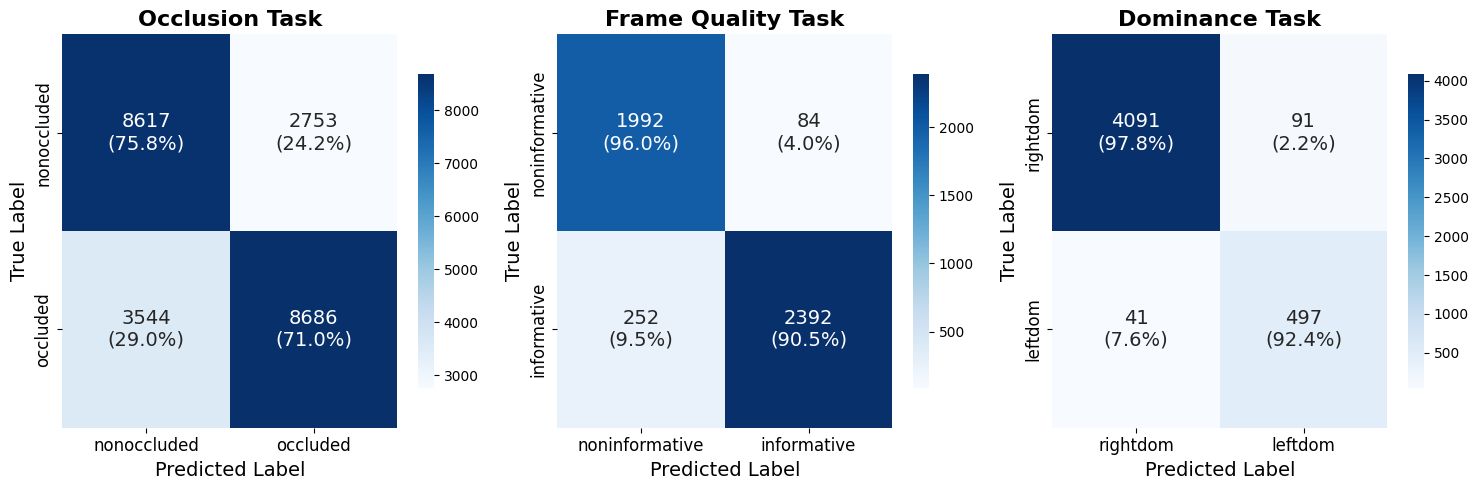


Calculating advanced metrics...

=== ADVANCED METRICS SUMMARY ===
         Task     Class_Name  Accuracy (%)  Precision (%)  Sensitivity/Recall (%)  F1-Score (%)  Specificity (%)  Support
    Occlusion    nonoccluded         75.79          70.86                   75.79         73.24            71.02    11370
    Occlusion       occluded         71.02          75.93                   71.02         73.40            75.79    12230
    Occlusion        AVERAGE         73.40          73.40                   73.40         73.32            73.40    23600
Frame Quality noninformative         95.95          88.77                   95.95         92.22            90.47     2076
Frame Quality    informative         90.47          96.61                   90.47         93.44            95.95     2644
Frame Quality        AVERAGE         93.21          92.69                   93.21         92.83            93.21     4720
    Dominance       rightdom         97.82          99.01                   97.

In [27]:
# Run comprehensive evaluation
results_dict, metrics_df = comprehensive_model_evaluation(
    model=model,
    test_loader=test_loader,
    device=device,
    class_names_dict=class_names_dict,
    results_dir=results_dir,
    model_name="densenet121_lstm"
)

# MODIFIED INFERENCE

In [18]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from torch.utils.data import Dataset, DataLoader
import os
import gc
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
import warnings
import re  # This was missing!
warnings.filterwarnings('ignore')

In [19]:
class OptimizedDatasetWithVideoID(Dataset):
    """Fixed dataset that properly tracks video IDs and handles different task sample counts"""

    def __init__(self, root_dir, split_type, view_type, clip_length, transform=None, fold_num=1):
        self.root_dir = root_dir
        self.split_type = split_type
        self.fold_num = fold_num
        self.transform = transform
        self.view_type = view_type
        self.clip_length = clip_length

        # Label mappings
        self.occlusion_label_map = {'nonoccluded': 0, 'occluded': 1}
        self.frame_quality_label_map = {'noninformative': 0, 'informative': 1}
        self.dominance_label_map = {'rightdom': 0, 'leftdom': 1}

        # Filename pattern
        self.filename_pattern = re.compile(r'(.+)_frame_(\d+)\.png')

        # Data structures
        self.occlusion_video_data_map = {}
        self.frame_quality_frame_data_list = []
        self.dominance_frame_data_list = []
        self.occlusion_clips_to_load = []

        # Pre-computed indices for faster random sampling
        self._fq_indices = None
        self._dom_indices = None

        self._load_and_index_data()
        self._prepare_random_indices()
        
        print(f"Dataset initialized:")
        print(f"  Occlusion videos: {len(self.occlusion_video_data_map)}")
        print(f"  Occlusion clips: {len(self.occlusion_clips_to_load)}")
        print(f"  Frame quality frames: {len(self.frame_quality_frame_data_list)}")
        print(f"  Dominance frames: {len(self.dominance_frame_data_list)}")

    def _prepare_random_indices(self):
        """Pre-compute random indices for faster sampling"""
        if len(self.frame_quality_frame_data_list) > 0:
            self._fq_indices = np.arange(len(self.frame_quality_frame_data_list))
            np.random.shuffle(self._fq_indices)
        
        if len(self.dominance_frame_data_list) > 0:
            self._dom_indices = np.arange(len(self.dominance_frame_data_list))
            np.random.shuffle(self._dom_indices)

    def _load_and_index_data(self):
        """Load and index data with optimizations"""
        task_configs = {
            'occlusion': {
                'csv_prefix': 'occlusion',
                'label_map': self.occlusion_label_map,
                'image_base_path': os.path.join(self.root_dir, 'occlusion', 'DATA_RCA'),
            },
            'framequality': {
                'csv_prefix': 'framequality',
                'label_map': self.frame_quality_label_map,
                'image_base_path': os.path.join(self.root_dir, 'framequality', f'DATA_{self.view_type}'),
            },
            'dominance': {
                'csv_prefix': 'dom',
                'label_map': self.dominance_label_map,
                'image_base_path': os.path.join(self.root_dir, 'dominance', f'DATA_{self.view_type}'),
            }
        }

        # Process occlusion data
        occlusion_config = task_configs['occlusion']
        csv_path = os.path.join(
            occlusion_config['image_base_path'], 'labels',
            f"{occlusion_config['csv_prefix']}_{self.split_type}_labels_fold_{self.fold_num}.csv"
        )

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            for _, row in df.iterrows():
                filename, label_str = str(row['filename']), str(row['label']).strip().lower()
                match = self.filename_pattern.match(filename)
                if not match:
                    continue

                video_id, frame_num = match.group(1), int(match.group(2))
                if video_id not in self.occlusion_video_data_map:
                    self.occlusion_video_data_map[video_id] = {}

                label_value = occlusion_config['label_map'].get(label_str)
                if label_value is None:
                    continue

                image_path = os.path.join(occlusion_config['image_base_path'], label_str, filename)
                if os.path.exists(image_path):
                    self.occlusion_video_data_map[video_id][frame_num] = {
                        'path': image_path, 'label': label_value
                    }

        # Generate clips more efficiently
        for video_id, frames_dict in self.occlusion_video_data_map.items():
            sorted_frames = sorted(frames_dict.keys())
            if len(sorted_frames) >= self.clip_length:
                for i in range(len(sorted_frames) - self.clip_length + 1):
                    self.occlusion_clips_to_load.append({
                        'video_id': video_id,
                        'clip_original_frame_indices': sorted_frames[i:i + self.clip_length]
                    })

        # Process frame quality and dominance data
        for task_name in ['framequality', 'dominance']:
            config = task_configs[task_name]
            csv_path = os.path.join(
                config['image_base_path'], 'labels',
                f"{config['csv_prefix']}_{self.split_type}_labels_fold_{self.fold_num}.csv"
            )

            target_list = (self.frame_quality_frame_data_list if task_name == 'framequality'
                          else self.dominance_frame_data_list)

            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                for _, row in df.iterrows():
                    filename, label_str = str(row['filename']), str(row['label']).strip().lower()
                    label_value = config['label_map'].get(label_str)
                    if label_value is None:
                        continue

                    image_path = os.path.join(config['image_base_path'], label_str, filename)
                    if os.path.exists(image_path):
                        target_list.append({'path': image_path, 'label': label_value})

    def __len__(self):
        return len(self.occlusion_clips_to_load)

    def __getitem__(self, idx):
        # Get occlusion clip
        clip_info = self.occlusion_clips_to_load[idx]
        video_id = clip_info['video_id']
        frame_indices = clip_info['clip_original_frame_indices']

        occlusion_frames = []
        occlusion_labels = []

        for frame_idx in frame_indices:
            frame_data = self.occlusion_video_data_map[video_id][frame_idx]
            image = Image.open(frame_data['path'])
            occlusion_frames.append(image)
            occlusion_labels.append(frame_data['label'])

        if self.transform:
            occlusion_frames_tensor = self.transform(occlusion_frames)
        else:
            occlusion_frames_tensor = torch.stack([transforms.ToTensor()(f) for f in occlusion_frames])

        # Handle case where we have fewer frame quality or dominance samples
        fq_image_tensor = torch.zeros((1, 1, 512, 512))  # Default tensor
        dom_image_tensor = torch.zeros((1, 1, 512, 512))  # Default tensor
        fq_label = -1  # Invalid label
        dom_label = -1  # Invalid label

        # Get frame quality sample if available
        if len(self.frame_quality_frame_data_list) > 0:
            fq_idx = self._fq_indices[idx % len(self._fq_indices)]
            fq_entry = self.frame_quality_frame_data_list[fq_idx]
            fq_image = Image.open(fq_entry['path'])
            
            if self.transform:
                fq_image_tensor = self.transform.transform(fq_image).unsqueeze(0)
            else:
                fq_image_tensor = transforms.ToTensor()(fq_image).unsqueeze(0)
            fq_label = fq_entry['label']

        # Get dominance sample if available
        if len(self.dominance_frame_data_list) > 0:
            dom_idx = self._dom_indices[idx % len(self._dom_indices)]
            dom_entry = self.dominance_frame_data_list[dom_idx]
            dom_image = Image.open(dom_entry['path'])
            
            if self.transform:
                dom_image_tensor = self.transform.transform(dom_image).unsqueeze(0)
            else:
                dom_image_tensor = transforms.ToTensor()(dom_image).unsqueeze(0)
            dom_label = dom_entry['label']

        return {
            "occlusion_images": occlusion_frames_tensor,
            "frame_quality_images": fq_image_tensor,
            "dominance_images": dom_image_tensor,
            "video_id": video_id,
        }, {
            "occlusion_labels": torch.tensor(occlusion_labels, dtype=torch.long),
            "frame_quality_labels": torch.tensor([fq_label], dtype=torch.long),
            "dominance_labels": torch.tensor([dom_label], dtype=torch.long),
        }


class OptimizedClipTransform:
    """Optimized transform with reduced operations"""
    def __init__(self, img_size, mean, std, apply_augmentations=True):
        # Base transforms
        base_transforms = [
            transforms.Resize(img_size, antialias=True),
            transforms.ToTensor(),
        ]

        # Only add augmentations if requested and for training
        if apply_augmentations:
            augment_transforms = [
                transforms.RandomHorizontalFlip(p=0.3),
                transforms.RandomRotation(5),
            ]
            base_transforms = base_transforms[:-1] + augment_transforms + base_transforms[-1:]

        base_transforms.append(transforms.Normalize(mean=mean, std=std))
        self.transform = transforms.Compose(base_transforms)

    def __call__(self, images):
        transformed_images = [self.transform(img) for img in images]
        return torch.stack(transformed_images)

In [20]:
# Additional optimization functions
def create_optimized_model(backbone_type='densenet121', input_channels=1, hidden_dim=128):
    """Create an optimized model with better defaults"""
    if backbone_type == 'densenet121':
        backbone_model = models.densenet121(weights='DEFAULT', memory_efficient=True)
    elif backbone_type == 'resnet50':
        backbone_model = models.resnet50(weights='DEFAULT')
    elif backbone_type == 'efficientnet_b0':
        backbone_model = models.efficientnet_b0(weights='DEFAULT')
    elif backbone_type == 'mobilenet_v2':
        backbone_model = models.mobilenet_v2(weights='DEFAULT')
    else:
        raise ValueError(f"Unsupported backbone: {backbone_type}")

    model = XCAMultiTaskModel(
        backbone=backbone_model,
        backbone_type=backbone_type,
        input_channels=input_channels,
        num_classes_occlusion=2,
        num_classes_frame_quality=2,
        num_classes_dominance=2,
        hidden_dim=hidden_dim,
        sequential_model_type='lstm',
        sequential_hidden_dim=hidden_dim,
        num_sequential_layers=5,  # Reduced from 5
        bidirectional=False
    )
    return model



In [24]:
def load_checkpoint_for_inference(checkpoint_path, model, device):
    """Utility function to load a checkpoint for inference"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])

    print(f"Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")
    print(f"Best validation accuracy: {checkpoint.get('best_val_accuracy', 'N/A')}")
    print(f"Current validation accuracy: {checkpoint.get('current_val_accuracy', 'N/A')}")
    print(f"Fold: {checkpoint.get('fold_idx', 'N/A')}")
    print(f"View type: {checkpoint.get('view_type', 'N/A')}")

    return model, checkpoint.get('history', [])

In [25]:
def plot_confusion_matrices(results_dict, class_names_dict, save_dir, figsize=(15, 5)):
    """Plot confusion matrices for all tasks"""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    tasks = ['occlusion', 'frame_quality', 'dominance']
    
    for i, task in enumerate(tasks):
        if results_dict[task]['all_targets']:
            cm = confusion_matrix(
                results_dict[task]['all_targets'],
                results_dict[task]['all_predictions']
            )
            
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_dict[task],
                yticklabels=class_names_dict[task],
                ax=axes[i]
            )
            axes[i].set_title(f'{task.replace("_", " ").title()} Confusion Matrix')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('Actual')
        else:
            axes[i].text(0.5, 0.5, f'No data for {task}', 
                        transform=axes[i].transAxes, ha='center', va='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
    plt.close()


def calculate_advanced_metrics(results_dict, class_names_dict, save_path):
    """Calculate advanced metrics and save to Excel"""
    all_metrics = []
    
    for task in ['occlusion', 'frame_quality', 'dominance']:
        if results_dict[task]['all_targets']:
            # Calculate metrics
            precision, recall, f1, support = precision_recall_fscore_support(
                results_dict[task]['all_targets'],
                results_dict[task]['all_predictions'],
                average=None,
                zero_division=0
            )
            
            # Per-class metrics
            for i, class_name in enumerate(class_names_dict[task]):
                all_metrics.append({
                    'task': task,
                    'class': class_name,
                    'precision': precision[i] if i < len(precision) else 0,
                    'recall': recall[i] if i < len(recall) else 0,
                    'f1_score': f1[i] if i < len(f1) else 0,
                    'support': support[i] if i < len(support) else 0
                })
            
            # Overall metrics
            accuracy = accuracy_score(results_dict[task]['all_targets'], results_dict[task]['all_predictions'])
            macro_f1 = f1_score(results_dict[task]['all_targets'], results_dict[task]['all_predictions'], average='macro')
            weighted_f1 = f1_score(results_dict[task]['all_targets'], results_dict[task]['all_predictions'], average='weighted')
            
            all_metrics.append({
                'task': task,
                'class': 'OVERALL',
                'precision': accuracy,
                'recall': macro_f1,
                'f1_score': weighted_f1,
                'support': len(results_dict[task]['all_targets'])
            })
    
    metrics_df = pd.DataFrame(all_metrics)
    try:
        metrics_df.to_excel(save_path, index=False)
    except:
        # If Excel writing fails, save as CSV
        csv_path = save_path.replace('.xlsx', '.csv')
        metrics_df.to_csv(csv_path, index=False)
        print(f"Could not save Excel file, saved as CSV instead: {csv_path}")
    
    return metrics_df

In [26]:
def evaluate_multi_task_model_video_level(model, test_loader, device, criterion_occlusion,
                                        criterion_frame_quality, criterion_dominance,
                                        class_names_dict, ignore_label_value=-1,
                                        save_results_dir=None, aggregation_strategy='majority'):
    """
    Fixed evaluation function with proper video-level occlusion aggregation
    """
    model.eval()

    # Initialize metrics storage
    task_names = ['occlusion', 'frame_quality', 'dominance']
    results_dict = {
        'total_samples': 0,
        'inference_times': [],
        'gpu_memory_usage': [],
        'batch_sizes': []
    }

    # Initialize per-task storage
    for task in task_names:
        results_dict[task] = {
            'test_loss': 0.0,
            'all_targets': [],
            'all_predictions': [],
            'all_probabilities': []
        }

    # Video-level storage for occlusion
    occlusion_video_data = {}
    processed_videos = set()  # Track processed videos to avoid duplicates

    total_samples = 0
    total_batches = 0

    print("Starting model evaluation with video-level occlusion aggregation...")
    print(f"Device: {device}")
    print(f"Aggregation strategy: {aggregation_strategy}")
    print(f"Total batches to process: {len(test_loader)}")

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(tqdm(test_loader, desc="Evaluating")):
            batch_start_time = time.time()

            # Move data to device
            images_dict = {k: v.to(device, non_blocking=True) for k, v in inputs.items() if k != 'video_id'}
            labels_dict = {k: v.to(device, non_blocking=True) for k, v in labels.items()}

            # Get video IDs
            video_ids = inputs.get('video_id', [f"batch_{batch_idx}_video_{i}" for i in range(len(next(iter(images_dict.values()))))])

            # Record GPU memory usage
            if device.type == 'cuda':
                gpu_memory_used = torch.cuda.memory_allocated() / 1024**2  # MB
                results_dict['gpu_memory_usage'].append(gpu_memory_used)

            # Forward pass
            try:
                with torch.amp.autocast("cuda" if device.type == 'cuda' else "cpu", enabled=False):
                    outputs = model(images_dict)
            except:
                # Fallback without autocast for older PyTorch versions
                outputs = model(images_dict)

            batch_size = next(iter(images_dict.values())).size(0)
            results_dict['batch_sizes'].append(batch_size)
            total_samples += batch_size

            # Process occlusion task (collect all clips for later video-level aggregation)
            occlusion_logits = outputs['occlusion']  # (B, T, num_classes)
            occlusion_labels = labels_dict['occlusion_labels']  # (B, T)

            for batch_idx_inner in range(batch_size):
                video_id = video_ids[batch_idx_inner]
                
                clip_logits = occlusion_logits[batch_idx_inner]  # (T, num_classes)
                clip_labels = occlusion_labels[batch_idx_inner]   # (T,)

                # Filter valid frames
                valid_mask = clip_labels != ignore_label_value
                if valid_mask.any():
                    valid_logits = clip_logits[valid_mask]
                    valid_labels = clip_labels[valid_mask]

                    # Get predictions and probabilities
                    frame_probs = torch.softmax(valid_logits, dim=1)
                    _, frame_preds = torch.max(valid_logits, 1)

                    # Store per-video (accumulate across clips)
                    if video_id not in occlusion_video_data:
                        occlusion_video_data[video_id] = {'preds': [], 'labels': [], 'probs': []}

                    occlusion_video_data[video_id]['preds'].extend(frame_preds.cpu().numpy())
                    occlusion_video_data[video_id]['labels'].extend(valid_labels.cpu().numpy())
                    occlusion_video_data[video_id]['probs'].extend(frame_probs.cpu().numpy())

            # Process Frame Quality task (only count valid samples)
            fq_logits = outputs['frame_quality'].squeeze(1)
            fq_labels = labels_dict['frame_quality_labels'].squeeze(1)

            valid_fq_mask = fq_labels != ignore_label_value
            if valid_fq_mask.any():
                valid_fq_logits = fq_logits[valid_fq_mask]
                valid_fq_labels = fq_labels[valid_fq_mask]

                loss_fq = criterion_frame_quality(valid_fq_logits, valid_fq_labels)
                results_dict['frame_quality']['test_loss'] += loss_fq.item()

                fq_probs = torch.softmax(valid_fq_logits, dim=1)
                _, fq_preds = torch.max(valid_fq_logits, 1)

                results_dict['frame_quality']['all_targets'].extend(valid_fq_labels.cpu().numpy())
                results_dict['frame_quality']['all_predictions'].extend(fq_preds.cpu().numpy())
                results_dict['frame_quality']['all_probabilities'].extend(fq_probs.cpu().numpy())

            # Process Dominance task (only count valid samples)
            dom_logits = outputs['dominance'].squeeze(1)
            dom_labels = labels_dict['dominance_labels'].squeeze(1)

            valid_dom_mask = dom_labels != ignore_label_value
            if valid_dom_mask.any():
                valid_dom_logits = dom_logits[valid_dom_mask]
                valid_dom_labels = dom_labels[valid_dom_mask]

                loss_dom = criterion_dominance(valid_dom_logits, valid_dom_labels)
                results_dict['dominance']['test_loss'] += loss_dom.item()

                dom_probs = torch.softmax(valid_dom_logits, dim=1)
                _, dom_preds = torch.max(valid_dom_logits, 1)

                results_dict['dominance']['all_targets'].extend(valid_dom_labels.cpu().numpy())
                results_dict['dominance']['all_predictions'].extend(dom_preds.cpu().numpy())
                results_dict['dominance']['all_probabilities'].extend(dom_probs.cpu().numpy())

            # Record inference time
            batch_time = time.time() - batch_start_time
            results_dict['inference_times'].append(batch_time)

            total_batches += 1

            # Clear memory
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    # Aggregate occlusion results at video level
    print(f"\nAggregating occlusion results from {len(occlusion_video_data)} videos...")

    for video_id, video_data in occlusion_video_data.items():
        frame_preds = np.array(video_data['preds'])
        frame_labels = np.array(video_data['labels'])
        frame_probs = np.array(video_data['probs'])

        # Get video-level ground truth (should be consistent)
        video_label = np.bincount(frame_labels).argmax()

        # Apply aggregation strategy
        if aggregation_strategy == 'majority':
            video_pred = np.bincount(frame_preds).argmax()
            video_prob = np.mean(frame_probs, axis=0)
        elif aggregation_strategy == 'average':
            video_prob = np.mean(frame_probs, axis=0)
            video_pred = np.argmax(video_prob)
        elif aggregation_strategy == 'strict_consensus':
            if np.all(frame_preds == frame_preds[0]):
                video_pred = frame_preds[0]
            else:
                video_pred = 1  # Default to occluded if no consensus
            video_prob = np.mean(frame_probs, axis=0)
        else:
            raise ValueError(f"Unknown aggregation strategy: {aggregation_strategy}")

        # Store video-level results
        results_dict['occlusion']['all_predictions'].append(video_pred)
        results_dict['occlusion']['all_targets'].append(video_label)
        results_dict['occlusion']['all_probabilities'].append(video_prob)

    # Convert occlusion probabilities to numpy array
    if results_dict['occlusion']['all_probabilities']:
        results_dict['occlusion']['all_probabilities'] = np.array(results_dict['occlusion']['all_probabilities'])

    # Calculate final metrics
    results_dict['total_samples'] = total_samples
    avg_batch_time = np.mean(results_dict['inference_times'])
    avg_gpu_memory = np.mean(results_dict['gpu_memory_usage']) if results_dict['gpu_memory_usage'] else 0

    print(f"\n=== INFERENCE PERFORMANCE ===")
    print(f"Total clips processed: {total_samples}")
    print(f"Total batches: {total_batches}")
    print(f"Average batch size: {np.mean(results_dict['batch_sizes']):.1f}")
    print(f"Average inference time per batch: {avg_batch_time:.4f} seconds")
    print(f"Inference time per sample: {avg_batch_time/np.mean(results_dict['batch_sizes']):.4f} seconds")
    if device.type == 'cuda':
        print(f"Average GPU memory usage: {avg_gpu_memory:.2f} MB")

    # Calculate per-task metrics and show correct counts
    for task in task_names:
        if results_dict[task]['all_targets']:
            if task == 'occlusion':
                avg_loss = 0.0
                print(f"\n=== {task.upper()} TASK METRICS (VIDEO-LEVEL) ===")
                print(f"Aggregation strategy: {aggregation_strategy}")
                print(f"Total videos: {len(occlusion_video_data)}")
                
                # Count by class
                targets = np.array(results_dict[task]['all_targets'])
                class_counts = np.bincount(targets)
                for i, class_name in enumerate(class_names_dict[task]):
                    if i < len(class_counts):
                        print(f"{class_name}: {class_counts[i]} videos")
                        
            else:
                avg_loss = results_dict[task]['test_loss'] / total_batches if total_batches > 0 else 0
                print(f"\n=== {task.upper().replace('_', ' ')} TASK METRICS ===")
                print(f"Test Loss: {avg_loss:.4f}")
                
                # Count by class
                targets = np.array(results_dict[task]['all_targets'])
                if len(targets) > 0:
                    class_counts = np.bincount(targets)
                    for i, class_name in enumerate(class_names_dict[task]):
                        if i < len(class_counts):
                            print(f"{class_name}: {class_counts[i]} frames")

            accuracy = accuracy_score(results_dict[task]['all_targets'],
                                    results_dict[task]['all_predictions'])
            results_dict[task]['test_acc'] = accuracy
            results_dict[task]['avg_test_loss'] = avg_loss

            print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
            print(f"Total samples: {len(results_dict[task]['all_targets'])}")

            # Classification report
            if task in class_names_dict and len(results_dict[task]['all_targets']) > 0:
                print("\nClassification Report:")
                print(classification_report(results_dict[task]['all_targets'],
                                          results_dict[task]['all_predictions'],
                                          target_names=class_names_dict[task],
                                          digits=4))

    # Save results if directory provided
    if save_results_dir:
        os.makedirs(save_results_dir, exist_ok=True)

        # Save raw predictions and probabilities
        for task in task_names:
            if results_dict[task]['all_targets']:
                task_df = pd.DataFrame({
                    'true_labels': results_dict[task]['all_targets'],
                    'predictions': results_dict[task]['all_predictions']
                })

                # Add probability columns
                if len(results_dict[task]['all_probabilities']) > 0:
                    prob_array = results_dict[task]['all_probabilities']
                    prob_array = np.array(prob_array)
                    if prob_array.ndim > 1:
                        for i in range(prob_array.shape[1]):
                            class_name = class_names_dict[task][i] if task in class_names_dict else f'class_{i}'
                            task_df[f'prob_{class_name}'] = prob_array[:, i]

                # Add aggregation info for occlusion
                if task == 'occlusion':
                    task_df['aggregation_strategy'] = aggregation_strategy

                task_df.to_csv(os.path.join(save_results_dir, f'{task}_predictions.csv'), index=False)

        # Save video-level occlusion details
        if occlusion_video_data:
            video_details = []
            for video_id, video_data in occlusion_video_data.items():
                video_details.append({
                    'video_id': video_id,
                    'num_frames': len(video_data['preds']),
                    'frame_predictions': str(video_data['preds']),
                    'frame_labels': str(video_data['labels'])
                })

            video_df = pd.DataFrame(video_details)
            video_df.to_csv(os.path.join(save_results_dir, 'occlusion_video_details.csv'), index=False)

    return results_dict


def comprehensive_model_evaluation_fixed(model, test_loader, device, class_names_dict,
                                        results_dir, model_name="model",
                                        aggregation_strategy='majority'):
    """Complete evaluation pipeline with fixed video-level occlusion handling"""

    # Create results directory
    os.makedirs(results_dir, exist_ok=True)

    # Define loss functions
    criterion_occlusion = nn.CrossEntropyLoss(ignore_index=-1)
    criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=-1)
    criterion_dominance = nn.CrossEntropyLoss(ignore_index=-1)

    print(f"Starting comprehensive evaluation for {model_name}")
    print(f"Occlusion aggregation strategy: {aggregation_strategy}")
    print(f"Results will be saved to: {results_dir}")

    # 1. Main evaluation with fixed occlusion handling
    results_dict = evaluate_multi_task_model_video_level(
        model=model,
        test_loader=test_loader,
        device=device,
        criterion_occlusion=criterion_occlusion,
        criterion_frame_quality=criterion_frame_quality,
        criterion_dominance=criterion_dominance,
        class_names_dict=class_names_dict,
        save_results_dir=results_dir,
        aggregation_strategy=aggregation_strategy
    )

    # 2. Plot confusion matrices
    print("\nGenerating confusion matrices...")
    plot_confusion_matrices(
        results_dict=results_dict,
        class_names_dict=class_names_dict,
        save_dir=results_dir,
        figsize=(15, 5)
    )

    # 3. Calculate advanced metrics
    print("\nCalculating advanced metrics...")
    metrics_df = calculate_advanced_metrics(
        results_dict=results_dict,
        class_names_dict=class_names_dict,
        save_path=os.path.join(results_dir, f'{model_name}_advanced_metrics.xlsx')
    )

    # 4. Save summary results
    summary_results = {
        'model_name': model_name,
        'aggregation_strategy': aggregation_strategy,
        'total_samples': results_dict['total_samples'],
        'avg_inference_time_per_batch': np.mean(results_dict['inference_times']),
        'avg_gpu_memory_usage': np.mean(results_dict['gpu_memory_usage']) if results_dict['gpu_memory_usage'] else 0
    }

    # Add per-task summary
    for task in ['occlusion', 'frame_quality', 'dominance']:
        if results_dict[task]['all_targets']:
            summary_results[f'{task}_accuracy'] = results_dict[task]['test_acc']
            summary_results[f'{task}_loss'] = results_dict[task]['avg_test_loss']
            summary_results[f'{task}_samples'] = len(results_dict[task]['all_targets'])

    # Save summary
    summary_df = pd.DataFrame([summary_results])
    summary_df.to_csv(os.path.join(results_dir, f'{model_name}_summary.csv'), index=False)

    print(f"\nEvaluation complete! All results saved to: {results_dir}")
    print(f"\nKey findings:")
    print(f"- Occlusion: {len(results_dict['occlusion']['all_targets'])} videos evaluated")
    print(f"- Frame Quality: {len(results_dict['frame_quality']['all_targets'])} samples")
    print(f"- Dominance: {len(results_dict['dominance']['all_targets'])} samples")

    return results_dict, metrics_df


In [27]:
#----------------------------------------------------------------------------------------------------#
#--------------------------------------- FIXED RUN INFERENCE ---------------------------------------#
#----------------------------------------------------------------------------------------------------#

# Configuration parameters
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
IMG_SIZE = (512, 512)
FOLD_NUM = 1
VIEW_TYPE = 'RCA'
CLIP_LENGTH = 5
BATCH_SIZE = 4
NUM_WORKERS = 0
MEAN, STD = 0.5485, 0.1407
INPUT_CHANNELS = 1
HIDDEN_DIM = 128
BACKBONE = 'mobilenet_v2'
print("="*60)
print("MULTI-TASK LEARNING INFERENCE PIPELINE")
print("="*60)
# Use the modified dataset that tracks video IDs
test_transform = OptimizedClipTransform(
    img_size=IMG_SIZE,
    mean=[MEAN],
    std=[STD],
    apply_augmentations=False
)

# Replace with the fixed dataset
test_dataset = OptimizedDatasetWithVideoID(
    root_dir=ROOT_DATA_DIR,
    fold_num=FOLD_NUM,
    split_type='test',  # or 'test'
    view_type=VIEW_TYPE,
    clip_length=CLIP_LENGTH,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

print("Data loading complete..............")
print(f"Total clips to process: {len(test_dataset)}")
print(f"Total unique videos: {len(test_dataset.occlusion_video_data_map)}")

# Define class names
class_names_dict = {
    'occlusion': ['nonoccluded', 'occluded'],
    'frame_quality': ['noninformative', 'informative'],
    'dominance': ['rightdom', 'leftdom']
}

# Load model
model_path = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\training_results\MobileNetV2_mtl_best.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_optimized_model(BACKBONE, input_channels=INPUT_CHANNELS, hidden_dim=HIDDEN_DIM)
model.to(device)
model, _ = load_checkpoint_for_inference(model_path, model, device)

results_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\testing_results'
# Run comprehensive evaluation with different aggregation strategies
aggregation_strategies = ['majority', 'average']

for strategy in aggregation_strategies:
    print(f"\n{'='*60}")
    print(f"Running evaluation with {strategy} aggregation")
    print(f"{'='*60}")
    
    strategy_results_dir = os.path.join(results_dir, f'aggregation_{strategy}')
    
    # Run comprehensive evaluation
    results_dict, metrics_df = comprehensive_model_evaluation_fixed(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names_dict=class_names_dict,
        results_dir=strategy_results_dir,
        model_name=f"densenet121_lstm_{strategy}",
        aggregation_strategy=strategy
    )
    
    print(f"\nResults for {strategy} aggregation saved to: {strategy_results_dir}")

# Compare results across strategies
print(f"\n{'='*60}")
print("COMPARISON ACROSS AGGREGATION STRATEGIES")
print(f"{'='*60}")

comparison_results = []
for strategy in aggregation_strategies:
    strategy_results_dir = os.path.join(results_dir, f'aggregation_{strategy}')
    summary_file = os.path.join(strategy_results_dir, f'densenet121_lstm_{strategy}_summary.csv')
    
    if os.path.exists(summary_file):
        summary_df = pd.read_csv(summary_file)
        summary_df['strategy'] = strategy
        comparison_results.append(summary_df)

if comparison_results:
    comparison_df = pd.concat(comparison_results, ignore_index=True)
    comparison_df.to_csv(os.path.join(results_dir, 'aggregation_strategy_comparison.csv'), index=False)
    
    print("\nAccuracy Comparison:")
    for strategy in aggregation_strategies:
        strategy_data = comparison_df[comparison_df['strategy'] == strategy]
        if not strategy_data.empty:
            occ_acc = strategy_data['occlusion_accuracy'].iloc[0] * 100
            fq_acc = strategy_data['frame_quality_accuracy'].iloc[0] * 100
            dom_acc = strategy_data['dominance_accuracy'].iloc[0] * 100
            occ_samples = strategy_data['occlusion_samples'].iloc[0]
            
            print(f"{strategy.capitalize():12} - Occlusion: {occ_acc:.2f}% ({occ_samples} videos), "
                  f"Frame Quality: {fq_acc:.2f}%, Dominance: {dom_acc:.2f}%")

print(f"\nAll results saved to: {results_dir}")

MULTI-TASK LEARNING INFERENCE PIPELINE
Dataset initialized:
  Occlusion videos: 107
  Occlusion clips: 4720
  Frame quality frames: 789
  Dominance frames: 4149
Data loading complete..............
Total clips to process: 4720
Total unique videos: 107
Loaded checkpoint from epoch 4
Best validation accuracy: 0.9020578420467187
Current validation accuracy: 0.9020578420467187
Fold: 1
View type: RCA

Running evaluation with majority aggregation
Starting comprehensive evaluation for densenet121_lstm_majority
Occlusion aggregation strategy: majority
Results will be saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\MobileNetV2_LSTM\testing_results\aggregation_majority
Starting model evaluation with video-level occlusion aggregation...
Device: cuda
Aggregation strategy: majority
Total batches to process: 1180


Evaluating: 100%|█████████████████████████████████████| 1180/1180 [06:29<00:00,  3.03it/s]



Aggregating occlusion results from 107 videos...

=== INFERENCE PERFORMANCE ===
Total clips processed: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.0892 seconds
Inference time per sample: 0.0223 seconds
Average GPU memory usage: 112.08 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: majority
Total videos: 107
nonoccluded: 59 videos
occluded: 48 videos
Test Accuracy: 0.8505 (85.05%)
Total samples: 107

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.9057    0.8136    0.8571        59
    occluded     0.7963    0.8958    0.8431        48

    accuracy                         0.8505       107
   macro avg     0.8510    0.8547    0.8501       107
weighted avg     0.8566    0.8505    0.8509       107


=== FRAME QUALITY TASK METRICS ===
Test Loss: 0.3366
noninformative: 2075 frames
informative: 2645 frames
Test Accuracy: 0.8608 (86.08%)
Total samples: 4720

Classification Report:

Evaluating: 100%|█████████████████████████████████████| 1180/1180 [05:20<00:00,  3.68it/s]



Aggregating occlusion results from 107 videos...

=== INFERENCE PERFORMANCE ===
Total clips processed: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.0883 seconds
Inference time per sample: 0.0221 seconds
Average GPU memory usage: 112.08 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: average
Total videos: 107
nonoccluded: 59 videos
occluded: 48 videos
Test Accuracy: 0.8411 (84.11%)
Total samples: 107

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.8889    0.8136    0.8496        59
    occluded     0.7925    0.8750    0.8317        48

    accuracy                         0.8411       107
   macro avg     0.8407    0.8443    0.8406       107
weighted avg     0.8456    0.8411    0.8415       107


=== FRAME QUALITY TASK METRICS ===
Test Loss: 0.3366
noninformative: 2075 frames
informative: 2645 frames
Test Accuracy: 0.8608 (86.08%)
Total samples: 4720

Classification Report:


In [46]:
# Configuration parameters
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
IMG_SIZE = (512, 512)
FOLD_NUM = 1
VIEW_TYPE = 'RCA'
CLIP_LENGTH = 5
BATCH_SIZE = 4
NUM_WORKERS = 0
MEAN, STD = 0.5485, 0.1407
INPUT_CHANNELS = 1
HIDDEN_DIM = 128

print("="*60)
print("MULTI-TASK LEARNING INFERENCE PIPELINE")
print("="*60)

# Initialize transforms
print("Initializing transforms...")
test_transform = OptimizedClipTransform(
    img_size=IMG_SIZE,
    mean=[MEAN],
    std=[STD],
    apply_augmentations=False
)

# Create dataset
print("Loading dataset...")
test_dataset = OptimizedDatasetWithVideoID(
    root_dir=ROOT_DATA_DIR,
    fold_num=FOLD_NUM,
    split_type='test',  # Change to 'val' or 'test' as needed
    view_type=VIEW_TYPE,
    clip_length=CLIP_LENGTH,
    transform=test_transform
)

# Create data loader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0 if NUM_WORKERS > 0 else False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

print("="*60)
print("DATASET STATISTICS")
print("="*60)
print(f"Total clips to process: {len(test_dataset)}")
print(f"Total unique videos: {len(test_dataset.occlusion_video_data_map)}")
print(f"Frame quality samples: {len(test_dataset.frame_quality_frame_data_list)}")
print(f"Dominance samples: {len(test_dataset.dominance_frame_data_list)}")

# Define class names
class_names_dict = {
    'occlusion': ['nonoccluded', 'occluded'],
    'frame_quality': ['noninformative', 'informative'],
    'dominance': ['rightdom', 'leftdom']
}

# Load model
print("\nLoading model...")
model_path = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\training_results\Densenet121_mtl_best.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Replace this with your actual model loading
model = create_optimized_model('densenet121', input_channels=INPUT_CHANNELS, hidden_dim=HIDDEN_DIM)
model.to(device)
model, _ = load_checkpoint_for_inference(model_path, model, device)

print("Model loaded successfully!")

# Set up results directory
results_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_fixed_new'

# Run comprehensive evaluation with different aggregation strategies
aggregation_strategies = ['majority', 'average']

all_results = {}

for strategy in aggregation_strategies:
    print(f"\n{'='*60}")
    print(f"RUNNING EVALUATION WITH {strategy.upper()} AGGREGATION")
    print(f"{'='*60}")

    strategy_results_dir = os.path.join(results_dir, f'aggregation_{strategy}')

    # Run comprehensive evaluation
    results_dict, metrics_df = comprehensive_model_evaluation_fixed(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names_dict=class_names_dict,
        results_dir=strategy_results_dir,
        model_name=f"densenet121_lstm_{strategy}",
        aggregation_strategy=strategy
    )
    
    all_results[strategy] = results_dict

    print(f"\nResults for {strategy} aggregation saved to: {strategy_results_dir}")

# Compare results across strategies
print(f"\n{'='*60}")
print("COMPARISON ACROSS AGGREGATION STRATEGIES")
print(f"{'='*60}")

comparison_results = []
for strategy in aggregation_strategies:
    strategy_results_dir = os.path.join(results_dir, f'aggregation_{strategy}')
    summary_file = os.path.join(strategy_results_dir, f'densenet121_lstm_{strategy}_summary.csv')

    if os.path.exists(summary_file):
        summary_df = pd.read_csv(summary_file)
        summary_df['strategy'] = strategy
        comparison_results.append(summary_df)

if comparison_results:
    comparison_df = pd.concat(comparison_results, ignore_index=True)
    comparison_df.to_csv(os.path.join(results_dir, 'aggregation_strategy_comparison.csv'), index=False)

    print("\nAccuracy Comparison:")
    print("-" * 80)
    print(f"{'Strategy':<12} {'Occlusion':<20} {'Frame Quality':<20} {'Dominance':<20}")
    print("-" * 80)
    
    for strategy in aggregation_strategies:
        strategy_data = comparison_df[comparison_df['strategy'] == strategy]
        if not strategy_data.empty:
            occ_acc = strategy_data['occlusion_accuracy'].iloc[0] * 100
            fq_acc = strategy_data['frame_quality_accuracy'].iloc[0] * 100
            dom_acc = strategy_data['dominance_accuracy'].iloc[0] * 100
            occ_samples = int(strategy_data['occlusion_samples'].iloc[0])
            fq_samples = int(strategy_data['frame_quality_samples'].iloc[0])
            dom_samples = int(strategy_data['dominance_samples'].iloc[0])

            print(f"{strategy.capitalize():<12} {occ_acc:.2f}% ({occ_samples} videos) {fq_acc:.2f}% ({fq_samples} frames) {dom_acc:.2f}% ({dom_samples} frames)")

# Display final summary
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")

# Show the corrected counts
sample_strategy = aggregation_strategies[0]  # Use first strategy for sample counts
results = all_results[sample_strategy]

print("Corrected Sample Counts:")
print("-" * 40)
print("=== OCCLUSION TASK METRICS ===")
if results['occlusion']['all_targets']:
    targets = np.array(results['occlusion']['all_targets'])
    class_counts = np.bincount(targets)
    for i, class_name in enumerate(class_names_dict['occlusion']):
        if i < len(class_counts):
            print(f"{class_name:<15} {class_counts[i]:>4} (videos)")
    print(f"{'total':<15} {len(targets):>4} (videos)")

print("\n=== FRAME QUALITY TASK METRICS ===")
if results['frame_quality']['all_targets']:
    targets = np.array(results['frame_quality']['all_targets'])
    class_counts = np.bincount(targets)
    for i, class_name in enumerate(class_names_dict['frame_quality']):
        if i < len(class_counts):
            print(f"{class_name:<15} {class_counts[i]:>4} frames")
    print(f"{'total':<15} {len(targets):>4} frames")

print("\n=== DOMINANCE TASK METRICS ===")
if results['dominance']['all_targets']:
    targets = np.array(results['dominance']['all_targets'])
    class_counts = np.bincount(targets)
    for i, class_name in enumerate(class_names_dict['dominance']):
        if i < len(class_counts):
            print(f"{class_name:<15} {class_counts[i]:>4} frames")
    print(f"{'total':<15} {len(targets):>4} frames")

print(f"\nAll results saved to: {results_dir}")
print("Inference pipeline completed successfully!")


MULTI-TASK LEARNING INFERENCE PIPELINE
Initializing transforms...
Loading dataset...
Dataset initialized:
  Occlusion videos: 107
  Occlusion clips: 4720
  Frame quality frames: 789
  Dominance frames: 4149
DATASET STATISTICS
Total clips to process: 4720
Total unique videos: 107
Frame quality samples: 789
Dominance samples: 4149

Loading model...
Using device: cuda
Loaded checkpoint from epoch 14
Best validation accuracy: 0.903299962921765
Current validation accuracy: 0.903299962921765
Fold: 1
View type: RCA
Model loaded successfully!

RUNNING EVALUATION WITH MAJORITY AGGREGATION
Starting comprehensive evaluation for densenet121_lstm_majority
Occlusion aggregation strategy: majority
Results will be saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_fixed_new\aggregation_majority
Starting model evaluation with video-level occlusion aggregation...
Device: cuda
Aggregation strategy: majority
Total batches to process: 1180


Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [06:26<00:00,  3.05it/s]



Aggregating occlusion results from 107 videos...

=== INFERENCE PERFORMANCE ===
Total clips processed: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1343 seconds
Inference time per sample: 0.0336 seconds
Average GPU memory usage: 171.26 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: majority
Total videos: 107
nonoccluded: 59 videos
occluded: 48 videos
Test Accuracy: 0.8131 (81.31%)
Total samples: 107

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.8095    0.8644    0.8361        59
    occluded     0.8182    0.7500    0.7826        48

    accuracy                         0.8131       107
   macro avg     0.8139    0.8072    0.8093       107
weighted avg     0.8134    0.8131    0.8121       107


=== FRAME QUALITY TASK METRICS ===
Test Loss: 0.2083
noninformative: 2078 frames
informative: 2642 frames
Test Accuracy: 0.9288 (92.88%)
Total samples: 4720

Classification Report:

Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [06:19<00:00,  3.11it/s]



Aggregating occlusion results from 107 videos...

=== INFERENCE PERFORMANCE ===
Total clips processed: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1352 seconds
Inference time per sample: 0.0338 seconds
Average GPU memory usage: 171.26 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: average
Total videos: 107
nonoccluded: 59 videos
occluded: 48 videos
Test Accuracy: 0.8131 (81.31%)
Total samples: 107

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.8095    0.8644    0.8361        59
    occluded     0.8182    0.7500    0.7826        48

    accuracy                         0.8131       107
   macro avg     0.8139    0.8072    0.8093       107
weighted avg     0.8134    0.8131    0.8121       107


=== FRAME QUALITY TASK METRICS ===
Test Loss: 0.2083
noninformative: 2078 frames
informative: 2642 frames
Test Accuracy: 0.9288 (92.88%)
Total samples: 4720

Classification Report:


# ANOTHER NEW TEST/INFERENCE

In [39]:
from collections import defaultdict

In [40]:
class FixedDatasetWithVideoID(Dataset):
    """Fixed dataset that properly tracks video IDs and ensures all videos are included"""
    
    def __init__(self, root_dir, split_type, view_type, clip_length, transform=None, fold_num=1):
        self.root_dir = root_dir
        self.split_type = split_type
        self.fold_num = fold_num
        self.transform = transform
        self.view_type = view_type
        self.clip_length = clip_length

        # Label mappings
        self.occlusion_label_map = {'nonoccluded': 0, 'occluded': 1}
        self.frame_quality_label_map = {'noninformative': 0, 'informative': 1}
        self.dominance_label_map = {'rightdom': 0, 'leftdom': 1}

        # Improved filename pattern to capture full video ID
        self.filename_pattern = re.compile(r'(.+)_frame_(\d+)\.png')

        # Data structures
        self.occlusion_video_data_map = {}
        self.frame_quality_frame_data_list = []
        self.dominance_frame_data_list = []
        self.occlusion_clips_to_load = []
        
        # Video statistics tracking
        self.video_stats = {
            'total_videos_found': 0,
            'videos_with_sufficient_frames': 0,
            'occluded_videos': 0,
            'non_occluded_videos': 0
        }

        # Pre-computed indices for faster random sampling
        self._fq_indices = None
        self._dom_indices = None

        self._load_and_index_data()
        self._prepare_random_indices()
        self._print_dataset_statistics()

    def _extract_video_id(self, filename):
        """Extract video ID more robustly"""
        # Remove .png extension first
        base_name = filename.replace('.png', '')
        
        # Split by '_frame_' and take everything before it
        parts = base_name.split('_frame_')
        if len(parts) >= 2:
            return parts[0]  # This includes Study + View + Series ID
        
        # Fallback: use the filename pattern
        match = self.filename_pattern.match(filename)
        if match:
            return match.group(1)
        
        return None

    def _prepare_random_indices(self):
        """Pre-compute random indices for faster sampling"""
        self._fq_indices = np.arange(len(self.frame_quality_frame_data_list))
        self._dom_indices = np.arange(len(self.dominance_frame_data_list))
        np.random.shuffle(self._fq_indices)
        np.random.shuffle(self._dom_indices)

    def _load_and_index_data(self):
        """Load and index data with improved video tracking"""
        print(f"Loading {self.split_type} data for fold {self.fold_num}...")
        
        # Process occlusion data with detailed tracking
        occlusion_config = {
            'csv_prefix': 'occlusion',
            'label_map': self.occlusion_label_map,
            'image_base_path': os.path.join(self.root_dir, 'occlusion', 'DATA_RCA'),
        }
        
        csv_path = os.path.join(
            occlusion_config['image_base_path'], 'labels',
            f"{occlusion_config['csv_prefix']}_{self.split_type}_labels_fold_{self.fold_num}.csv"
        )

        print(f"Loading occlusion CSV from: {csv_path}")
        
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            print(f"Found {len(df)} entries in occlusion CSV")
            
            # Track videos by label for statistics
            videos_by_label = defaultdict(set)
            
            for idx, row in df.iterrows():
                filename = str(row['filename']).strip()
                label_str = str(row['label']).strip().lower()
                
                # Extract video ID
                video_id = self._extract_video_id(filename)
                if not video_id:
                    print(f"Warning: Could not extract video ID from {filename}")
                    continue

                # Extract frame number
                match = self.filename_pattern.match(filename)
                if not match:
                    print(f"Warning: Could not parse frame number from {filename}")
                    continue
                
                frame_num = int(match.group(2))
                
                # Track video by label
                videos_by_label[label_str].add(video_id)
                
                # Initialize video data structure
                if video_id not in self.occlusion_video_data_map:
                    self.occlusion_video_data_map[video_id] = {}

                # Get label value
                label_value = occlusion_config['label_map'].get(label_str)
                if label_value is None:
                    print(f"Warning: Unknown label '{label_str}' for {filename}")
                    continue

                # Check if image exists
                image_path = os.path.join(occlusion_config['image_base_path'], label_str, filename)
                if os.path.exists(image_path):
                    self.occlusion_video_data_map[video_id][frame_num] = {
                        'path': image_path, 
                        'label': label_value,
                        'video_label': label_str  # Store original label for video-level tracking
                    }
                else:
                    print(f"Warning: Image not found: {image_path}")

            # Update statistics
            self.video_stats['total_videos_found'] = len(self.occlusion_video_data_map)
            self.video_stats['occluded_videos'] = len(videos_by_label['occluded'])
            self.video_stats['non_occluded_videos'] = len(videos_by_label['nonoccluded'])
            
            print(f"Loaded {len(self.occlusion_video_data_map)} unique videos")
            print(f"Occluded videos: {self.video_stats['occluded_videos']}")
            print(f"Non-occluded videos: {self.video_stats['non_occluded_videos']}")

        # Generate clips with improved logic
        videos_with_sufficient_frames = 0
        for video_id, frames_dict in self.occlusion_video_data_map.items():
            sorted_frames = sorted(frames_dict.keys())
            
            if len(sorted_frames) >= self.clip_length:
                videos_with_sufficient_frames += 1
                
                # Generate clips with stride (can be adjusted)
                stride = 1  # You can change this to reduce overlap
                for i in range(0, len(sorted_frames) - self.clip_length + 1, stride):
                    clip_frames = sorted_frames[i:i + self.clip_length]
                    
                    # Ensure all frames in clip have same label (consistency check)
                    frame_labels = [frames_dict[f]['label'] for f in clip_frames]
                    if len(set(frame_labels)) == 1:  # All frames have same label
                        self.occlusion_clips_to_load.append({
                            'video_id': video_id,
                            'clip_original_frame_indices': clip_frames,
                            'video_label': frame_labels[0]  # Store video-level label
                        })
                    else:
                        print(f"Warning: Inconsistent labels in clip for video {video_id}")
            else:
                print(f"Warning: Video {video_id} has only {len(sorted_frames)} frames, need {self.clip_length}")

        self.video_stats['videos_with_sufficient_frames'] = videos_with_sufficient_frames
        
        # Load frame quality and dominance data (unchanged but with better error handling)
        task_configs = {
            'framequality': {
                'csv_prefix': 'framequality',
                'label_map': self.frame_quality_label_map,
                'image_base_path': os.path.join(self.root_dir, 'framequality', f'DATA_{self.view_type}'),
            },
            'dominance': {
                'csv_prefix': 'dom',
                'label_map': self.dominance_label_map,
                'image_base_path': os.path.join(self.root_dir, 'dominance', f'DATA_{self.view_type}'),
            }
        }

        for task_name in ['framequality', 'dominance']:
            config = task_configs[task_name]
            csv_path = os.path.join(
                config['image_base_path'], 'labels',
                f"{config['csv_prefix']}_{self.split_type}_labels_fold_{self.fold_num}.csv"
            )

            target_list = (self.frame_quality_frame_data_list if task_name == 'framequality'
                          else self.dominance_frame_data_list)

            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                print(f"Loading {task_name}: {len(df)} entries")
                
                for _, row in df.iterrows():
                    filename = str(row['filename']).strip()
                    label_str = str(row['label']).strip().lower()
                    label_value = config['label_map'].get(label_str)
                    
                    if label_value is None:
                        print(f"Warning: Unknown {task_name} label '{label_str}' for {filename}")
                        continue

                    image_path = os.path.join(config['image_base_path'], label_str, filename)
                    if os.path.exists(image_path):
                        target_list.append({'path': image_path, 'label': label_value})
                    else:
                        print(f"Warning: {task_name} image not found: {image_path}")

    def _print_dataset_statistics(self):
        """Print comprehensive dataset statistics"""
        print(f"\n=== DATASET STATISTICS ===")
        print(f"Split: {self.split_type}, Fold: {self.fold_num}, View: {self.view_type}")
        print(f"Clip length: {self.clip_length}")
        print(f"\nOcclusion Task:")
        print(f"  Total videos found: {self.video_stats['total_videos_found']}")
        print(f"  Videos with ≥{self.clip_length} frames: {self.video_stats['videos_with_sufficient_frames']}")
        print(f"  Occluded videos: {self.video_stats['occluded_videos']}")
        print(f"  Non-occluded videos: {self.video_stats['non_occluded_videos']}")
        print(f"  Total clips generated: {len(self.occlusion_clips_to_load)}")
        
        print(f"\nFrame Quality Task:")
        print(f"  Total frames: {len(self.frame_quality_frame_data_list)}")
        
        print(f"\nDominance Task:")
        print(f"  Total frames: {len(self.dominance_frame_data_list)}")
        print(f"========================\n")

    def get_video_level_statistics(self):
        """Get video-level statistics for validation"""
        video_label_counts = defaultdict(int)
        unique_videos = set()
        
        for clip_info in self.occlusion_clips_to_load:
            video_id = clip_info['video_id']
            video_label = clip_info['video_label']
            
            if video_id not in unique_videos:
                unique_videos.add(video_id)
                video_label_counts[video_label] += 1
        
        return {
            'total_unique_videos': len(unique_videos),
            'video_label_distribution': dict(video_label_counts),
            'unique_video_ids': list(unique_videos)
        }

    def __len__(self):
        return len(self.occlusion_clips_to_load)

    def __getitem__(self, idx):
        # Get occlusion clip
        clip_info = self.occlusion_clips_to_load[idx]
        video_id = clip_info['video_id']
        frame_indices = clip_info['clip_original_frame_indices']

        occlusion_frames = []
        occlusion_labels = []

        for frame_idx in frame_indices:
            frame_data = self.occlusion_video_data_map[video_id][frame_idx]
            image = Image.open(frame_data['path'])
            occlusion_frames.append(image)
            occlusion_labels.append(frame_data['label'])

        if self.transform:
            occlusion_frames_tensor = self.transform(occlusion_frames)
        else:
            occlusion_frames_tensor = torch.stack([transforms.ToTensor()(f) for f in occlusion_frames])

        # Optimized random sampling using pre-computed indices
        fq_idx = self._fq_indices[idx % len(self._fq_indices)]
        dom_idx = self._dom_indices[idx % len(self._dom_indices)]

        fq_entry = self.frame_quality_frame_data_list[fq_idx]
        dom_entry = self.dominance_frame_data_list[dom_idx]

        # Load and transform single frame images
        fq_image = Image.open(fq_entry['path'])
        dom_image = Image.open(dom_entry['path'])

        if self.transform:
            fq_image_tensor = self.transform.transform(fq_image)
            dom_image_tensor = self.transform.transform(dom_image)
        else:
            fq_image_tensor = transforms.ToTensor()(fq_image)
            dom_image_tensor = transforms.ToTensor()(dom_image)

        return {
            "occlusion_images": occlusion_frames_tensor,
            "frame_quality_images": fq_image_tensor.unsqueeze(0),
            "dominance_images": dom_image_tensor.unsqueeze(0),
            "video_id": video_id,
            "clip_idx": idx,  # Add clip index for debugging
        }, {
            "occlusion_labels": torch.tensor(occlusion_labels, dtype=torch.long),
            "frame_quality_labels": torch.tensor([fq_entry['label']], dtype=torch.long),
            "dominance_labels": torch.tensor([dom_entry['label']], dtype=torch.long),
        }


In [41]:
def evaluate_with_proper_video_aggregation(model, test_loader, device, criterion_occlusion, 
                                         criterion_frame_quality, criterion_dominance,
                                         class_names_dict, ignore_label_value=-1,
                                         save_results_dir=None, aggregation_strategy='majority'):
    """
    Fixed evaluation with proper video-level aggregation and validation
    """
    
    model.eval()
    
    # Initialize metrics storage
    task_names = ['occlusion', 'frame_quality', 'dominance']
    results_dict = {
        'total_samples': 0,
        'inference_times': [],
        'gpu_memory_usage': [],
        'batch_sizes': []
    }
    
    # Initialize per-task storage
    for task in task_names:
        results_dict[task] = {
            'test_loss': 0.0,
            'all_targets': [],
            'all_predictions': [],
            'all_probabilities': []
        }
    
    # Video-level storage for occlusion with more detailed tracking
    occlusion_video_data = {}  # video_id -> {'clips': [], 'video_label': int}
    clip_to_video_mapping = {}  # For debugging
    
    total_samples = 0
    total_batches = 0
    
    print("Starting model evaluation with proper video-level occlusion aggregation...")
    print(f"Device: {device}")
    print(f"Aggregation strategy: {aggregation_strategy}")
    print(f"Total batches to process: {len(test_loader)}")
    
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(tqdm(test_loader, desc="Evaluating")):
            batch_start_time = time.time()
            
            # Move data to device
            images_dict = {k: v.to(device, non_blocking=True) for k, v in inputs.items() 
                          if k not in ['video_id', 'clip_idx']}
            labels_dict = {k: v.to(device, non_blocking=True) for k, v in labels.items()}
            
            # Get video IDs and clip indices
            video_ids = inputs.get('video_id', [f"batch_{batch_idx}_video_{i}" for i in range(len(next(iter(images_dict.values()))))])
            clip_indices = inputs.get('clip_idx', list(range(len(video_ids))))
            
            # Record GPU memory usage
            if device.type == 'cuda':
                gpu_memory_used = torch.cuda.memory_allocated() / 1024**2  # MB
                results_dict['gpu_memory_usage'].append(gpu_memory_used)
            
            # Forward pass
            with torch.amp.autocast("cuda" if device.type == 'cuda' else "cpu"):
                outputs = model(images_dict)
            
            batch_size = next(iter(images_dict.values())).size(0)
            results_dict['batch_sizes'].append(batch_size)
            total_samples += batch_size
            
            # Process occlusion task (store clips per video)
            occlusion_logits = outputs['occlusion']  # (B, T, num_classes)
            occlusion_labels = labels_dict['occlusion_labels']  # (B, T)
            
            for batch_idx_inner in range(batch_size):
                video_id = video_ids[batch_idx_inner]
                clip_idx = clip_indices[batch_idx_inner]
                
                clip_logits = occlusion_logits[batch_idx_inner]  # (T, num_classes)
                clip_labels = occlusion_labels[batch_idx_inner]   # (T,)
                
                # Filter valid frames
                valid_mask = clip_labels != ignore_label_value
                if valid_mask.any():
                    valid_logits = clip_logits[valid_mask]
                    valid_labels = clip_labels[valid_mask]
                    
                    # Get predictions and probabilities for this clip
                    frame_probs = torch.softmax(valid_logits, dim=1)
                    _, frame_preds = torch.max(valid_logits, 1)
                    
                    # Video-level label (should be consistent across all frames in clip)
                    video_label = valid_labels[0].item()  # Take first frame's label as video label
                    
                    # Store clip data per video
                    if video_id not in occlusion_video_data:
                        occlusion_video_data[video_id] = {
                            'clips': [],
                            'video_label': video_label
                        }
                    
                    # Store this clip's aggregated prediction
                    clip_avg_prob = torch.mean(frame_probs, dim=0)
                    clip_pred = torch.argmax(clip_avg_prob).item()
                    
                    occlusion_video_data[video_id]['clips'].append({
                        'clip_idx': clip_idx,
                        'clip_prediction': clip_pred,
                        'clip_probability': clip_avg_prob.cpu().numpy(),
                        'frame_predictions': frame_preds.cpu().numpy(),
                        'frame_probabilities': frame_probs.cpu().numpy()
                    })
                    
                    # For debugging
                    clip_to_video_mapping[clip_idx] = video_id
            
            # Process Frame Quality task (unchanged)
            fq_logits = outputs['frame_quality'].squeeze(1)
            fq_labels = labels_dict['frame_quality_labels'].squeeze(1)
            
            valid_fq_mask = fq_labels != ignore_label_value
            if valid_fq_mask.any():
                valid_fq_logits = fq_logits[valid_fq_mask]
                valid_fq_labels = fq_labels[valid_fq_mask]
                
                loss_fq = criterion_frame_quality(valid_fq_logits, valid_fq_labels)
                results_dict['frame_quality']['test_loss'] += loss_fq.item()
                
                fq_probs = torch.softmax(valid_fq_logits, dim=1)
                _, fq_preds = torch.max(valid_fq_logits, 1)
                
                results_dict['frame_quality']['all_targets'].extend(valid_fq_labels.cpu().numpy())
                results_dict['frame_quality']['all_predictions'].extend(fq_preds.cpu().numpy())
                results_dict['frame_quality']['all_probabilities'].extend(fq_probs.cpu().numpy())
            
            # Process Dominance task (unchanged)
            dom_logits = outputs['dominance'].squeeze(1)
            dom_labels = labels_dict['dominance_labels'].squeeze(1)
            
            valid_dom_mask = dom_labels != ignore_label_value
            if valid_dom_mask.any():
                valid_dom_logits = dom_logits[valid_dom_mask]
                valid_dom_labels = dom_labels[valid_dom_mask]
                
                loss_dom = criterion_dominance(valid_dom_logits, valid_dom_labels)
                results_dict['dominance']['test_loss'] += loss_dom.item()
                
                dom_probs = torch.softmax(valid_dom_logits, dim=1)
                _, dom_preds = torch.max(valid_dom_logits, 1)
                
                results_dict['dominance']['all_targets'].extend(valid_dom_labels.cpu().numpy())
                results_dict['dominance']['all_predictions'].extend(dom_preds.cpu().numpy())
                results_dict['dominance']['all_probabilities'].extend(dom_probs.cpu().numpy())
            
            # Record inference time
            batch_time = time.time() - batch_start_time
            results_dict['inference_times'].append(batch_time)
            
            total_batches += 1
            
            # Clear memory
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    # Aggregate occlusion results at video level
    print(f"\nAggregating occlusion results from {len(occlusion_video_data)} videos...")
    
    # Validate video-level statistics
    video_label_counts = defaultdict(int)
    for video_id, video_data in occlusion_video_data.items():
        video_label_counts[video_data['video_label']] += 1
    
    print(f"Video-level label distribution: {dict(video_label_counts)}")
    
    for video_id, video_data in occlusion_video_data.items():
        clips_data = video_data['clips']
        video_label = video_data['video_label']
        
        if not clips_data:
            continue
            
        # Collect clip-level predictions and probabilities
        clip_predictions = [clip['clip_prediction'] for clip in clips_data]
        clip_probabilities = np.array([clip['clip_probability'] for clip in clips_data])
        
        # Apply aggregation strategy
        if aggregation_strategy == 'majority':
            # Majority vote across clips
            video_pred = np.bincount(clip_predictions).argmax()
            video_prob = np.mean(clip_probabilities, axis=0)
            
        elif aggregation_strategy == 'average':
            # Average probability across clips
            video_prob = np.mean(clip_probabilities, axis=0)
            video_pred = np.argmax(video_prob)
            
        elif aggregation_strategy == 'strict_consensus':
            # All clips must agree
            if len(set(clip_predictions)) == 1:
                video_pred = clip_predictions[0]
            else:
                video_pred = 1  # Default to occluded if no consensus
            video_prob = np.mean(clip_probabilities, axis=0)
            
        else:
            raise ValueError(f"Unknown aggregation strategy: {aggregation_strategy}")
        
        # Store video-level results
        results_dict['occlusion']['all_predictions'].append(video_pred)
        results_dict['occlusion']['all_targets'].append(video_label)
        results_dict['occlusion']['all_probabilities'].append(video_prob)
    
    # Convert to numpy arrays
    if results_dict['occlusion']['all_probabilities']:
        results_dict['occlusion']['all_probabilities'] = np.array(results_dict['occlusion']['all_probabilities'])
    
    # Final validation
    print(f"\n=== FINAL VALIDATION ===")
    print(f"Total unique videos processed: {len(occlusion_video_data)}")
    print(f"Expected occluded videos: {video_label_counts[1]}")  # Assuming 1 = occluded
    print(f"Expected non-occluded videos: {video_label_counts[0]}")  # Assuming 0 = non-occluded
    print(f"Total: {sum(video_label_counts.values())}")
    
    # Calculate final metrics
    results_dict['total_samples'] = total_samples
    avg_batch_time = np.mean(results_dict['inference_times'])
    avg_gpu_memory = np.mean(results_dict['gpu_memory_usage']) if results_dict['gpu_memory_usage'] else 0
    
    print(f"\n=== INFERENCE PERFORMANCE ===")
    print(f"Total samples: {total_samples}")
    print(f"Total batches: {total_batches}")
    print(f"Average batch size: {np.mean(results_dict['batch_sizes']):.1f}")
    print(f"Average inference time per batch: {avg_batch_time:.4f} seconds")
    print(f"Inference time per sample: {avg_batch_time/np.mean(results_dict['batch_sizes']):.4f} seconds")
    if device.type == 'cuda':
        print(f"Average GPU memory usage: {avg_gpu_memory:.2f} MB")
    
    # Calculate per-task metrics
    for task in task_names:
        if results_dict[task]['all_targets']:
            if task == 'occlusion':
                avg_loss = 0.0  # No meaningful loss for aggregated results
                print(f"\n=== {task.upper()} TASK METRICS (VIDEO-LEVEL) ===")
                print(f"Aggregation strategy: {aggregation_strategy}")
                print(f"Videos processed: {len(results_dict[task]['all_targets'])}")
            else:
                avg_loss = results_dict[task]['test_loss'] / total_batches
                print(f"\n=== {task.upper()} TASK METRICS ===")
                print(f"Test Loss: {avg_loss:.4f}")
            
            accuracy = accuracy_score(results_dict[task]['all_targets'], 
                                    results_dict[task]['all_predictions'])
            results_dict[task]['test_acc'] = accuracy
            results_dict[task]['avg_test_loss'] = avg_loss
            
            print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
            print(f"Total samples: {len(results_dict[task]['all_targets'])}")
            
            # Show actual vs predicted distribution
            actual_dist = np.bincount(results_dict[task]['all_targets'])
            pred_dist = np.bincount(results_dict[task]['all_predictions'])
            print(f"Actual distribution: {actual_dist}")
            print(f"Predicted distribution: {pred_dist}")
            
            # Classification report
            if task in class_names_dict:
                print("\nClassification Report:")
                print(classification_report(results_dict[task]['all_targets'],
                                          results_dict[task]['all_predictions'],
                                          target_names=class_names_dict[task],
                                          digits=4))
    
    # Save detailed results
    if save_results_dir:
        os.makedirs(save_results_dir, exist_ok=True)
        
        # Save video-level occlusion details
        if occlusion_video_data:
            video_details = []
            for video_id, video_data in occlusion_video_data.items():
                video_details.append({
                    'video_id': video_id,
                    'video_label': video_data['video_label'],
                    'num_clips': len(video_data['clips']),
                    'clip_predictions': [c['clip_prediction'] for c in video_data['clips']],
                    'final_video_prediction': results_dict['occlusion']['all_predictions'][
                        list(occlusion_video_data.keys()).index(video_id)
                    ]
                })
            
            video_df = pd.DataFrame(video_details)
            video_df.to_csv(os.path.join(save_results_dir, 'detailed_video_analysis.csv'), index=False)
            print(f"Detailed video analysis saved to {save_results_dir}")
    
    return results_dict

In [42]:
class OptimizedClipTransform:
    """Optimized transform with reduced operations"""
    def __init__(self, img_size, mean, std, apply_augmentations=True):
        # Base transforms
        base_transforms = [
            transforms.Resize(img_size, antialias=True),  # Add antialias for better quality
            transforms.ToTensor(),
        ]

        # Only add augmentations if requested and for training
        if apply_augmentations:
            augment_transforms = [
                transforms.RandomHorizontalFlip(p=0.3),  # Reduced probability
                transforms.RandomRotation(5),  # Reduced rotation range
            ]
            # Insert augmentations before ToTensor
            base_transforms = base_transforms[:-1] + augment_transforms + base_transforms[-1:]

        base_transforms.append(transforms.Normalize(mean=mean, std=std))
        self.transform = transforms.Compose(base_transforms)

    def __call__(self, images):
        # Use list comprehension for efficiency
        transformed_images = [self.transform(img) for img in images]
        return torch.stack(transformed_images)

In [54]:
def plot_confusion_matrices(results_dict, class_names_dict, save_dir=None, figsize=(15, 5)):
    """
    Plot confusion matrices for all tasks
    
    Args:
        results_dict: Results from evaluate_with_proper_video_aggregation
        class_names_dict: Dictionary with class names for each task
        save_dir: Directory to save plots (optional)
        figsize: Figure size for the plot
    """
    
    task_names = ['occlusion', 'frame_quality', 'dominance']
    valid_tasks = [task for task in task_names if results_dict[task]['all_targets']]
    
    if not valid_tasks:
        print("No valid tasks found for plotting confusion matrices.")
        return
    
    fig, axes = plt.subplots(1, len(valid_tasks), figsize=figsize)
    if len(valid_tasks) == 1:
        axes = [axes]
    
    for idx, task in enumerate(valid_tasks):
        y_true = results_dict[task]['all_targets']
        y_pred = results_dict[task]['all_predictions']
        
        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Calculate percentages
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        # Create labels with both count and percentage
        labels = np.empty_like(cm).astype(str)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                labels[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
        
        # Plot
        class_names = class_names_dict.get(task, [f'Class {i}' for i in range(len(np.unique(y_true)))])
        
        sns.heatmap(cm, annot=labels, fmt='', ax=axes[idx], 
                   xticklabels=class_names, yticklabels=class_names,
                   cmap='Blues', cbar_kws={'shrink': 0.8},
                   annot_kws={'fontsize': 14})
        
        axes[idx].set_title(f'{task.replace("_", " ").title()} Task', fontsize=16, fontweight='bold')
        axes[idx].set_xlabel('Predicted Label', fontsize=14)
        axes[idx].set_ylabel('True Label', fontsize=14)
        
        # Increase tick label font size
        axes[idx].tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, 'confusion_matrices.png'), 
                   dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(save_dir, 'confusion_matrices.pdf'), 
                   bbox_inches='tight')
        print(f"Confusion matrices saved to {save_dir}")
    
    plt.show()

def calculate_advanced_metrics(results_dict, class_names_dict, save_path=None):
    """
    Calculate advanced metrics for each task and return as DataFrame
    
    Args:
        results_dict: Results from evaluate_with_proper_video_aggregation
        class_names_dict: Dictionary with class names for each task
        save_path: Path to save Excel file (optional)
    
    Returns:
        pd.DataFrame: DataFrame with advanced metrics
    """
    
    def calculate_specificity(y_true, y_pred, labels):
        """Calculate specificity for each class"""
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        specificities = []
        
        for i in range(len(labels)):
            tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
            fp = np.sum(cm[:, i]) - cm[i, i]
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            specificities.append(specificity)
        
        return specificities
    
    all_metrics = []
    task_names = ['occlusion', 'frame_quality', 'dominance']
    
    for task in task_names:
        if not results_dict[task]['all_targets']:
            continue
            
        y_true = np.array(results_dict[task]['all_targets'])
        y_pred = np.array(results_dict[task]['all_predictions'])
        
        unique_labels = np.unique(y_true)
        class_names = class_names_dict.get(task, [f'Class {i}' for i in unique_labels])
        
        # Calculate metrics for each class
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=unique_labels, zero_division=0
        )
        
        specificities = calculate_specificity(y_true, y_pred, unique_labels)
        
        # Per-class accuracy
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        class_accuracies = []
        for i, label in enumerate(unique_labels):
            class_mask = (y_true == label)
            if np.sum(class_mask) > 0:
                class_acc = np.sum((y_pred[class_mask] == label)) / np.sum(class_mask)
                class_accuracies.append(class_acc)
            else:
                class_accuracies.append(0)
        
        # Add per-class metrics
        for i, class_name in enumerate(class_names):
            all_metrics.append({
                'Task': task.replace('_', ' ').title(),
                'Class_Name': class_name,
                'Accuracy (%)': class_accuracies[i] * 100,
                'Precision (%)': precision[i] * 100,
                'Sensitivity/Recall (%)': recall[i] * 100,
                'F1-Score (%)': f1[i] * 100,
                'Specificity (%)': specificities[i] * 100,
                'Support': support[i]
            })
        
        # Add average metrics
        avg_accuracy = np.mean(class_accuracies) * 100
        avg_precision = np.mean(precision) * 100
        avg_recall = np.mean(recall) * 100
        avg_f1 = np.mean(f1) * 100
        avg_specificity = np.mean(specificities) * 100
        
        all_metrics.append({
            'Task': task.replace('_', ' ').title(),
            'Class_Name': 'AVERAGE',
            'Accuracy (%)': avg_accuracy,
            'Precision (%)': avg_precision,
            'Sensitivity/Recall (%)': avg_recall,
            'F1-Score (%)': avg_f1,
            'Specificity (%)': avg_specificity,
            'Support': np.sum(support)
        })
    
    # Create DataFrame
    metrics_df = pd.DataFrame(all_metrics)
    
    # Round numerical columns
    numerical_cols = ['Accuracy (%)', 'Precision (%)', 'Sensitivity/Recall (%)', 
                     'F1-Score (%)', 'Specificity (%)']
    metrics_df[numerical_cols] = metrics_df[numerical_cols].round(2)
    
    # Display the DataFrame
    print("\n=== ADVANCED METRICS SUMMARY ===")
    print(metrics_df.to_string(index=False))
    
    # Save to Excel if path provided
    if save_path:
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', exist_ok=True)
        
        with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
            # Save complete metrics
            metrics_df.to_excel(writer, sheet_name='All_Metrics', index=False)
            
            # Save per-task sheets
            for task in task_names:
                task_data = metrics_df[metrics_df['Task'] == task.replace('_', ' ').title()]
                if not task_data.empty:
                    task_data.to_excel(writer, sheet_name=f'{task.title()}_Metrics', index=False)
        
        print(f"\nAdvanced metrics saved to: {save_path}")
    
    return metrics_df

In [55]:
def comprehensive_evaluation_with_plots(model, test_loader, device, class_names_dict, 
                                       results_dir, model_name="model", 
                                       aggregation_strategy='majority'):
    """
    Complete evaluation pipeline with confusion matrices and advanced metrics
    
    Args:
        model: Trained model
        test_loader: Test data loader with video ID support
        device: Computing device
        class_names_dict: Dictionary with class names for each task
        results_dir: Directory to save all results
        model_name: Name for saving files
        aggregation_strategy: Strategy for video-level aggregation
    """
    
    # Create results directory
    os.makedirs(results_dir, exist_ok=True)
    
    # Define loss functions
    criterion_occlusion = nn.CrossEntropyLoss(ignore_index=-1)
    criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=-1) 
    criterion_dominance = nn.CrossEntropyLoss(ignore_index=-1)
    
    print(f"Starting comprehensive evaluation for {model_name}")
    print(f"Occlusion aggregation strategy: {aggregation_strategy}")
    print(f"Results will be saved to: {results_dir}")
    
    # 1. Main evaluation with fixed occlusion handling
    results_dict = evaluate_with_proper_video_aggregation(
        model=model,
        test_loader=test_loader,
        device=device,
        criterion_occlusion=criterion_occlusion,
        criterion_frame_quality=criterion_frame_quality,
        criterion_dominance=criterion_dominance,
        class_names_dict=class_names_dict,
        save_results_dir=results_dir,
        aggregation_strategy=aggregation_strategy
    )
    
    # 2. Plot confusion matrices
    print("\nGenerating confusion matrices...")
    plot_confusion_matrices(
        results_dict=results_dict,
        class_names_dict=class_names_dict,
        save_dir=results_dir,
        figsize=(15, 5)
    )
    
    # 3. Calculate advanced metrics
    print("\nCalculating advanced metrics...")
    metrics_df = calculate_advanced_metrics(
        results_dict=results_dict,
        class_names_dict=class_names_dict,
        save_path=os.path.join(results_dir, f'{model_name}_advanced_metrics.xlsx')
    )
    
    # 4. Save summary results
    summary_results = {
        'model_name': model_name,
        'aggregation_strategy': aggregation_strategy,
        'total_samples': results_dict['total_samples'],
        'avg_inference_time_per_batch': np.mean(results_dict['inference_times']),
        'avg_gpu_memory_usage': np.mean(results_dict['gpu_memory_usage']) if results_dict['gpu_memory_usage'] else 0
    }
    
    # Add per-task summary
    for task in ['occlusion', 'frame_quality', 'dominance']:
        if results_dict[task]['all_targets']:
            summary_results[f'{task}_accuracy'] = results_dict[task]['test_acc']
            summary_results[f'{task}_loss'] = results_dict[task]['avg_test_loss']
            summary_results[f'{task}_samples'] = len(results_dict[task]['all_targets'])
    
    # Save summary
    summary_df = pd.DataFrame([summary_results])
    summary_df.to_csv(os.path.join(results_dir, f'{model_name}_summary.csv'), index=False)
    
    # 5. Save raw predictions for each task
    for task in ['occlusion', 'frame_quality', 'dominance']:
        if results_dict[task]['all_targets']:
            task_df = pd.DataFrame({
                'true_labels': results_dict[task]['all_targets'],
                'predictions': results_dict[task]['all_predictions']
            })
            
            # Add probability columns
            if len(results_dict[task]['all_probabilities']) > 0:
                prob_array = results_dict[task]['all_probabilities']
                prob_array = np.array(prob_array)
                for i in range(prob_array.shape[1]):
                    class_name = class_names_dict[task][i] if task in class_names_dict else f'class_{i}'
                    task_df[f'prob_{class_name}'] = prob_array[:, i]
            
            # Add aggregation info for occlusion
            if task == 'occlusion':
                task_df['aggregation_strategy'] = aggregation_strategy
            
            task_df.to_csv(os.path.join(results_dir, f'{task}_predictions.csv'), index=False)
    
    print(f"\nEvaluation complete! All results saved to: {results_dir}")
    print(f"\nKey findings:")
    print(f"- Occlusion: {len(results_dict['occlusion']['all_targets'])} videos evaluated")
    print(f"- Frame Quality: {len(results_dict['frame_quality']['all_targets'])} samples")
    print(f"- Dominance: {len(results_dict['dominance']['all_targets'])} samples")
    
    return results_dict, metrics_df

##### check data loading

In [44]:
def validate_dataset_loading(root_dir, split_type='test', fold_num=1, view_type='RCA'):
    """
    Validate that the dataset is loading all expected videos
    """
    print(f"=== DATASET VALIDATION ===")
    print(f"Root dir: {root_dir}")
    print(f"Split: {split_type}, Fold: {fold_num}, View: {view_type}")
    
    # Check CSV file directly
    csv_path = os.path.join(root_dir, 'occlusion', 'DATA_RCA', 'labels', 
                           f'occlusion_{split_type}_labels_fold_{fold_num}.csv')
    
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"\nCSV file found with {len(df)} entries")
        
        # Extract unique videos from CSV
        unique_videos_from_csv = set()
        label_counts_from_csv = defaultdict(int)
        
        filename_pattern = re.compile(r'(.+)_frame_(\d+)\.png')
        
        for _, row in df.iterrows():
            filename = str(row['filename']).strip()
            label = str(row['label']).strip().lower()
            
            # Extract video ID
            base_name = filename.replace('.png', '')
            parts = base_name.split('_frame_')
            if len(parts) >= 2:
                video_id = parts[0]
                unique_videos_from_csv.add(video_id)
                
                # Count by video (only count each video once)
                if video_id not in [v for v, l in zip(unique_videos_from_csv, 
                                                     [label for video_id in unique_videos_from_csv])]:
                    pass  # More complex logic needed here for accurate counting
        
        # Simple approach: group by video and count
        video_labels = {}
        for _, row in df.iterrows():
            filename = str(row['filename']).strip()
            label = str(row['label']).strip().lower()
            
            base_name = filename.replace('.png', '')
            parts = base_name.split('_frame_')
            if len(parts) >= 2:
                video_id = parts[0]
                if video_id not in video_labels:
                    video_labels[video_id] = label
        
        label_counts = defaultdict(int)
        for video_id, label in video_labels.items():
            label_counts[label] += 1
        
        print(f"Unique videos in CSV: {len(video_labels)}")
        print(f"Label distribution in CSV: {dict(label_counts)}")
        
        # Now test with our fixed dataset
        print(f"\n=== TESTING FIXED DATASET ===")
        
        test_transform = OptimizedClipTransform(
            img_size=(512, 512),
            mean=[0.5485],
            std=[0.1407],
            apply_augmentations=False
        )
        
        test_dataset = FixedDatasetWithVideoID(
            root_dir=root_dir,
            fold_num=fold_num,
            split_type=split_type,
            view_type=view_type,
            clip_length=5,
            transform=test_transform
        )
        
        dataset_stats = test_dataset.get_video_level_statistics()
        
        print(f"\nComparison:")
        print(f"CSV videos: {len(video_labels)}")
        print(f"Dataset videos: {dataset_stats['total_unique_videos']}")
        print(f"CSV label distribution: {dict(label_counts)}")
        print(f"Dataset label distribution: {dataset_stats['video_label_distribution']}")
        
        if len(video_labels) != dataset_stats['total_unique_videos']:
            print(f"\n⚠️  MISMATCH DETECTED!")
            print(f"Missing videos: {len(video_labels) - dataset_stats['total_unique_videos']}")
            
            # Find missing videos
            csv_video_ids = set(video_labels.keys())
            dataset_video_ids = set(dataset_stats['unique_video_ids'])
            
            missing_in_dataset = csv_video_ids - dataset_video_ids
            extra_in_dataset = dataset_video_ids - csv_video_ids
            
            if missing_in_dataset:
                print(f"Videos in CSV but not in dataset: {len(missing_in_dataset)}")
                print(f"Sample missing videos: {list(missing_in_dataset)[:5]}")
            
            if extra_in_dataset:
                print(f"Videos in dataset but not in CSV: {len(extra_in_dataset)}")
                print(f"Sample extra videos: {list(extra_in_dataset)[:5]}")
        else:
            print(f"✅ VIDEO COUNT MATCHES!")
        
    else:
        print(f"❌ CSV file not found: {csv_path}")


In [45]:
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
    
print("Step 1: Validating dataset loading...")
validate_dataset_loading(
    root_dir=ROOT_DATA_DIR,
    split_type='test',  # Change to your desired split
    fold_num=1,
    view_type='RCA'
)

Step 1: Validating dataset loading...
=== DATASET VALIDATION ===
Root dir: E:\Morshedul\CoronarDominance\MTL_DATASET
Split: test, Fold: 1, View: RCA

CSV file found with 5148 entries
Unique videos in CSV: 107
Label distribution in CSV: {'occluded': 48, 'nonoccluded': 59}

=== TESTING FIXED DATASET ===
Loading test data for fold 1...
Loading occlusion CSV from: E:\Morshedul\CoronarDominance\MTL_DATASET\occlusion\DATA_RCA\labels\occlusion_test_labels_fold_1.csv
Found 5148 entries in occlusion CSV
Loaded 107 unique videos
Occluded videos: 48
Non-occluded videos: 59
Loading framequality: 789 entries
Loading dominance: 4149 entries

=== DATASET STATISTICS ===
Split: test, Fold: 1, View: RCA
Clip length: 5

Occlusion Task:
  Total videos found: 107
  Videos with ≥5 frames: 107
  Occluded videos: 48
  Non-occluded videos: 59
  Total clips generated: 4720

Frame Quality Task:
  Total frames: 789

Dominance Task:
  Total frames: 4149


Comparison:
CSV videos: 107
Dataset videos: 107
CSV label d

## Run inference

In [56]:
# Parameters
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
IMG_SIZE = (512, 512)
FOLD_NUM = 1
VIEW_TYPE = 'RCA'
CLIP_LENGTH = 5
BATCH_SIZE = 4
NUM_WORKERS = 0
MEAN, STD = 0.5485, 0.1407
INPUT_CHANNELS = 1
HIDDEN_DIM = 128

In [57]:
# Create fixed dataset
test_dataset = FixedDatasetWithVideoID(
    root_dir=ROOT_DATA_DIR,
    fold_num=FOLD_NUM,
    split_type='test',  # Change to 'val' or 'test' as needed
    view_type=VIEW_TYPE,
    clip_length=CLIP_LENGTH,
    transform=test_transform
)

# Get and print dataset statistics
video_stats = test_dataset.get_video_level_statistics()
print(f"\nVIDEO-LEVEL VALIDATION:")
print(f"Total unique videos in dataset: {video_stats['total_unique_videos']}")
print(f"Video label distribution: {video_stats['video_label_distribution']}")
print(f"Sample video IDs: {video_stats['unique_video_ids'][:5]}...")

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0 if NUM_WORKERS > 0 else False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

print(f"\nData loading complete...")
print(f"Total clips to process: {len(test_dataset)}")
print(f"Expected unique videos: {len(test_dataset.occlusion_video_data_map)}")

Loading test data for fold 1...
Loading occlusion CSV from: E:\Morshedul\CoronarDominance\MTL_DATASET\occlusion\DATA_RCA\labels\occlusion_test_labels_fold_1.csv
Found 5148 entries in occlusion CSV
Loaded 107 unique videos
Occluded videos: 48
Non-occluded videos: 59
Loading framequality: 789 entries
Loading dominance: 4149 entries

=== DATASET STATISTICS ===
Split: test, Fold: 1, View: RCA
Clip length: 5

Occlusion Task:
  Total videos found: 107
  Videos with ≥5 frames: 107
  Occluded videos: 48
  Non-occluded videos: 59
  Total clips generated: 4720

Frame Quality Task:
  Total frames: 789

Dominance Task:
  Total frames: 4149


VIDEO-LEVEL VALIDATION:
Total unique videos in dataset: 107
Video label distribution: {1: 48, 0: 59}
Sample video IDs: ['Study00944_RCA_1.1.11.111111.11.13713024925824738467811245506273103.1.1', 'Study00970_RCA_1.1.11.111111.11.37879350834554330068480810259855612.1.1', 'Study00062_RCA_1.1.11.111111.11.41541548554382247395050166683913269.1.1', 'Study00067_RCA_1

In [58]:
# Define class names
class_names_dict = {
    'occlusion': ['nonoccluded', 'occluded'],
    'frame_quality': ['noninformative', 'informative'], 
    'dominance': ['rightdom', 'leftdom']
}

In [49]:
# Load model
model_path = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\training_results\Densenet121_mtl_best.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_optimized_model('densenet121', input_channels=INPUT_CHANNELS, hidden_dim=HIDDEN_DIM)
model.to(device)
model, _ = load_checkpoint_for_inference(model_path, model, device)

# Define loss functions
criterion_occlusion = nn.CrossEntropyLoss(ignore_index=-1)
criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=-1)
criterion_dominance = nn.CrossEntropyLoss(ignore_index=-1)

results_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_fixed_final'
os.makedirs(results_dir,exist_ok=True)
# Test different aggregation strategies
aggregation_strategies = ['majority', 'average']

for strategy in aggregation_strategies:
    print(f"\n{'='*60}")
    print(f"Running evaluation with {strategy} aggregation")
    print(f"{'='*60}")
    
    strategy_results_dir = os.path.join(results_dir, f'aggregation_{strategy}')
    
    # Run evaluation with proper video-level aggregation
    results_dict = evaluate_with_proper_video_aggregation(
        model=model,
        test_loader=test_loader,
        device=device,
        criterion_occlusion=criterion_occlusion,
        criterion_frame_quality=criterion_frame_quality,
        criterion_dominance=criterion_dominance,
        class_names_dict=class_names_dict,
        save_results_dir=strategy_results_dir,
        aggregation_strategy=strategy
    )
    
    print(f"\nResults for {strategy} aggregation saved to: {strategy_results_dir}")

print(f"\nAll results saved to: {results_dir}")

Loaded checkpoint from epoch 14
Best validation accuracy: 0.903299962921765
Current validation accuracy: 0.903299962921765
Fold: 1
View type: RCA

Running evaluation with majority aggregation
Starting model evaluation with proper video-level occlusion aggregation...
Device: cuda
Aggregation strategy: majority
Total batches to process: 1180


Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [06:50<00:00,  2.87it/s]



Aggregating occlusion results from 107 videos...
Video-level label distribution: {1: 48, 0: 59}

=== FINAL VALIDATION ===
Total unique videos processed: 107
Expected occluded videos: 48
Expected non-occluded videos: 59
Total: 107

=== INFERENCE PERFORMANCE ===
Total samples: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1149 seconds
Inference time per sample: 0.0287 seconds
Average GPU memory usage: 242.66 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: majority
Videos processed: 107
Test Accuracy: 0.8037 (80.37%)
Total samples: 107
Actual distribution: [59 48]
Predicted distribution: [64 43]

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.7969    0.8644    0.8293        59
    occluded     0.8140    0.7292    0.7692        48

    accuracy                         0.8037       107
   macro avg     0.8054    0.7968    0.7992       107
weighted avg     0.8045    0.8037    0.80

Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [05:40<00:00,  3.47it/s]


Aggregating occlusion results from 107 videos...
Video-level label distribution: {1: 48, 0: 59}

=== FINAL VALIDATION ===
Total unique videos processed: 107
Expected occluded videos: 48
Expected non-occluded videos: 59
Total: 107

=== INFERENCE PERFORMANCE ===
Total samples: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1162 seconds
Inference time per sample: 0.0290 seconds
Average GPU memory usage: 242.66 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: average
Videos processed: 107
Test Accuracy: 0.8131 (81.31%)
Total samples: 107
Actual distribution: [59 48]
Predicted distribution: [63 44]

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.8095    0.8644    0.8361        59
    occluded     0.8182    0.7500    0.7826        48

    accuracy                         0.8131       107
   macro avg     0.8139    0.8072    0.8093       107
weighted avg     0.8134    0.8131    0.812

Loaded checkpoint from epoch 14
Best validation accuracy: 0.903299962921765
Current validation accuracy: 0.903299962921765
Fold: 1
View type: RCA

Running evaluation with majority aggregation
Starting comprehensive evaluation for densenet121_lstm_majority
Occlusion aggregation strategy: majority
Results will be saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_fixed_final\aggregation_majority
Starting model evaluation with proper video-level occlusion aggregation...
Device: cuda
Aggregation strategy: majority
Total batches to process: 1180


Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [06:45<00:00,  2.91it/s]



Aggregating occlusion results from 107 videos...
Video-level label distribution: {1: 48, 0: 59}

=== FINAL VALIDATION ===
Total unique videos processed: 107
Expected occluded videos: 48
Expected non-occluded videos: 59
Total: 107

=== INFERENCE PERFORMANCE ===
Total samples: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1159 seconds
Inference time per sample: 0.0290 seconds
Average GPU memory usage: 242.66 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: majority
Videos processed: 107
Test Accuracy: 0.8037 (80.37%)
Total samples: 107
Actual distribution: [59 48]
Predicted distribution: [64 43]

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.7969    0.8644    0.8293        59
    occluded     0.8140    0.7292    0.7692        48

    accuracy                         0.8037       107
   macro avg     0.8054    0.7968    0.7992       107
weighted avg     0.8045    0.8037    0.80

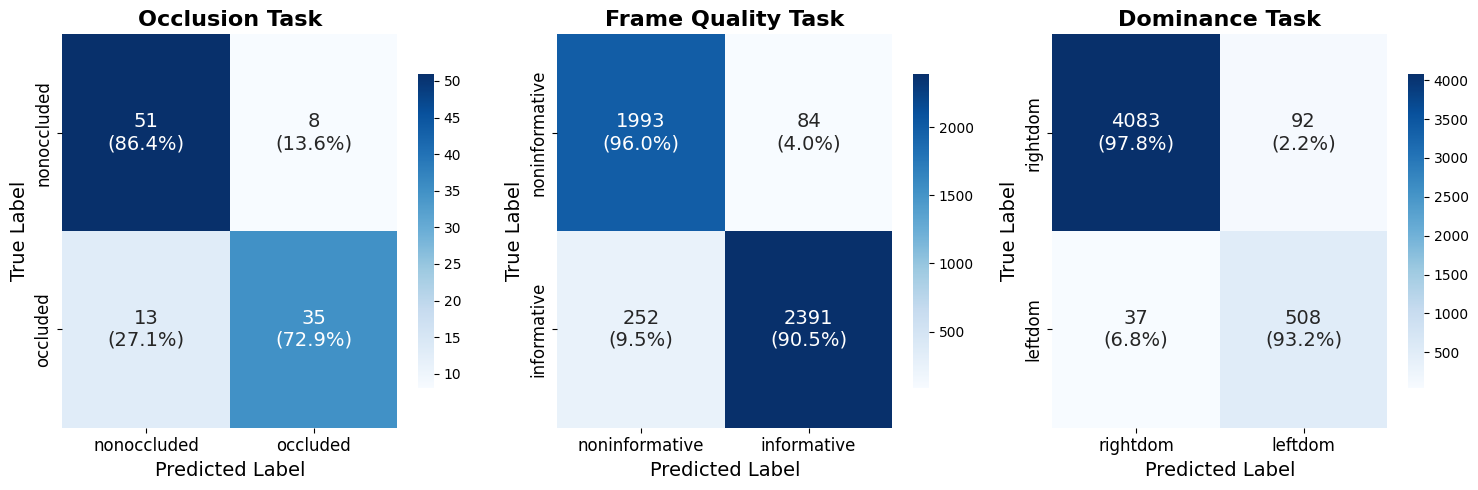


Calculating advanced metrics...

=== ADVANCED METRICS SUMMARY ===
         Task     Class_Name  Accuracy (%)  Precision (%)  Sensitivity/Recall (%)  F1-Score (%)  Specificity (%)  Support
    Occlusion    nonoccluded         86.44          79.69                   86.44         82.93            72.92       59
    Occlusion       occluded         72.92          81.40                   72.92         76.92            86.44       48
    Occlusion        AVERAGE         79.68          80.54                   79.68         79.92            79.68      107
Frame Quality noninformative         95.96          88.78                   95.96         92.23            90.47     2077
Frame Quality    informative         90.47          96.61                   90.47         93.43            95.96     2643
Frame Quality        AVERAGE         93.21          92.69                   93.21         92.83            93.21     4720
    Dominance       rightdom         97.80          99.10                   97.

Evaluating: 100%|██████████████████████████████████████████████████████████████████| 1180/1180 [05:40<00:00,  3.46it/s]



Aggregating occlusion results from 107 videos...
Video-level label distribution: {1: 48, 0: 59}

=== FINAL VALIDATION ===
Total unique videos processed: 107
Expected occluded videos: 48
Expected non-occluded videos: 59
Total: 107

=== INFERENCE PERFORMANCE ===
Total samples: 4720
Total batches: 1180
Average batch size: 4.0
Average inference time per batch: 0.1160 seconds
Inference time per sample: 0.0290 seconds
Average GPU memory usage: 242.66 MB

=== OCCLUSION TASK METRICS (VIDEO-LEVEL) ===
Aggregation strategy: average
Videos processed: 107
Test Accuracy: 0.8131 (81.31%)
Total samples: 107
Actual distribution: [59 48]
Predicted distribution: [63 44]

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.8095    0.8644    0.8361        59
    occluded     0.8182    0.7500    0.7826        48

    accuracy                         0.8131       107
   macro avg     0.8139    0.8072    0.8093       107
weighted avg     0.8134    0.8131    0.812

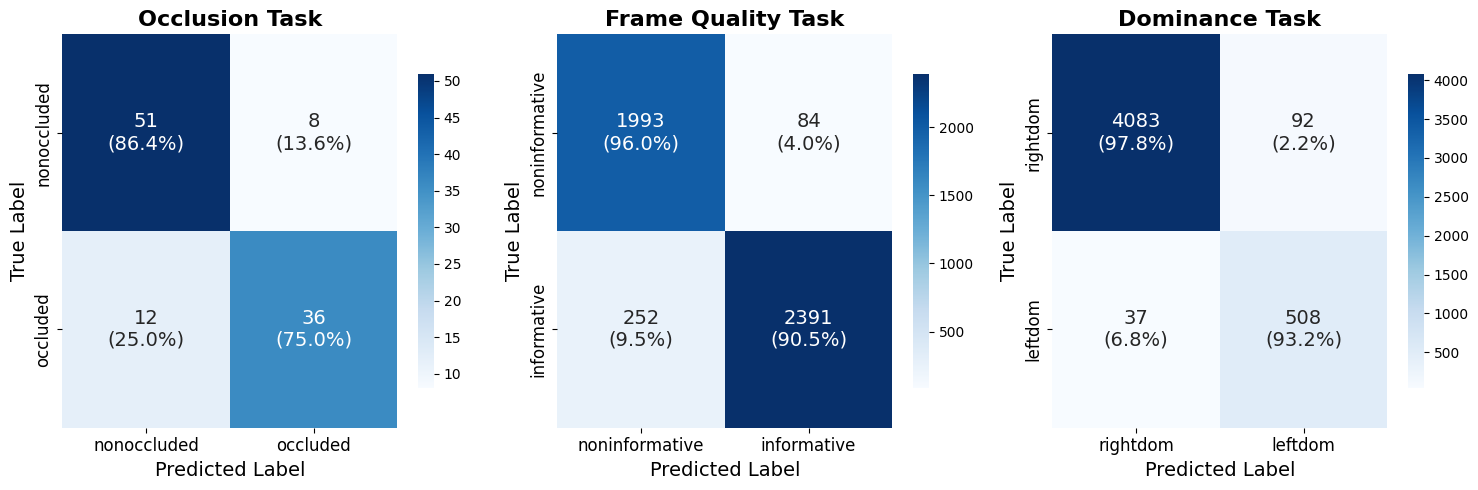


Calculating advanced metrics...

=== ADVANCED METRICS SUMMARY ===
         Task     Class_Name  Accuracy (%)  Precision (%)  Sensitivity/Recall (%)  F1-Score (%)  Specificity (%)  Support
    Occlusion    nonoccluded         86.44          80.95                   86.44         83.61            75.00       59
    Occlusion       occluded         75.00          81.82                   75.00         78.26            86.44       48
    Occlusion        AVERAGE         80.72          81.39                   80.72         80.93            80.72      107
Frame Quality noninformative         95.96          88.78                   95.96         92.23            90.47     2077
Frame Quality    informative         90.47          96.61                   90.47         93.43            95.96     2643
Frame Quality        AVERAGE         93.21          92.69                   93.21         92.83            93.21     4720
    Dominance       rightdom         97.80          99.10                   97.

In [59]:
# Load model
model_path = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\training_results\Densenet121_mtl_best.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_optimized_model('densenet121', input_channels=INPUT_CHANNELS, hidden_dim=HIDDEN_DIM)
model.to(device)
model, _ = load_checkpoint_for_inference(model_path, model, device)

# Define loss functions
criterion_occlusion = nn.CrossEntropyLoss(ignore_index=-1)
criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=-1)
criterion_dominance = nn.CrossEntropyLoss(ignore_index=-1)

results_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\512_Densenet121_LSTM\testing_results_fixed_final'
os.makedirs(results_dir,exist_ok=True)
# Test different aggregation strategies
aggregation_strategies = ['majority', 'average']

for strategy in aggregation_strategies:
    print(f"\n{'='*60}")
    print(f"Running evaluation with {strategy} aggregation")
    print(f"{'='*60}")
    
    strategy_results_dir = os.path.join(results_dir, f'aggregation_{strategy}')
    
    # Run comprehensive evaluation with plots and metrics
    results_dict, metrics_df = comprehensive_evaluation_with_plots(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names_dict=class_names_dict,
        results_dir=strategy_results_dir,
        model_name=f"densenet121_lstm_{strategy}",
        aggregation_strategy=strategy
    )
    
    print(f"\nResults for {strategy} aggregation saved to: {strategy_results_dir}")

print(f"\nAll results saved to: {results_dir}")

In [14]:
import torch
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, classification_report
import os
import torch.nn as nn
import seaborn as sns
import time
from torchvision import transforms

In [8]:
def evaluate_multi_task_model(model, test_dl,
                              criterion_occlusion, criterion_frame_quality, criterion_dominance,
                              train_on_gpu, categories_map, current_view_type,
                              ignore_label_value=-1, n_inference_steps=1):
    """
    Evaluates a multi-task model with detailed metrics, performance benchmarking,
    and corrected tensor handling.
    """
    device = torch.device("cuda" if train_on_gpu and torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    task_results = {task: {'targets': [], 'preds': [], 'probs': [], 'loss': 0.0}
                    for task in ['occlusion', 'frame_quality', 'dominance']}

    # --- Performance Benchmarking ---
    inference_time_ms = 0.0
    if len(test_dl) > 0:
        first_batch_inputs, _ = next(iter(test_dl))
        inputs_bench = {k: v.to(device) for k, v in first_batch_inputs.items()}
        
        # Warm-up
        for _ in range(10):
            with torch.no_grad():
                _ = model(inputs_bench)
        if device.type == 'cuda': torch.cuda.synchronize()

        # Timed runs
        start_time = timer()
        with torch.no_grad():
            for _ in range(n_inference_steps):
                _ = model(inputs_bench)
        if device.type == 'cuda': torch.cuda.synchronize()
        end_time = timer()
        
        total_time = end_time - start_time
        inference_time_ms = (total_time / n_inference_steps) * 1000.0
        del inputs_bench, first_batch_inputs

    # --- GPU Memory Tracking ---
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)

    print(f"\nStarting evaluation on {device} for view type: {current_view_type}...")
    with torch.no_grad():
        for inputs_dict, labels_dict in tqdm(test_dl, desc="Testing"):
            inputs = {k: v.to(device) for k, v in inputs_dict.items()}
            labels = {k: v.to(device) for k, v in labels_dict.items()}
            outputs = model(inputs)
            
            # Process each task
            for task_name, logits in outputs.items():
                if current_view_type == 'LCA' and task_name == 'occlusion': continue
                
                criterion = {'occlusion': criterion_occlusion, 'frame_quality': criterion_frame_quality, 'dominance': criterion_dominance}[task_name]
                
                if task_name == 'occlusion':
                    B, T, C = logits.shape
                    logits_flat = logits.view(B * T, C)
                    labels_flat = labels[f'{task_name}_labels'].view(B * T)
                else: # Frame Quality & Dominance
                    logits_flat = logits.squeeze(1)
                    labels_flat = labels[f'{task_name}_labels'].squeeze(1)

                valid_mask = labels_flat != ignore_label_value
                if valid_mask.any():
                    valid_logits = logits_flat[valid_mask]
                    valid_labels = labels_flat[valid_mask]
                    
                    loss = criterion(valid_logits, valid_labels)
                    task_results[task_name]['loss'] += loss.item()
                    
                    probs = torch.softmax(valid_logits, dim=1)
                    _, preds = torch.max(valid_logits, 1)
                    
                    task_results[task_name]['targets'].extend(valid_labels.cpu().numpy())
                    task_results[task_name]['preds'].extend(preds.cpu().numpy())
                    task_results[task_name]['probs'].append(probs.cpu().numpy())

    peak_gpu_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 0

    # --- Final Report Generation ---
    final_evaluation = {
        'num_samples_in_test_dl': len(test_dl.dataset),
        'inference_time_per_batch_ms': round(inference_time_ms, 4),
        'peak_gpu_memory_mb': round(peak_gpu_memory_mb, 2)
    }
    
    active_task_accuracies = []
    for task_name, results in task_results.items():
        if not results['targets']: continue
        class_names = categories_map[task_name]
        y_true = np.array(results['targets'])
        y_pred = np.array(results['preds'])
        y_probs = np.concatenate(results['probs'], axis=0) if results['probs'] else np.array([])
        
        avg_loss = results['loss'] / len(test_dl)
        accuracy = (y_true == y_pred).mean()
        active_task_accuracies.append(accuracy)
        
        report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
        cm_array = confusion_matrix(y_true, y_pred)
        
        final_evaluation[task_name] = {
            'test_loss': round(avg_loss, 4),
            'test_accuracy': round(accuracy * 100, 2),
            'all_targets': y_true,
            'prediction_label': y_pred,
            'prediction_probs': y_probs,
            'classification_report_str': report_str,
            'confusion_matrix_array': cm_array,
        }

        print(f"\n--- {task_name.replace('_', ' ').title()} Task Results ---")
        print(f"  Test Loss: {final_evaluation[task_name]['test_loss']:.4f}")
        print(f"  Test Accuracy: {final_evaluation[task_name]['test_accuracy']:.2f}%")
        
        if report_str:
            print(f"  Classification Report:\n{report_str}")
        
        if cm_array is not None and len(class_names) > 0:
            cm_df = pd.DataFrame(cm_array, index=class_names, columns=class_names)
            print(f"  Confusion Matrix (Rows: True, Cols: Predicted):\n{cm_df}")

    print('==============================================================')

    
    # **NEW**: Calculate and add overall average accuracy
    if active_task_accuracies:
        overall_avg_accuracy = np.mean(active_task_accuracies)
        final_evaluation['overall_test_accuracy'] = round(overall_avg_accuracy * 100, 2)
    else:
        final_evaluation['overall_test_accuracy'] = 0.0


    # Explicitly delete references to large objects to aid garbage collection
    del model, test_dl, criterion_occlusion, criterion_frame_quality, criterion_dominance
    gc.collect()
    if train_on_gpu:
        torch.cuda.empty_cache()
            
    return final_evaluation

In [15]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from timeit import default_timer as timer
from sklearn.metrics import classification_report, confusion_matrix
import gc

def evaluate_multi_task_model(model, test_dl,
                              criterion_occlusion, criterion_frame_quality, criterion_dominance,
                              train_on_gpu, categories_map, current_view_type,
                              ignore_label_value=-1, n_inference_steps=1):
    """
    Evaluates a multi-task model with detailed metrics, performance benchmarking,
    and corrected tensor handling for clip-based tasks.
    """
    device = torch.device("cuda" if train_on_gpu and torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    task_results = {task: {'targets': [], 'preds': [], 'probs': [], 'loss': 0.0}
                    for task in ['occlusion', 'frame_quality', 'dominance']}

    # --- Performance Benchmarking ---
    inference_time_ms = 0.0
    if len(test_dl) > 0:
        first_batch_inputs, _ = next(iter(test_dl))
        inputs_bench = {k: v.to(device) for k, v in first_batch_inputs.items()}
        
        # Warm-up
        for _ in range(10):
            with torch.no_grad():
                _ = model(inputs_bench)
        if device.type == 'cuda': torch.cuda.synchronize()

        # Timed runs
        start_time = timer()
        with torch.no_grad():
            for _ in range(n_inference_steps):
                _ = model(inputs_bench)
        if device.type == 'cuda': torch.cuda.synchronize()
        end_time = timer()
        
        total_time = end_time - start_time
        inference_time_ms = (total_time / n_inference_steps) * 1000.0
        del inputs_bench, first_batch_inputs

    # --- GPU Memory Tracking ---
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)

    print(f"\nStarting evaluation on {device} for view type: {current_view_type}...")
    with torch.no_grad():
        for inputs_dict, labels_dict in tqdm(test_dl, desc="Testing"):
            inputs = {k: v.to(device) for k, v in inputs_dict.items()}
            labels = {k: v.to(device) for k, v in labels_dict.items()}
            outputs = model(inputs)
            
            # Process each task
            for task_name, logits in outputs.items():
                if current_view_type == 'LCA' and task_name == 'occlusion':
                    continue
                
                criterion = {'occlusion': criterion_occlusion, 'frame_quality': criterion_frame_quality, 'dominance': criterion_dominance}[task_name]
                
                if task_name == 'occlusion':
                    # --- MODIFICATION START ---
                    # The model outputs predictions per frame (B, T, C). To get one prediction per clip,
                    # we aggregate the frame-level results. Averaging the logits is a robust method.
                    
                    # 1. Aggregate logits across the time dimension (T) to get a single prediction vector per clip.
                    logits_per_clip = torch.mean(logits, dim=1)  # Shape: (B, C)
                    
                    # 2. Get a single label for each clip. Since the label is consistent across a
                    # clip (either all frames are 'occluded' or 'nonoccluded' within that sequence),
                    # we can take the label of any frame. The last frame's label is used here for simplicity.
                    labels_per_clip = labels[f'{task_name}_labels'][:, -1]  # Shape: (B,)
                    
                    # Use the aggregated results for loss calculation and metric collection.
                    logits_flat = logits_per_clip
                    labels_flat = labels_per_clip
                    # --- MODIFICATION END ---
                    
                else:  # Frame Quality & Dominance (no change needed for these single-frame tasks)
                    logits_flat = logits.squeeze(1)
                    labels_flat = labels[f'{task_name}_labels'].squeeze(1)

                valid_mask = labels_flat != ignore_label_value
                if valid_mask.any():
                    valid_logits = logits_flat[valid_mask]
                    valid_labels = labels_flat[valid_mask]
                    
                    loss = criterion(valid_logits, valid_labels)
                    task_results[task_name]['loss'] += loss.item()
                    
                    probs = torch.softmax(valid_logits, dim=1)
                    _, preds = torch.max(valid_logits, 1)
                    
                    task_results[task_name]['targets'].extend(valid_labels.cpu().numpy())
                    task_results[task_name]['preds'].extend(preds.cpu().numpy())
                    task_results[task_name]['probs'].append(probs.cpu().numpy())

    peak_gpu_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 0

    # --- Final Report Generation ---
    final_evaluation = {
        'num_samples_in_test_dl': len(test_dl.dataset),
        'inference_time_per_batch_ms': round(inference_time_ms, 4),
        'peak_gpu_memory_mb': round(peak_gpu_memory_mb, 2)
    }
    
    active_task_accuracies = []
    for task_name, results in task_results.items():
        if not results['targets']:
            continue
        
        class_names = categories_map[task_name]
        y_true = np.array(results['targets'])
        y_pred = np.array(results['preds'])
        y_probs = np.concatenate(results['probs'], axis=0) if results['probs'] else np.array([])
        
        avg_loss = results['loss'] / len(test_dl)
        accuracy = (y_true == y_pred).mean()
        active_task_accuracies.append(accuracy)
        
        report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
        cm_array = confusion_matrix(y_true, y_pred)
        
        final_evaluation[task_name] = {
            'test_loss': round(avg_loss, 4),
            'test_accuracy': round(accuracy * 100, 2),
            'all_targets': y_true,
            'prediction_label': y_pred,
            'prediction_probs': y_probs,
            'classification_report_str': report_str,
            'confusion_matrix_array': cm_array,
        }

        print(f"\n--- {task_name.replace('_', ' ').title()} Task Results ---")
        print(f"  Test Loss: {final_evaluation[task_name]['test_loss']:.4f}")
        print(f"  Test Accuracy: {final_evaluation[task_name]['test_accuracy']:.2f}%")
        
        if report_str:
            print(f"  Classification Report:\n{report_str}")
        
        if cm_array is not None and len(class_names) > 0:
            cm_df = pd.DataFrame(cm_array, index=class_names, columns=class_names)
            print(f"  Confusion Matrix (Rows: True, Cols: Predicted):\n{cm_df}")

    print('==============================================================')
    
    if active_task_accuracies:
        overall_avg_accuracy = np.mean(active_task_accuracies)
        final_evaluation['overall_test_accuracy'] = round(overall_avg_accuracy * 100, 2)
    else:
        final_evaluation['overall_test_accuracy'] = 0.0

    # Explicitly delete references to large objects to aid garbage collection
    del model, test_dl, criterion_occlusion, criterion_frame_quality, criterion_dominance
    gc.collect()
    if train_on_gpu:
        torch.cuda.empty_cache()
            
    return final_evaluation

In [16]:
def plot_confusion_matrix_for_task(cm_array, class_names, task_name, save_dir=None):
    if cm_array is None or cm_array.size == 0: return
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 16})
    plt.title(f'Confusion Matrix: {task_name.title()}', fontsize=20)
    plt.ylabel('True Label', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f'cm_{task_name}.png')
        plt.savefig(save_path, dpi=300)
        print(f"Saved confusion matrix for {task_name} to {save_path}")
    plt.show()

def calculate_binary_metrics(tn, fp, fn, tp):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = (2 * precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    return precision, sensitivity, specificity, f1

def display_and_get_advanced_metrics(evaluation_results, categories_map):
    advanced_metrics_dfs = {}
    print("\n--- Advanced Classification Metrics ---")
    for task_name, results in evaluation_results.items():
        if not isinstance(results, dict) or 'all_targets' not in results: continue
        
        y_true = results['all_targets']
        y_pred = results['prediction_label']
        class_names = categories_map[task_name]
        
        mcm = multilabel_confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
        metrics_data = []
        for i, class_name in enumerate(class_names):
            tn, fp, fn, tp = mcm[i].ravel()
            precision, sensitivity, specificity, f1 = calculate_binary_metrics(tn, fp, fn, tp)
            metrics_data.append({
                'Class': class_name, 'Accuracy': results['test_accuracy'],
                'Precision': precision * 100, 'Sensitivity (Recall)': sensitivity * 100,
                'F1-Score': f1 * 100, 'Specificity': specificity * 100
            })
        
        metrics_df = pd.DataFrame(metrics_data)
        advanced_metrics_dfs[task_name] = metrics_df
        
        print(f"\nMetrics for {task_name.title()} Task:")
        print(metrics_df.to_string(index=False, float_format="%.2f"))
        
    return advanced_metrics_dfs


In [17]:
IGNORE_LABEL_VALUE = -1 # Keep this consistent with your dataset

# Define loss functions for each task, using ignore_index
criterion_occlusion = nn.CrossEntropyLoss(ignore_index=IGNORE_LABEL_VALUE)
criterion_frame_quality = nn.CrossEntropyLoss(ignore_index=IGNORE_LABEL_VALUE)
criterion_dominance = nn.CrossEntropyLoss(ignore_index=IGNORE_LABEL_VALUE)

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:

# --- Configuration for your actual dataset and training ---
ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET' # <<< Your Actual Dataset Path
VIEW_TYPE = 'RCA' # Change to 'LCA' if needed

# Grayscale mean and std, consistent with your dataset loading (Image.open(...).convert('L'))
# These are the values you provided: mean: [0.5485], std: [0.1407]
FINAL_MEAN = [0.5485]
FINAL_STD = [0.1407]

HEIGHT, WIDTH = 512, 512 # Adjust based on your model's expected input size (e.g., 224x224 for ResNet)
CLIP_LENGTH = 5 # Number of frames in each occlusion clip

BATCH_SIZE = 8 # Adjust batch size based on your GPU memory. Start small (e.g., 4 or 8)
NUM_WORKERS = 0 # Set to 0 for debugging on Windows. For Linux/macOS, you can try >0 for faster loading.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"--- Setting up DataLoaders for XCA Multi-Task Training on device: {device} ---")
print(f"Attempting to load data from your specified ROOT_DATA_DIR: {ROOT_DATA_DIR}")
print("Please ensure this path is correct and contains the expected data structure.")


try:
    # --- Transforms ---

    val_test_transform_instance = ClipTransform(
        img_size=(HEIGHT, WIDTH),
        mean=FINAL_MEAN,
        std=FINAL_STD,
        apply_augmentations=False # No random augmentations for validation/testing
    )

    # --- Dataset Instantiation ---


    test_dataset = XCAMultiTaskDataset_IndependentVideos(
         root_dir=ROOT_DATA_DIR,
         fold_num=1,
         split_type='test',
         view_type=VIEW_TYPE,
         clip_length=CLIP_LENGTH,
         transform=val_test_transform_instance
     )

    print(f"Test dataset size (number of occlusion clips): {len(test_dataset)}")


    # --- DataLoader Instantiation ---
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    print(f"Test DataLoader created with batch size: {BATCH_SIZE}")


    # --- Example of Iterating Through a Batch (Simulating Training Loop) ---
    # This loop shows how you would typically retrieve and prepare data for your model.
    print("\n--- Example Batch from Train DataLoader (First Iteration) ---")
    for batch_idx, (inputs_dict, labels_dict) in enumerate(test_loader):
        # Move all input images to the correct device
        occlusion_images = inputs_dict['occlusion_images'].to(device)
        frame_quality_images = inputs_dict['frame_quality_images'].to(device)
        dominance_images = inputs_dict['dominance_images'].to(device)

        # Move all labels to the correct device
        occlusion_labels = labels_dict['occlusion_labels'].to(device)
        frame_quality_labels = labels_dict['frame_quality_labels'].to(device)
        dominance_labels = labels_dict['dominance_labels'].to(device)

        print(f"Batch {batch_idx+1}:")
        print(f"  Occlusion Images shape: {occlusion_images.shape} (Batch, Clip_Length, Channels, Height, Width)")
        print(f"  Frame Quality Images shape: {frame_quality_images.shape} (Batch, 1, Channels, Height, Width)")
        print(f"  Dominance Images shape: {dominance_images.shape} (Batch, 1, Channels, Height, Width)")
        print(f"  Occlusion Labels shape: {occlusion_labels.shape} (Batch, Clip_Length)")
        print(f"  Frame Quality Labels shape: {frame_quality_labels.shape} (Batch, 1)")
        print(f"  Dominance Labels shape: {dominance_labels.shape} (Batch, 1)")

        if batch_idx >= 0: # Process only the first batch for demonstration
            break
    print("\n--- DataLoader setup and initial batch retrieval complete. Ready for training loop. ---")

except RuntimeError as e:
    print(f"\nError during dataset initialization or batch fetching: {e}")
    print(f"Please double-check that the ROOT_DATA_DIR ('{ROOT_DATA_DIR}') is correct and accessible,")
    print("and that your dataset structure within it matches what `XCAMultiTaskDataset_IndependentVideos` expects.")
    print("Ensure the relevant CSV label files and image folders exist at the expected locations.")
    print("Example Expected Structure for a task (e.g., occlusion):")
    print(f"{ROOT_DATA_DIR}/occlusion/DATA_RCA/labels/occlusion_train_labels_fold_{FOLD_NUM}.csv")
    print(f"{ROOT_DATA_DIR}/occlusion/DATA_RCA/nonoccluded/STUDYID_VIEW_VIDEOID_frame_NUMBER.png")
    print(f"{ROOT_DATA_DIR}/occlusion/DATA_RCA/occluded/STUDYID_VIEW_VIDEOID_frame_NUMBER.png")
    print("Similar structures are expected for 'framequality' and 'dominance' tasks.")
    print("\nIf you are encountering 'CUDA out of memory' errors, try reducing BATCH_SIZE and/or IMG_HEIGHT/IMG_WIDTH.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

--- Setting up DataLoaders for XCA Multi-Task Training on device: cuda ---
Attempting to load data from your specified ROOT_DATA_DIR: E:\Morshedul\CoronarDominance\MTL_DATASET
Please ensure this path is correct and contains the expected data structure.
Parsing raw data files and building independent indices for each task...
Loaded 4720 occlusion clips from 107 videos.
Loaded 789 framequality entries.
Loaded 4149 dominance entries.
Finished loading and indexing data for all tasks.
Test dataset size (number of occlusion clips): 4720
Test DataLoader created with batch size: 8

--- Example Batch from Train DataLoader (First Iteration) ---
Batch 1:
  Occlusion Images shape: torch.Size([8, 5, 1, 512, 512]) (Batch, Clip_Length, Channels, Height, Width)
  Frame Quality Images shape: torch.Size([8, 1, 1, 512, 512]) (Batch, 1, Channels, Height, Width)
  Dominance Images shape: torch.Size([8, 1, 1, 512, 512]) (Batch, 1, Channels, Height, Width)
  Occlusion Labels shape: torch.Size([8, 5]) (Batch,

In [13]:
SEQUENCE_LENGTH = 5
IMAGE_HEIGHT, IMAGE_WIDTH = 512, 512
INPUT_CHANNELS = 1 # For grayscale
NUM_CLASSES_OCCLUSION = 2
NUM_CLASSES_FRAME_QUALITY = 2
NUM_CLASSES_DOMINANCE = 2
HIDDEN_DIM = 128 

backbone_model = models.resnet18(weights="DEFAULT")
backbone_type = "resnet"
#backbone_model = models.densenet121(weights="DEFAULT")
#backbone_type = "densenet"

# Instantiate your MultiTaskModel
# --- Multi-Task Model Instantiation ---
model = XCAMultiTaskModel(
    backbone=backbone_model, # Use the feature extractor here
    backbone_type=backbone_type,
    input_channels=INPUT_CHANNELS,
    num_classes_occlusion=NUM_CLASSES_OCCLUSION,
    num_classes_frame_quality=NUM_CLASSES_FRAME_QUALITY,
    num_classes_dominance=NUM_CLASSES_DOMINANCE,
    hidden_dim=HIDDEN_DIM,
    sequential_model_type='lstm',      # Specify the sequential model type
    sequential_hidden_dim=HIDDEN_DIM,  # Hidden dimension for the sequential model
    num_sequential_layers=5,           # Number of layers for the sequential model
    bidirectional=False                # Whether the sequential model is bidirectional
)


checkpoint_path = r"E:\Morshedul\CoronarDominance\MTL_results\RCA\Resnet18_LSTM\training_results\Resnet18_LSTM_mtl_best.pth" 

#checkpoint_path = r"E:\Morshedul\CoronarDominance\MTL_results\LCA\Resnet18\training_results\Resnet18_mtl_best.pth" 

# Load the best model's state dictionary
if os.path.exists(checkpoint_path):
    print(f"Loading best model from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Model loaded successfully from Epoch {checkpoint.get('epoch', 'N/A') + 1}, with best validation accuracy: {checkpoint.get('best_val_accuracy', 'N/A'):.4f}")
else:
    print(f"Error: Best model checkpoint not found at {checkpoint_path}. Please check the path.")
    exit() # Stop execution if model cannot be loaded



ResNet conv1 modified to 1 input channel(s).
Loading best model from: E:\Morshedul\CoronarDominance\MTL_results\RCA\Resnet18_LSTM\training_results\Resnet18_LSTM_mtl_best.pth
Model loaded successfully from Epoch 20, with best validation accuracy: 0.9001


In [14]:
categories_map = {

    'occlusion': ['nonoccluded', 'occluded'],

    'frame_quality': ['noninformative', 'informative'],

    'dominance': ['rightdom','leftdom']

} 


In [ ]:

ROOT_DATA_DIR = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
VIEW_TYPE = 'RCA'
CHECKPOINT_PATH = r"E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\training_results\Densenet121_mtl_best.pth"
SAVE_DIR = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\testing_results'

FINAL_MEAN, FINAL_STD = [0.5485], [0.1407]
HEIGHT, WIDTH, CLIP_LENGTH, BATCH_SIZE, NUM_WORKERS = 512, 512, 5, 8, 0
IGNORE_LABEL_VALUE = -1

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(SAVE_DIR, exist_ok=True)
val_test_transform = ClipTransform((HEIGHT, WIDTH), FINAL_MEAN, FINAL_STD, False)

try:
    test_dataset = XCAMultiTaskDataset_IndependentVideos(ROOT_DATA_DIR, 'test', VIEW_TYPE, CLIP_LENGTH, val_test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
except Exception as e:
    print(f"Error loading dataset: {e}"); exit()

# --- Model Loading ---
backbone = models.densenet121(weights="DEFAULT") # Make sure this matches your trained model
model = XCAMultiTaskModel(backbone, "densenet", 1, 2, 2, 2, 128, 'lstm', 128, 5, False)
if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device)['model_state_dict'])
else:
    print(f"Error: Checkpoint not found at {CHECKPOINT_PATH}."); exit()

# --- Evaluation ---
criterions = {task: nn.CrossEntropyLoss(ignore_index=IGNORE_LABEL_VALUE) for task in ['occlusion', 'frame_quality', 'dominance']}
categories_map = {'occlusion': ['nonoccluded', 'occluded'], 'frame_quality': ['noninformative', 'informative'], 'dominance': ['rightdom', 'leftdom']}

evaluation_results = evaluate_multi_task_model(
    model, test_loader, criterions['occlusion'], criterions['frame_quality'], criterions['dominance'],
    torch.cuda.is_available(), categories_map, VIEW_TYPE, IGNORE_LABEL_VALUE)

print('\n--- Performance Summary ---')
print(f"  Inference Time per Batch: {evaluation_results.get('inference_time_per_batch_ms', 'N/A')} ms")
print(f"  Peak GPU Memory Usage: {evaluation_results.get('peak_gpu_memory_mb', 'N/A')} MB")

# --- Plotting and Advanced Metrics ---
for task_name, results in evaluation_results.items():
    if isinstance(results, dict) and 'confusion_matrix_array' in results:
        plot_confusion_matrix_for_task(results['confusion_matrix_array'], categories_map[task_name], task_name, SAVE_DIR)

advanced_metrics_dfs = display_and_get_advanced_metrics(evaluation_results, categories_map)

# --- Save to Excel ---
excel_path = os.path.join(SAVE_DIR, "multi_task_advanced_metrics.xlsx")
try:
    with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
        for task_name, df in advanced_metrics_dfs.items():
            df.to_excel(writer, sheet_name=f"{task_name.title()} Metrics", index=False)
    print(f"\nAdvanced metrics saved to {excel_path}")
except Exception as e:
    print(f"\nError saving metrics to Excel: {e}")


In [15]:
# --- Run Evaluation ---
evaluation_results = evaluate_multi_task_model(
    model=model,
    test_dl=test_loader,
    criterion_occlusion=criterion_occlusion,
    criterion_frame_quality=criterion_frame_quality,
    criterion_dominance=criterion_dominance,
    train_on_gpu=torch.cuda.is_available(),
    categories_map=categories_map,
    current_view_type=VIEW_TYPE,
    ignore_label_value=IGNORE_LABEL_VALUE
)



Starting evaluation on cuda for view type: RCA...


Testing: 100%|█████████████████████████████████████████| 590/590 [04:54<00:00,  2.01it/s]



--- Occlusion Task Results ---
  Test Loss: 1.6698
  Test Accuracy: 76.85%
  Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.7448    0.7901    0.7668     11370
    occluded     0.7932    0.7483    0.7701     12230

    accuracy                         0.7685     23600
   macro avg     0.7690    0.7692    0.7685     23600
weighted avg     0.7699    0.7685    0.7685     23600

  Confusion Matrix (Rows: True, Cols: Predicted):
             nonoccluded  occluded
nonoccluded         8984      2386
occluded            3078      9152

--- Frame Quality Task Results ---
  Test Loss: 0.2275
  Test Accuracy: 94.09%
  Classification Report:
                precision    recall  f1-score   support

noninformative     0.9104    0.9573    0.9332      2037
   informative     0.9663    0.9284    0.9470      2683

      accuracy                         0.9409      4720
     macro avg     0.9383    0.9429    0.9401      4720
  weighted avg     0.9421    0

In [40]:
evaluation_results.keys()

dict_keys(['num_samples_in_test_dl', 'benchmarked_inference_time_per_batch_ms', 'peak_gpu_memory_mb', 'occlusion', 'frame_quality', 'dominance'])

In [44]:
evaluation_results['dominance'].keys()

dict_keys(['test_loss', 'test_accuracy', 'all_targets', 'prediction_label', 'prediction_probs', 'classification_report_str', 'confusion_matrix_array'])


Results for Occlusion Task:
  Confusion Matrix (Rows: True, Cols: Predicted):
             nonoccluded  occluded
nonoccluded         2202       308
occluded             992      1646
Plot saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\testing_results\confusion_matrix_occlusion.png


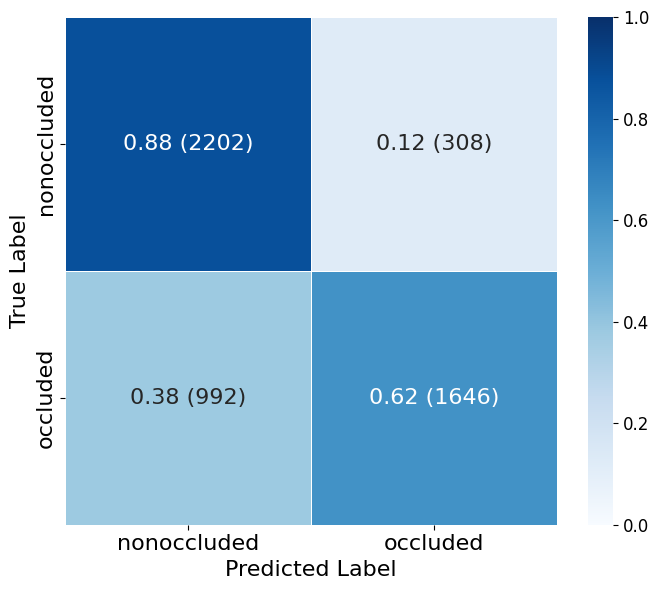


Results for Frame Quality Task:
  Confusion Matrix (Rows: True, Cols: Predicted):
                noninformative  informative
noninformative             281           66
informative                 10          432
Plot saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\testing_results\confusion_matrix_frame_quality.png


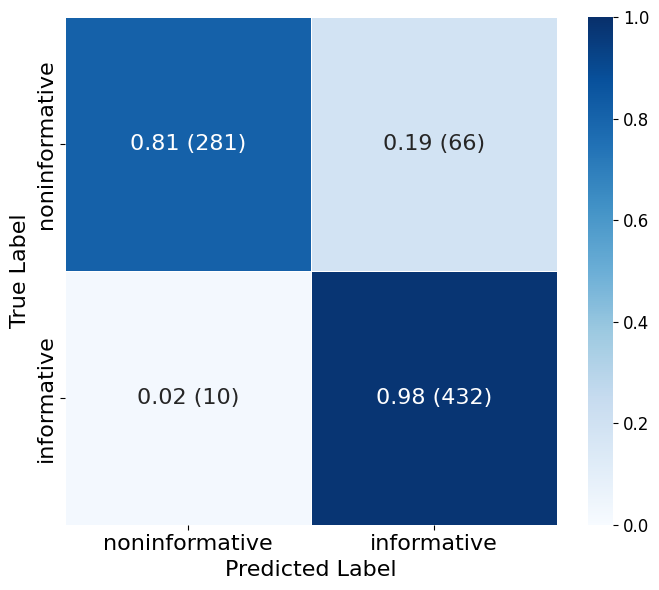


Results for Dominance Task:
  Confusion Matrix (Rows: True, Cols: Predicted):
          rightdom  leftdom
rightdom      3639       42
leftdom         81      387
Plot saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\testing_results\confusion_matrix_dominance.png


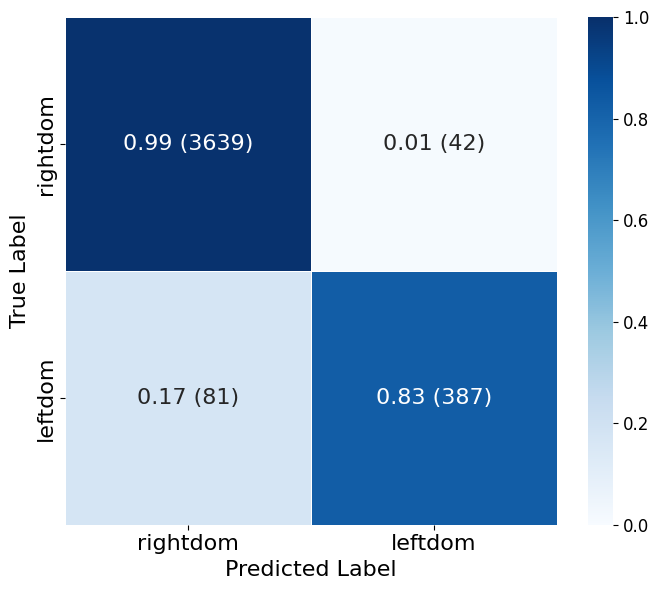

In [ ]:
print('\n--- Performance Summary ---')
print(f"  Inference Time per Batch: {evaluation_results.get('inference_time_per_batch_ms', 'N/A')} ms")
print(f"  Peak GPU Memory Usage: {evaluation_results.get('peak_gpu_memory_mb', 'N/A')} MB")

# --- Plotting and Advanced Metrics ---
for task_name, results in evaluation_results.items():
    if isinstance(results, dict) and 'confusion_matrix_array' in results:
        plot_confusion_matrix_for_task(results['confusion_matrix_array'], categories_map[task_name], task_name, SAVE_DIR)


In [49]:
import json
# Convert NumPy arrays to native Python types
def convert_numpy(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Converts array to list
    if isinstance(obj, np.generic):  # Handles np.float32, np.int64, etc.
        return obj.item()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")


json_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\testing_results'

if os.path.exists(json_dir):
    pass
else:
    os.makedirs(json_dir, exist_ok=True)
    
json_file_name = os.path.join(json_dir,"evaluation_results.json")

# Save to a JSON file
with open(json_file_name, "w") as f:
    #json.dump(evaluation_results, f, indent=4)
    json.dump(evaluation_results, f, indent=4, default=convert_numpy)
#eval_df = pd.DataFrame(evaluation_results)
#eval_df.head()

In [ ]:
advanced_metrics_dfs = display_and_get_advanced_metrics(evaluation_results, categories_map)

# --- Save to Excel ---
excel_path = os.path.join(SAVE_DIR, "multi_task_advanced_metrics.xlsx")
try:
    with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
        for task_name, df in advanced_metrics_dfs.items():
            df.to_excel(writer, sheet_name=f"{task_name.title()} Metrics", index=False)
    print(f"\nAdvanced metrics saved to {excel_path}")
except Exception as e:
    print(f"\nError saving metrics to Excel: {e}")

In [ ]:
# --- NEW: Save advanced metrics to an Excel file ---
save_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\Densenet121_aug\testing_results'

if os.path.exists(save_dir):
    pass
else:
    os.makedirs(save_dir, exist_ok=True)

excel_file_name = os.path.join(save_dir,"multi_task_advanced_metrics.xlsx")

#advanced_metrics_dfs = display_advanced_metrics(evaluation_results, categories_map, IGNORE_LABEL_VALUE)
advanced_metrics_dfs = display_and_get_advanced_metrics(evaluation_results, categories_map, IGNORE_LABEL_VALUE)
try:
    with pd.ExcelWriter(excel_file_name, engine='xlsxwriter') as writer:
        for task_name, df in advanced_metrics_dfs.items():
            sheet_name = f"{task_name.replace('_', ' ').title()} Metrics"
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"\nAdvanced metrics successfully saved to {excel_file_name}")
except Exception as e:
    print(f"\nError saving advanced metrics to Excel: {e}")


--- Advanced Classification Metrics ---

Results for Num Samples In Test Dl Task:


TypeError: 'int' object is not subscriptable

In [ ]:
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
Cell In[50], line 12
      9 excel_file_name = os.path.join(save_dir,"multi_task_advanced_metrics.xlsx")
     11 #advanced_metrics_dfs = display_advanced_metrics(evaluation_results, categories_map, IGNORE_LABEL_VALUE)
---> 12 advanced_metrics_dfs = display_and_get_advanced_metrics(evaluation_results, categories_map, IGNORE_LABEL_VALUE)
     13 try:
     14     with pd.ExcelWriter(excel_file_name, engine='xlsxwriter') as writer:

Cell In[28], line 126
    123 print(f"\nResults for {task_name.replace('_', ' ').title()} Task:")
    125 # Retrieve filtered targets and predictions for metric calculation
--> 126 valid_targets = [t for t in results['all_targets'] if t != ignore_label_value]
    127 valid_predictions = [p for i, p in enumerate(results['prediction_label']) if results['all_targets'][i] != ignore_label_value]
    129 if not valid_targets:

TypeError: 'int' object is not subscriptable